# Perbandingan Komprehensif: NMI vs MI Feature Selection

**Tujuan**: Membandingkan performa 3 pendekatan deteksi phishing:
1. **NMI WITH Whitelist TLD** - NMI feature selection + Rule-based filtering (TLD whitelist + Entropy)
2. **NMI WITHOUT Whitelist** - NMI feature selection + Pure Machine Learning (No filtering)
3. **MI WITH Filtering + Entropy** - MI (non-normalized) feature selection + Whitelist filtering

---

## Metodologi Perbandingan:
- ✅ **Dataset yang sama**
- ✅ **Pre-processing yang sama**
- ✅ **Ekstraksi fitur yang sama**
- ⚠️ **Feature selection BERBEDA**:
  - **NMI** (Normalized Mutual Information): MI normalized by (H(X) + H(Y))
  - **MI** (Mutual Information): Raw MI scores without normalization
- ✅ **Train/Test split yang sama** (random_state=42, 70:30)
- ✅ **Top N experiments** untuk setiap metode: [3, 5, 7, 10, 15, 20]

---

## Perbedaan Utama:
1. **NMI WITHOUT Whitelist**: Pure ML dengan NMI-selected features
2. **NMI WITH Whitelist**: ML + Whitelist filtering dengan NMI-selected features
3. **MI WITH Filtering**: ML + Whitelist filtering dengan MI-selected features (non-normalized)

---

**Generated**: 2026-02-20

## 1. Import Libraries

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from urllib.parse import urlparse
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')

# Install tldextract jika belum ada
try:
    import tldextract
    print("✓ tldextract sudah terinstall")
except ImportError:
    import subprocess
    import sys
    print("Installing tldextract...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tldextract"])
    import tldextract
    print("✓ tldextract berhasil diinstall!")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("\n" + "="*80)
print("MODEL COMPARISON: WITH vs WITHOUT Whitelist TLD")
print("="*80)
print("✓ Libraries loaded successfully!")

✓ tldextract sudah terinstall

MODEL COMPARISON: WITH vs WITHOUT Whitelist TLD
✓ Libraries loaded successfully!


## 2. Load Dataset

In [104]:
# Load dataset
dataset_path = '../Dataset/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14.csv'
df = pd.read_csv(dataset_path)

dataset_name = os.path.basename(dataset_path).replace('.csv', '')

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Dataset: {dataset_name}")
print(f"Total URLs: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel Distribution:")
print(df['LABEL'].value_counts())
print(f"\nPhishing: {(df['LABEL']=='phishing').sum():,} ({(df['LABEL']=='phishing').sum()/len(df)*100:.2f}%)")
print(f"Legitimate: {(df['LABEL']=='legitimate').sum():,} ({(df['LABEL']=='legitimate').sum()/len(df)*100:.2f}%)")

df.head()

DATASET INFORMATION
Dataset: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
Total URLs: 5,930
Columns: ['URL', 'LABEL']

Label Distribution:
LABEL
legitimate    3209
phishing      2721
Name: count, dtype: int64

Phishing: 2,721 (45.89%)
Legitimate: 3,209 (54.11%)


,URL,LABEL
0,grubwa32417.terbarux1-2024.my.id/vhsfhqpdhdsih6/,phishing
1,whatsappm3thatm.zezxz.biz.id/vhsfhqpdhdsih6,phishing
2,123website.co.id,legitimate
3,masuk.grupwa18.terrbaru2022.my.id/,phishing
4,gruvwa18179.store-rionesia.my.id/vhsfhqpdhdsih6/,phishing


## 3. Pre-processing

In [105]:
print("="*80)
print("PRE-PROCESSING")
print("="*80)

# Remove duplicates
print(f"\n1. Remove Duplicates:")
print(f"   Before: {len(df):,}")
df_clean = df.drop_duplicates(subset=['URL'], keep='first')
print(f"   After: {len(df_clean):,}")
print(f"   Removed: {len(df) - len(df_clean):,}")

# Remove missing values
print(f"\n2. Remove Missing Values:")
print(f"   Before: {len(df_clean):,}")
df_clean = df_clean.dropna()
print(f"   After: {len(df_clean):,}")

# Remove protocol (http:// or https://)
def remove_protocol(url):
    if url.startswith('https://'):
        return url[8:]
    elif url.startswith('http://'):
        return url[7:]
    return url

print(f"\n3. Remove Protocol:")
urls_with_protocol = df_clean['URL'].str.startswith(('http://', 'https://')).sum()
print(f"   URLs with protocol: {urls_with_protocol:,}")
if urls_with_protocol > 0:
    df_clean['URL'] = df_clean['URL'].apply(remove_protocol)
    print(f"   ✓ Protocol removed")

print(f"\n✓ Pre-processing completed!")
print(f"Final dataset size: {len(df_clean):,}")

PRE-PROCESSING

1. Remove Duplicates:
   Before: 5,930
   After: 5,930
   Removed: 0

2. Remove Missing Values:
   Before: 5,930
   After: 5,930

3. Remove Protocol:
   URLs with protocol: 655
   ✓ Protocol removed

✓ Pre-processing completed!
Final dataset size: 5,930


## 4. Feature Extraction

In [106]:
def extract_features(url):
    """Extract features from URL"""
    features = {}
    
    # Entropy calculation
    def calculate_entropy(text):
        if not text:
            return 0
        from collections import Counter
        import math
        char_freq = Counter(text)
        text_len = len(text)
        entropy = 0
        for count in char_freq.values():
            probability = count / text_len
            entropy -= probability * math.log2(probability)
        return entropy
    
    # Extract TLD, domain, subdomain using tldextract
    extracted = tldextract.extract(url)
    subdomain = extracted.subdomain
    domain_name = extracted.domain
    tld = extracted.suffix
    
    # Build full domain
    if subdomain and domain_name and tld:
        full_domain = f"{subdomain}.{domain_name}.{tld}"
    elif domain_name and tld:
        full_domain = f"{domain_name}.{tld}"
    else:
        full_domain = url.split('/')[0]
    
    # Parse URL for path and query
    url_with_protocol = 'http://' + url
    parsed = urlparse(url_with_protocol)
    path = parsed.path
    query = parsed.query
    
    # Basic features
    features['TLD'] = tld if tld else ''
    features['Subdomain'] = subdomain if subdomain else ''
    features['Domain'] = full_domain
    features['Entropy'] = calculate_entropy(url)
    
    # URL features
    features['UrlLength'] = len(url)
    features['DotCountURL'] = url.count('.')
    features['SlashCountURL'] = url.count('/')
    features['HyphenCountURL'] = url.count('-')
    features['QuestionmarkCountURL'] = url.count('?')
    features['EqualCountURL'] = url.count('=')
    features['AndCountURL'] = url.count('&')
    features['DollarCountURL'] = url.count('$')
    features['PercentCountURL'] = url.count('%')
    features['HashtagCountURL'] = url.count('#')
    features['AsteriskCountURL'] = url.count('*')
    features['PlusCountURL'] = url.count('+')
    features['CommaCountURL'] = url.count(',')
    
    # Domain features
    features['DomainLength'] = len(full_domain)
    features['DotCountDomain'] = full_domain.count('.')
    features['SlashCountDomain'] = full_domain.count('/')
    features['HyphenCountDomain'] = full_domain.count('-')
    features['QuestionmarkCountDomain'] = full_domain.count('?')
    features['EqualCountDomain'] = full_domain.count('=')
    features['AndCountDomain'] = full_domain.count('&')
    features['DollarCountDomain'] = full_domain.count('$')
    features['PercentCountDomain'] = full_domain.count('%')
    features['HashtagCountDomain'] = full_domain.count('#')
    features['PlusCountDomain'] = full_domain.count('+')
    features['CommaCountDomain'] = full_domain.count(',')
    
    # Path features
    features['PathLength'] = len(path)
    features['DotCountPath'] = path.count('.')
    features['SlashCountPath'] = path.count('/')
    features['HyphenCountPath'] = path.count('-')
    features['QuestionmarkCountPath'] = path.count('?')
    features['EqualCountPath'] = path.count('=')
    features['AndCountPath'] = path.count('&')
    features['DollarCountPath'] = path.count('$')
    features['PercentCountPath'] = path.count('%')
    features['HashtagCountPath'] = path.count('#')
    features['PlusCountPath'] = path.count('+')
    features['CommaCountPath'] = path.count(',')
    
    # Query features
    features['QueryLength'] = len(query)
    features['DotCountQuery'] = query.count('.')
    features['SlashCountQuery'] = query.count('/')
    features['HyphenCountQuery'] = query.count('-')
    features['QuestionmarkCountQuery'] = query.count('?')
    features['EqualCountQuery'] = query.count('=')
    features['AndCountQuery'] = query.count('&')
    features['DollarCountQuery'] = query.count('$')
    features['PercentCountQuery'] = query.count('%')
    features['HashtagCountQuery'] = query.count('#')
    features['PlusCountQuery'] = query.count('+')
    features['CommaCountQuery'] = query.count(',')
    
    return features

print("Extracting features from URLs...")
features_list = [extract_features(url) for url in df_clean['URL']]
features_df = pd.DataFrame(features_list)
df_features = pd.concat([df_clean.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

# Remove URLs with empty TLD
empty_tld_count = (df_features['TLD'] == '').sum()
if empty_tld_count > 0:
    print(f"\n⚠️  Found {empty_tld_count} URLs with empty TLD (invalid format)")
    df_features = df_features[df_features['TLD'] != ''].copy()
    print(f"✓ Invalid URLs removed")

print(f"\n✓ Feature extraction completed!")
print(f"Total features: {len(features_df.columns)}")
print(f"Final dataset: {len(df_features):,} URLs")

# Show top TLDs
print(f"\nTop 10 TLDs in dataset:")
print(df_features['TLD'].value_counts().head(10))

Extracting features from URLs...

⚠️  Found 3 URLs with empty TLD (invalid format)
✓ Invalid URLs removed

✓ Feature extraction completed!
Total features: 53
Final dataset: 5,927 URLs

Top 10 TLDs in dataset:
TLD
my.id     1648
ac.id     1431
go.id      947
co.id      672
biz.id     557
com        169
web.id     144
or.id      107
id          85
dev         46
Name: count, dtype: int64


### 4.1. Export Extracted Features

In [107]:
print("="*80)
print("EXPORT EXTRACTED FEATURES")
print("="*80)

# Create export directory
timestamp_features = datetime.now().strftime('%Y%m%d_%H%M%S')
features_export_dir = f'Extracted_Features/{dataset_name}'
os.makedirs(features_export_dir, exist_ok=True)

# 1. Export Full Features (CSV)
features_csv_file = f'{features_export_dir}/extracted_features_{timestamp_features}.csv'
df_features.to_csv(features_csv_file, index=False, encoding='utf-8')
print(f"\n✓ Full features exported to CSV:")
print(f"  {features_csv_file}")
print(f"  Rows: {len(df_features):,} | Columns: {len(df_features.columns)}")

# 2. Export Features Summary (JSON)
features_summary = {
    'metadata': {
        'timestamp': timestamp_features,
        'dataset': dataset_name,
        'total_urls': len(df_features),
        'total_features': len(features_df.columns),
        'extraction_date': datetime.now().isoformat()
    },
    'features_list': list(features_df.columns),
    'feature_categories': {
        'url_features': [f for f in features_df.columns if 'URL' in f],
        'domain_features': [f for f in features_df.columns if 'Domain' in f],
        'path_features': [f for f in features_df.columns if 'Path' in f],
        'query_features': [f for f in features_df.columns if 'Query' in f],
        'basic_features': ['TLD', 'Subdomain', 'Domain', 'Entropy']
    },
    'statistics': {
        'total_phishing': int((df_features['LABEL'] == 'phishing').sum()),
        'total_legitimate': int((df_features['LABEL'] == 'legitimate').sum()),
        'top_tlds': df_features['TLD'].value_counts().head(10).to_dict(),
        'feature_stats': {
            col: {
                'mean': float(df_features[col].mean()),
                'std': float(df_features[col].std()),
                'min': float(df_features[col].min()),
                'max': float(df_features[col].max())
            } for col in features_df.columns if df_features[col].dtype in ['int64', 'float64']
        }
    }
}

features_json_file = f'{features_export_dir}/features_summary_{timestamp_features}.json'
with open(features_json_file, 'w', encoding='utf-8') as f:
    json.dump(features_summary, f, indent=2, ensure_ascii=False)
print(f"\n✓ Features summary exported to JSON:")
print(f"  {features_json_file}")

# 3. Export Feature Statistics (CSV)
feature_stats_df = df_features[features_df.columns].describe().T
feature_stats_df['feature_name'] = feature_stats_df.index
feature_stats_df = feature_stats_df[['feature_name', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

stats_csv_file = f'{features_export_dir}/feature_statistics_{timestamp_features}.csv'
feature_stats_df.to_csv(stats_csv_file, index=False)
print(f"\n✓ Feature statistics exported to CSV:")
print(f"  {stats_csv_file}")

print(f"\n{'='*80}")
print(f"✓ ALL EXTRACTED FEATURES EXPORTED")
print(f"{'='*80}")
print(f"\nExport Directory: {os.path.abspath(features_export_dir)}")
print(f"Files Created:")
print(f"  1. extracted_features_{timestamp_features}.csv (Full data)")
print(f"  2. features_summary_{timestamp_features}.json (Metadata + Stats)")
print(f"  3. feature_statistics_{timestamp_features}.csv (Descriptive stats)")
print(f"\n💡 Timestamp: {timestamp_features}")

EXPORT EXTRACTED FEATURES

✓ Full features exported to CSV:
  Extracted_Features/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/extracted_features_20260403_204040.csv
  Rows: 5,927 | Columns: 55

✓ Features summary exported to JSON:
  Extracted_Features/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/features_summary_20260403_204040.json

✓ Feature statistics exported to CSV:
  Extracted_Features/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/feature_statistics_20260403_204040.csv

✓ ALL EXTRACTED FEATURES EXPORTED

Export Directory: d:\Tugas\KULIAH\!TA\Comparation\Extracted_Features\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
Files Created:
  1. extracted_features_20260403_204040.csv (Full data)
  2. features_summary_20260403_204040.json (Metadata + Stats)
  3. feature_statistics_20260403_204040.csv (Descriptive stats)

💡 Timestamp: 20260403_204040


## 5. Feature Selection with NMI

In [108]:
# Define numeric features
numeric_features = [
    'Entropy',
    # URL Features
    'UrlLength', 'DotCountURL', 'SlashCountURL', 'HyphenCountURL', 'QuestionmarkCountURL',
    'EqualCountURL', 'AndCountURL', 'DollarCountURL', 'PercentCountURL', 'HashtagCountURL',
    'AsteriskCountURL', 'PlusCountURL', 'CommaCountURL',
    # Domain Features
    'DomainLength', 'DotCountDomain', 'SlashCountDomain', 'HyphenCountDomain',
    'QuestionmarkCountDomain', 'EqualCountDomain', 'AndCountDomain', 'DollarCountDomain',
    'PercentCountDomain', 'HashtagCountDomain', 'PlusCountDomain', 'CommaCountDomain',
    # Path Features
    'PathLength', 'DotCountPath', 'SlashCountPath', 'HyphenCountPath', 'QuestionmarkCountPath',
    'EqualCountPath', 'AndCountPath', 'DollarCountPath', 'PercentCountPath', 'HashtagCountPath',
    'PlusCountPath', 'CommaCountPath',
    # Query Features
    'QueryLength', 'DotCountQuery', 'SlashCountQuery', 'HyphenCountQuery', 'QuestionmarkCountQuery',
    'EqualCountQuery', 'AndCountQuery', 'DollarCountQuery', 'PercentCountQuery', 'HashtagCountQuery',
    'PlusCountQuery', 'CommaCountQuery'
]

# Convert labels to numeric
df_features['LabelNumeric'] = df_features['LABEL'].map({'phishing': 1, 'legitimate': 0})
df_features_clean = df_features.dropna(subset=['LabelNumeric'])
df_features_clean = df_features_clean.dropna(subset=numeric_features)

print("="*80)
print("FEATURE SELECTION WITH NORMALIZED MUTUAL INFORMATION (NMI)")
print("="*80)

# Split for NMI calculation (70:30)
X_temp = df_features_clean[numeric_features]
y_temp = df_features_clean['LabelNumeric']

X_train_mi, X_test_mi, y_train_mi, y_test_mi = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(f"\nUsing training data for NMI calculation:")
print(f"  Total: {len(X_train_mi):,} samples")
print(f"  Phishing: {int(y_train_mi.sum()):,}")
print(f"  Legitimate: {int(len(y_train_mi) - y_train_mi.sum()):,}")

# ===== PERBAIKAN: Discretize DULU, baru hitung MI =====
print(f"\n🔧 Discretizing continuous features...")
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
X_binned = discretizer.fit_transform(X_train_mi)
print(f"✓ Features converted to {discretizer.n_bins} bins")

# Calculate Mutual Information dari data yang SUDAH dibinning
print(f"\n📊 Calculating MI scores from binned data...")
mi_scores = mutual_info_classif(
    X_binned,  # <-- GUNAKAN data yang SUDAH dibinning
    y_train_mi,
    discrete_features=True,  # <-- PENTING: beritahu sklearn bahwa fiturnya discrete
    random_state=42
)

# Calculate H(Y)
y_probs = y_train_mi.value_counts(normalize=True).values
H_y = entropy(y_probs, base=2)

# Calculate H(X) untuk setiap fitur (dari data yang SAMA - binned)
H_x = []
for i in range(X_binned.shape[1]):
    x_probs = pd.Series(X_binned[:, i]).value_counts(normalize=True).values
    H_x.append(entropy(x_probs, base=2))
H_x = np.array(H_x)

# Calculate NMI (symmetric uncertainty)
denominator = H_x + H_y
nmi_scores = np.where(denominator > 0, (2 * mi_scores) / denominator, 0)

# Create DataFrame
mi_df = pd.DataFrame({
    'Feature': numeric_features,
    'MI_Score': mi_scores,
    'NMI_Score': nmi_scores
}).sort_values('NMI_Score', ascending=False)

print(f"\n✓ MI & NMI calculated from consistent binned data")
print(f"\nEntropy of target H(Y): {H_y:.4f}")
print(f"Average H(X): {H_x.mean():.4f}")
print(f"\nTop 10 Features by NMI Score:")
print(mi_df[['Feature', 'NMI_Score', 'MI_Score']].head(10).to_string(index=False))

# Select features with NMI > 0.01
threshold = 0.01
selected_features = mi_df[mi_df['NMI_Score'] > threshold]['Feature'].tolist()

print(f"\n✓ Selected features (NMI > {threshold}): {len(selected_features)} features")
print(f"  Features: {selected_features}")

FEATURE SELECTION WITH NORMALIZED MUTUAL INFORMATION (NMI)

Using training data for NMI calculation:
  Total: 4,148 samples
  Phishing: 1,902
  Legitimate: 2,246

🔧 Discretizing continuous features...
✓ Features converted to 10 bins

📊 Calculating MI scores from binned data...

✓ MI & NMI calculated from consistent binned data

Entropy of target H(Y): 0.9950
Average H(X): 0.3690

Top 10 Features by NMI Score:
          Feature  NMI_Score  MI_Score
   SlashCountPath   0.545828  0.660963
    SlashCountURL   0.544128  0.660963
       PathLength   0.506752  0.660963
          Entropy   0.195150  0.421222
        UrlLength   0.164297  0.353497
   HyphenCountURL   0.125395  0.136644
HyphenCountDomain   0.110366  0.102797
     DomainLength   0.088544  0.190430
      DotCountURL   0.019014  0.018550
   DotCountDomain   0.017841  0.018063

✓ Selected features (NMI > 0.01): 10 features
  Features: ['SlashCountPath', 'SlashCountURL', 'PathLength', 'Entropy', 'UrlLength', 'HyphenCountURL', 'Hyphen

## 5.5. Feature Selection with MI (Mutual Information - Non-Normalized)

Untuk perbandingan, kita akan menggunakan **raw MI scores** (tanpa normalisasi) sebagai metode feature selection alternatif.

In [109]:
print("="*80)
print("FEATURE SELECTION WITH MUTUAL INFORMATION (MI - NON-NORMALIZED)")
print("="*80)

# Use the same mi_scores already calculated from binned data
# mi_scores was calculated from X_binned with discrete_features=True
print(f"\n✓ Using MI scores from the same binned data as NMI (for consistency)")
print(f"  Data source: X_binned (discretized with KBinsDiscretizer)")
print(f"  discrete_features=True")

# Create DataFrame for MI (non-normalized)
mi_only_df = pd.DataFrame({
    'Feature': numeric_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"\nTop 10 Features by MI Score (Non-Normalized):")
print(mi_only_df[['Feature', 'MI_Score']].head(10).to_string(index=False))

# Select features with MI > threshold
# For MI, we use a different threshold (e.g., 0.05 is common)
mi_threshold = 0.05
selected_features_mi = mi_only_df[mi_only_df['MI_Score'] > mi_threshold]['Feature'].tolist()

print(f"\n✓ Selected features (MI > {mi_threshold}): {len(selected_features_mi)} features")
print(f"  Features: {selected_features_mi}")

# Compare NMI vs MI selection
print(f"\n{'='*80}")
print("COMPARISON: NMI vs MI Feature Selection")
print(f"{'='*80}")
print(f"\nNMI (Normalized):")
print(f"  - Threshold: > 0.01")
print(f"  - Selected: {len(selected_features)} features")

print(f"\nMI (Non-Normalized):")
print(f"  - Threshold: > {mi_threshold}")
print(f"  - Selected: {len(selected_features_mi)} features")

# Find features unique to each method
nmi_only = set(selected_features) - set(selected_features_mi)
mi_only = set(selected_features_mi) - set(selected_features)
common_features = set(selected_features) & set(selected_features_mi)

print(f"\nOverlap Analysis:")
print(f"  - Common features: {len(common_features)}")
print(f"  - NMI only: {len(nmi_only)} features")
if nmi_only:
    print(f"    {list(nmi_only)}")
print(f"  - MI only: {len(mi_only)} features")
if mi_only:
    print(f"    {list(mi_only)}")

FEATURE SELECTION WITH MUTUAL INFORMATION (MI - NON-NORMALIZED)

✓ Using MI scores from the same binned data as NMI (for consistency)
  Data source: X_binned (discretized with KBinsDiscretizer)
  discrete_features=True

Top 10 Features by MI Score (Non-Normalized):
          Feature  MI_Score
    SlashCountURL  0.660963
   SlashCountPath  0.660963
       PathLength  0.660963
          Entropy  0.421222
        UrlLength  0.353497
     DomainLength  0.190430
   HyphenCountURL  0.136644
HyphenCountDomain  0.102797
      DotCountURL  0.018550
   DotCountDomain  0.018063

✓ Selected features (MI > 0.05): 8 features
  Features: ['SlashCountURL', 'SlashCountPath', 'PathLength', 'Entropy', 'UrlLength', 'DomainLength', 'HyphenCountURL', 'HyphenCountDomain']

COMPARISON: NMI vs MI Feature Selection

NMI (Normalized):
  - Threshold: > 0.01
  - Selected: 10 features

MI (Non-Normalized):
  - Threshold: > 0.05
  - Selected: 8 features

Overlap Analysis:
  - Common features: 8
  - NMI only: 2 featu

## 6. Whitelist TLD Configuration

In [110]:
# Define Indonesian government/education TLD whitelist
indonesian_whitelist_tld = ['go.id', 'ac.id', 'sch.id', 'mil.id', 'desa.id']

# Entropy threshold
ENTROPY_THRESHOLD = 3.5

print("="*80)
print("WHITELIST TLD CONFIGURATION")
print("="*80)
print(f"\nTrusted TLDs (Indonesian Government/Education):")
for i, tld in enumerate(indonesian_whitelist_tld, 1):
    count = (df_features_clean['TLD'] == tld).sum()
    print(f"  {i}. {tld:10s} - {count:,} URLs ({count/len(df_features_clean)*100:.2f}%)")

print(f"\nEntropy Threshold: {ENTROPY_THRESHOLD}")
print(f"  URLs with entropy < {ENTROPY_THRESHOLD}: {(df_features_clean['Entropy'] < ENTROPY_THRESHOLD).sum():,}")

# Function to check whitelist
def is_whitelisted_tld(tld, whitelist):
    """Check if TLD is in whitelist"""
    if not tld:
        return False
    tld_lower = tld.lower()
    return tld_lower in whitelist

# Add whitelist indicator
df_features_clean['IsWhitelistedTLD'] = df_features_clean['TLD'].apply(
    lambda x: is_whitelisted_tld(x, indonesian_whitelist_tld)
)

whitelisted_count = df_features_clean['IsWhitelistedTLD'].sum()
print(f"\n✓ Total URLs with whitelisted TLD: {whitelisted_count:,} ({whitelisted_count/len(df_features_clean)*100:.2f}%)")

WHITELIST TLD CONFIGURATION

Trusted TLDs (Indonesian Government/Education):
  1. go.id      - 947 URLs (15.98%)
  2. ac.id      - 1,431 URLs (24.14%)
  3. sch.id     - 4 URLs (0.07%)
  4. mil.id     - 0 URLs (0.00%)
  5. desa.id    - 0 URLs (0.00%)

Entropy Threshold: 3.5
  URLs with entropy < 3.5: 2,198

✓ Total URLs with whitelisted TLD: 2,382 (40.19%)


## 7. Data Splitting (SAME for Both Models)

In [111]:
print("="*80)
print("DATA SPLITTING (70% Train, 30% Test)")
print("="*80)

# Prepare data with selected features
X = df_features_clean[selected_features]
y = df_features_clean['LabelNumeric']

# SAME split for both models (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTotal data: {len(df_features_clean):,}")
print(f"\n📌 Training Set (70%):")
print(f"   Total: {len(X_train):,}")
print(f"   Phishing: {int(y_train.sum()):,} ({int(y_train.sum())/len(X_train)*100:.1f}%)")
print(f"   Legitimate: {int(len(y_train) - y_train.sum()):,} ({int(len(y_train) - y_train.sum())/len(X_train)*100:.1f}%)")

print(f"\n📌 Test Set (30%):")
print(f"   Total: {len(X_test):,}")
print(f"   Phishing: {int(y_test.sum()):,} ({int(y_test.sum())/len(X_test)*100:.1f}%)")
print(f"   Legitimate: {int(len(y_test) - y_test.sum()):,} ({int(len(y_test) - y_test.sum())/len(X_test)*100:.1f}%)")

print(f"\n✓ Same train/test split will be used for both models")
print(f"✓ random_state=42 ensures reproducibility")

DATA SPLITTING (70% Train, 30% Test)

Total data: 5,927

📌 Training Set (70%):
   Total: 4,148
   Phishing: 1,902 (45.9%)
   Legitimate: 2,246 (54.1%)

📌 Test Set (30%):
   Total: 1,779
   Phishing: 816 (45.9%)
   Legitimate: 963 (54.1%)

✓ Same train/test split will be used for both models
✓ random_state=42 ensures reproducibility


## 7.5. Eksperimen: Top N Fitur untuk Kedua Model

Eksperimen dengan berbagai jumlah fitur (Top 3, 5, 7, 10, 15, 20) untuk membandingkan performa WITH vs WITHOUT Whitelist

In [112]:
print("="*80)
print("EKSPERIMEN: TOP N FITUR - WITH vs WITHOUT WHITELIST")
print("="*80)

# Define top N variations to test
top_n_list = [3, 5, 7, 10, 15, 20]

# Get test data info with whitelist for filtering
df_test_info = df_features_clean.loc[X_test.index].copy()

print(f"\n🔬 Eksperimen akan menguji: {top_n_list}")
print(f"   Total variasi: {len(top_n_list)} konfigurasi")
print(f"   Untuk setiap Top N, akan dievaluasi:")
print(f"   - Model WITHOUT Whitelist (Pure ML)")
print(f"   - Model WITH Whitelist TLD")

# Storage for results
experiment_results = []

for top_n in top_n_list:
    print(f"\n{'='*80}")
    print(f"📊 EKSPERIMEN: TOP {top_n} FITUR")
    print(f"{'='*80}")
    
    # Select top N features from NMI ranking
    top_features = mi_df.head(top_n)['Feature'].tolist()
    
    print(f"\n✓ Fitur yang digunakan ({top_n} fitur):")
    for i, feat in enumerate(top_features, 1):
        nmi_score = mi_df[mi_df['Feature'] == feat]['NMI_Score'].values[0]
        print(f"   {i}. {feat} (NMI: {nmi_score:.4f})")
    
    # Prepare data with top N features
    X_exp = df_features_clean[top_features]
    y_exp = df_features_clean['LabelNumeric']
    
    # Use SAME split (random_state=42)
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp, y_exp, test_size=0.3, random_state=42, stratify=y_exp
    )
    
    # ===== MODEL 1: WITHOUT WHITELIST =====
    print(f"\n[1] WITHOUT Whitelist (Pure ML):")
    model_no_wl = LogisticRegression(max_iter=1000, random_state=42)
    model_no_wl.fit(X_train_exp, y_train_exp)
    y_pred_no_wl = model_no_wl.predict(X_test_exp)
    
    acc_no_wl = accuracy_score(y_test_exp, y_pred_no_wl)
    prec_no_wl = precision_score(y_test_exp, y_pred_no_wl, zero_division=0)
    rec_no_wl = recall_score(y_test_exp, y_pred_no_wl, zero_division=0)
    f1_no_wl = f1_score(y_test_exp, y_pred_no_wl, zero_division=0)
    cm_no_wl = confusion_matrix(y_test_exp, y_pred_no_wl)
    
    print(f"    Accuracy: {acc_no_wl:.4f} | Precision: {prec_no_wl:.4f} | Recall: {rec_no_wl:.4f} | F1: {f1_no_wl:.4f}")
    print(f"    CM: TN={cm_no_wl[0][0]}, FP={cm_no_wl[0][1]}, FN={cm_no_wl[1][0]}, TP={cm_no_wl[1][1]}")
    
    # ===== MODEL 2: WITH WHITELIST =====
    print(f"\n[2] WITH Whitelist TLD:")
    model_with_wl = LogisticRegression(max_iter=1000, random_state=42)
    model_with_wl.fit(X_train_exp, y_train_exp)
    
    # Apply whitelist filtering
    y_pred_with_wl = np.zeros(len(X_test_exp), dtype=int)
    whitelisted_count = 0
    ml_count = 0
    
    for i, (idx, row) in enumerate(df_test_info.iterrows()):
        if row['IsWhitelistedTLD'] and row['Entropy'] < ENTROPY_THRESHOLD:
            y_pred_with_wl[i] = 0  # Auto-legit
            whitelisted_count += 1
        else:
            X_single = X_test_exp.iloc[i:i+1]
            y_pred_with_wl[i] = model_with_wl.predict(X_single)[0]
            ml_count += 1
    
    acc_with_wl = accuracy_score(y_test_exp, y_pred_with_wl)
    prec_with_wl = precision_score(y_test_exp, y_pred_with_wl, zero_division=0)
    rec_with_wl = recall_score(y_test_exp, y_pred_with_wl, zero_division=0)
    f1_with_wl = f1_score(y_test_exp, y_pred_with_wl, zero_division=0)
    cm_with_wl = confusion_matrix(y_test_exp, y_pred_with_wl)
    
    print(f"    Accuracy: {acc_with_wl:.4f} | Precision: {prec_with_wl:.4f} | Recall: {rec_with_wl:.4f} | F1: {f1_with_wl:.4f}")
    print(f"    CM: TN={cm_with_wl[0][0]}, FP={cm_with_wl[0][1]}, FN={cm_with_wl[1][0]}, TP={cm_with_wl[1][1]}")
    print(f"    Whitelisted: {whitelisted_count} | ML: {ml_count}")
    
    # ===== COMPARISON =====
    print(f"\n[Δ] Difference (WITH - WITHOUT):")
    print(f"    ΔAccuracy: {(acc_with_wl - acc_no_wl)*100:+.2f}% | ΔF1: {(f1_with_wl - f1_no_wl)*100:+.2f}%")
    print(f"    ΔTN: {cm_with_wl[0][0] - cm_no_wl[0][0]:+d} | ΔFP: {cm_with_wl[0][1] - cm_no_wl[0][1]:+d}")
    print(f"    ΔFN: {cm_with_wl[1][0] - cm_no_wl[1][0]:+d} | ΔTP: {cm_with_wl[1][1] - cm_no_wl[1][1]:+d}")
    
    # Store results
    experiment_results.append({
        'Top_N': top_n,
        'Features': top_features,
        # WITHOUT Whitelist
        'NO_WL_Accuracy': acc_no_wl,
        'NO_WL_Precision': prec_no_wl,
        'NO_WL_Recall': rec_no_wl,
        'NO_WL_F1': f1_no_wl,
        'NO_WL_CM': cm_no_wl,
        # WITH Whitelist
        'WITH_WL_Accuracy': acc_with_wl,
        'WITH_WL_Precision': prec_with_wl,
        'WITH_WL_Recall': rec_with_wl,
        'WITH_WL_F1': f1_with_wl,
        'WITH_WL_CM': cm_with_wl,
        'WITH_WL_Whitelisted': whitelisted_count,
        'WITH_WL_ML_Classified': ml_count
    })

print(f"\n{'='*80}")
print("✓ EKSPERIMEN SELESAI")
print(f"{'='*80}")

EKSPERIMEN: TOP N FITUR - WITH vs WITHOUT WHITELIST

🔬 Eksperimen akan menguji: [3, 5, 7, 10, 15, 20]
   Total variasi: 6 konfigurasi
   Untuk setiap Top N, akan dievaluasi:
   - Model WITHOUT Whitelist (Pure ML)
   - Model WITH Whitelist TLD

📊 EKSPERIMEN: TOP 3 FITUR

✓ Fitur yang digunakan (3 fitur):
   1. SlashCountPath (NMI: 0.5458)
   2. SlashCountURL (NMI: 0.5441)
   3. PathLength (NMI: 0.5068)

[1] WITHOUT Whitelist (Pure ML):


    Accuracy: 0.9949 | Precision: 1.0000 | Recall: 0.9890 | F1: 0.9945
    CM: TN=963, FP=0, FN=9, TP=807

[2] WITH Whitelist TLD:
    Accuracy: 0.9949 | Precision: 1.0000 | Recall: 0.9890 | F1: 0.9945
    CM: TN=963, FP=0, FN=9, TP=807
    Whitelisted: 422 | ML: 1357

[Δ] Difference (WITH - WITHOUT):
    ΔAccuracy: +0.00% | ΔF1: +0.00%
    ΔTN: +0 | ΔFP: +0
    ΔFN: +0 | ΔTP: +0

📊 EKSPERIMEN: TOP 5 FITUR

✓ Fitur yang digunakan (5 fitur):
   1. SlashCountPath (NMI: 0.5458)
   2. SlashCountURL (NMI: 0.5441)
   3. PathLength (NMI: 0.5068)
   4. Entropy (NMI: 0.1951)
   5. UrlLength (NMI: 0.1643)

[1] WITHOUT Whitelist (Pure ML):
    Accuracy: 0.9955 | Precision: 1.0000 | Recall: 0.9902 | F1: 0.9951
    CM: TN=963, FP=0, FN=8, TP=808

[2] WITH Whitelist TLD:
    Accuracy: 0.9955 | Precision: 1.0000 | Recall: 0.9902 | F1: 0.9951
    CM: TN=963, FP=0, FN=8, TP=808
    Whitelisted: 422 | ML: 1357

[Δ] Difference (WITH - WITHOUT):
    ΔAccuracy: +0.00% | ΔF1: +0.00%
    ΔTN: +0 | ΔFP: +0
  

### 7.5.1. Tabel Perbandingan Hasil Eksperimen

In [113]:
# Create comparison table
comparison_exp_df = pd.DataFrame([{
    'Top_N': result['Top_N'],
    'NO_WL_Accuracy': f"{result['NO_WL_Accuracy']:.4f}",
    'NO_WL_F1': f"{result['NO_WL_F1']:.4f}",
    'WITH_WL_Accuracy': f"{result['WITH_WL_Accuracy']:.4f}",
    'WITH_WL_F1': f"{result['WITH_WL_F1']:.4f}",
    'Δ_Accuracy': f"{(result['WITH_WL_Accuracy'] - result['NO_WL_Accuracy'])*100:+.2f}%",
    'Δ_F1': f"{(result['WITH_WL_F1'] - result['NO_WL_F1'])*100:+.2f}%",
    'Winner': 'WITH WL' if result['WITH_WL_F1'] > result['NO_WL_F1'] else 'NO WL' if result['NO_WL_F1'] > result['WITH_WL_F1'] else 'TIE'
} for result in experiment_results])

print("="*80)
print("TABEL PERBANDINGAN: WITH vs WITHOUT WHITELIST")
print("="*80)
print(comparison_exp_df.to_string(index=False))

# Find best configuration for each model
best_no_wl_idx = max(range(len(experiment_results)), key=lambda i: experiment_results[i]['NO_WL_F1'])
best_with_wl_idx = max(range(len(experiment_results)), key=lambda i: experiment_results[i]['WITH_WL_F1'])

print(f"\n{'='*80}")
print("🏆 BEST CONFIGURATIONS")
print(f"{'='*80}")
print(f"\n[1] WITHOUT Whitelist - Best: Top {experiment_results[best_no_wl_idx]['Top_N']} fitur")
print(f"    F1-Score: {experiment_results[best_no_wl_idx]['NO_WL_F1']:.4f} ({experiment_results[best_no_wl_idx]['NO_WL_F1']*100:.2f}%)")
print(f"    Accuracy: {experiment_results[best_no_wl_idx]['NO_WL_Accuracy']:.4f} ({experiment_results[best_no_wl_idx]['NO_WL_Accuracy']*100:.2f}%)")

print(f"\n[2] WITH Whitelist - Best: Top {experiment_results[best_with_wl_idx]['Top_N']} fitur")
print(f"    F1-Score: {experiment_results[best_with_wl_idx]['WITH_WL_F1']:.4f} ({experiment_results[best_with_wl_idx]['WITH_WL_F1']*100:.2f}%)")
print(f"    Accuracy: {experiment_results[best_with_wl_idx]['WITH_WL_Accuracy']:.4f} ({experiment_results[best_with_wl_idx]['WITH_WL_Accuracy']*100:.2f}%)")

print(f"\n✓ Overall Winner: {{'WITH Whitelist' if experiment_results[best_with_wl_idx]['WITH_WL_F1'] > experiment_results[best_no_wl_idx]['NO_WL_F1'] else 'WITHOUT Whitelist'}}")

TABEL PERBANDINGAN: WITH vs WITHOUT WHITELIST
 Top_N NO_WL_Accuracy NO_WL_F1 WITH_WL_Accuracy WITH_WL_F1 Δ_Accuracy   Δ_F1 Winner
     3         0.9949   0.9945           0.9949     0.9945     +0.00% +0.00%    TIE
     5         0.9955   0.9951           0.9955     0.9951     +0.00% +0.00%    TIE
     7         0.9961   0.9957           0.9961     0.9957     +0.00% +0.00%    TIE
    10         0.9989   0.9988           0.9989     0.9988     +0.00% +0.00%    TIE
    15         0.9989   0.9988           0.9989     0.9988     +0.00% +0.00%    TIE
    20         0.9989   0.9988           0.9989     0.9988     +0.00% +0.00%    TIE

🏆 BEST CONFIGURATIONS

[1] WITHOUT Whitelist - Best: Top 10 fitur
    F1-Score: 0.9988 (99.88%)
    Accuracy: 0.9989 (99.89%)

[2] WITH Whitelist - Best: Top 10 fitur
    F1-Score: 0.9988 (99.88%)
    Accuracy: 0.9989 (99.89%)

✓ Overall Winner: {'WITH Whitelist' if experiment_results[best_with_wl_idx]['WITH_WL_F1'] > experiment_results[best_no_wl_idx]['NO_WL_F1'

### 7.5.2. Visualisasi Perbandingan Top N

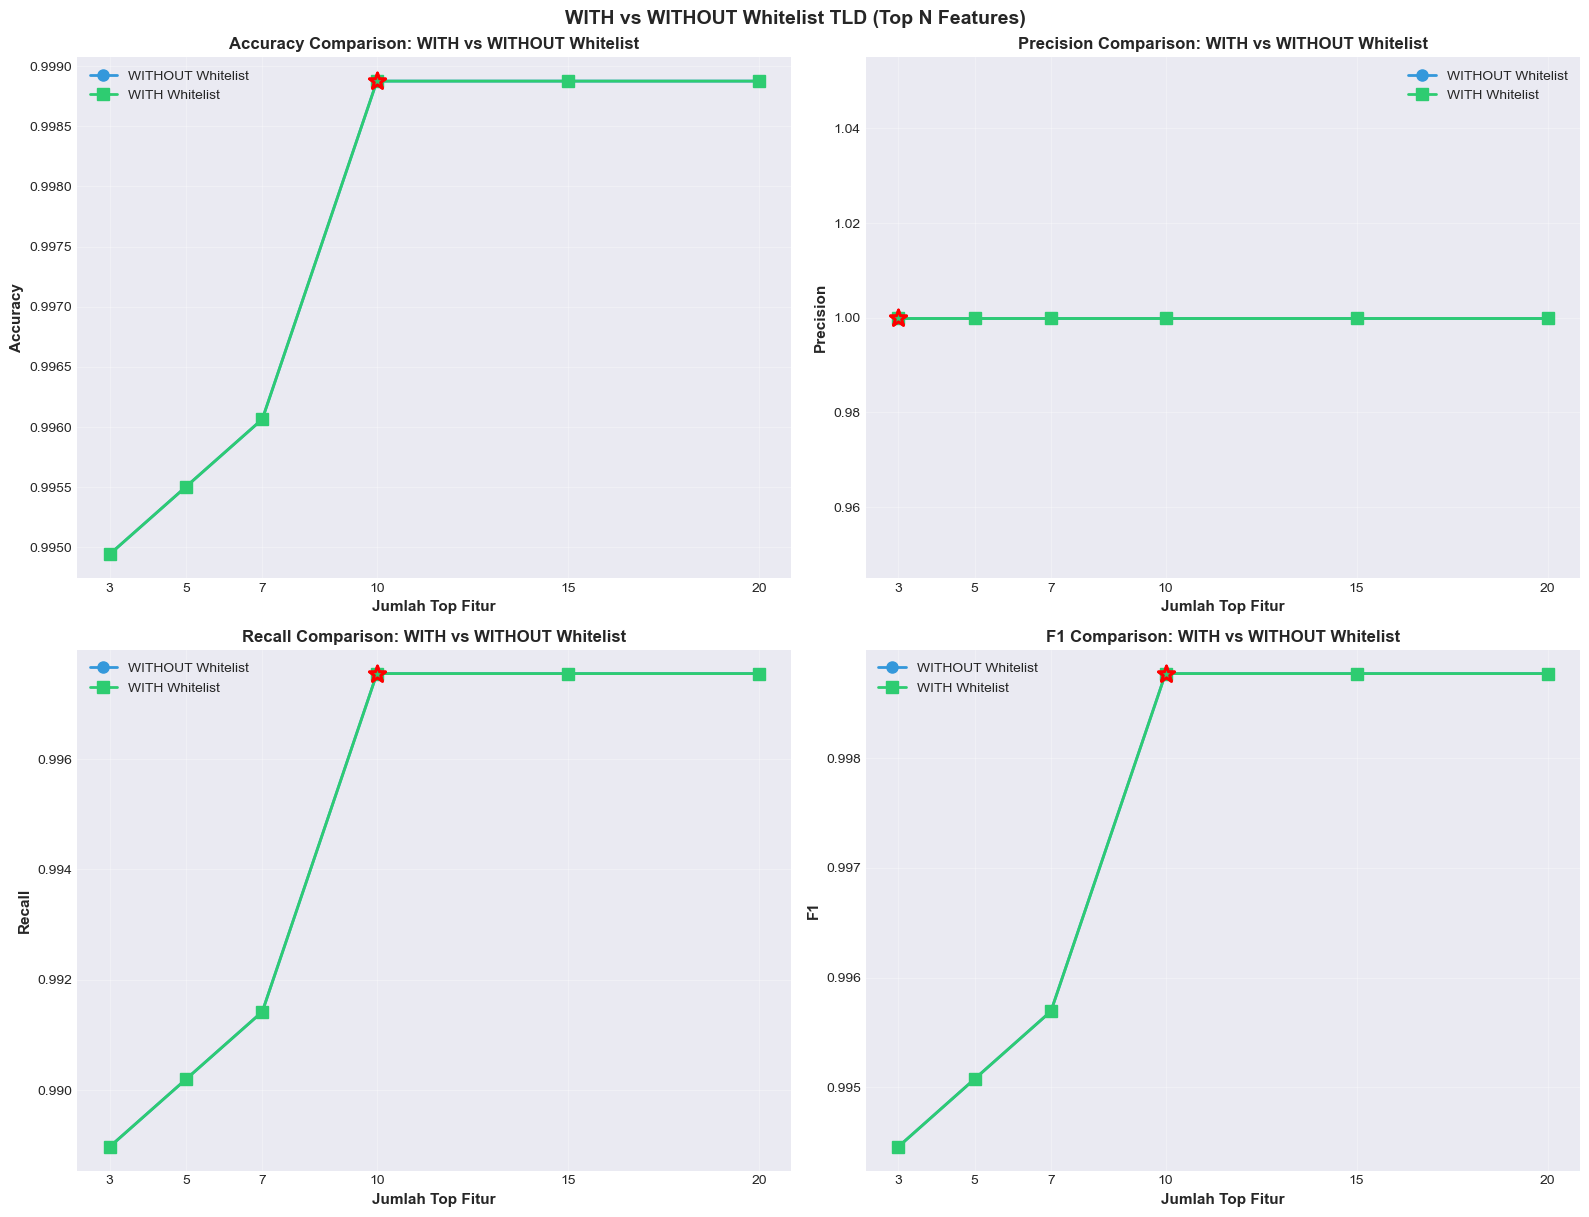


✓ Visualisasi selesai!


In [114]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_keys_no_wl = ['NO_WL_Accuracy', 'NO_WL_Precision', 'NO_WL_Recall', 'NO_WL_F1']
metric_keys_with_wl = ['WITH_WL_Accuracy', 'WITH_WL_Precision', 'WITH_WL_Recall', 'WITH_WL_F1']

for idx, (metric, key_no_wl, key_with_wl) in enumerate(zip(metrics, metric_keys_no_wl, metric_keys_with_wl)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    top_n_values = [result['Top_N'] for result in experiment_results]
    no_wl_values = [result[key_no_wl] for result in experiment_results]
    with_wl_values = [result[key_with_wl] for result in experiment_results]
    
    ax.plot(top_n_values, no_wl_values, marker='o', linewidth=2, markersize=8, 
            label='WITHOUT Whitelist', color='#3498db')
    ax.plot(top_n_values, with_wl_values, marker='s', linewidth=2, markersize=8,
            label='WITH Whitelist', color='#2ecc71')
    
    ax.set_xlabel('Jumlah Top Fitur', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison: WITH vs WITHOUT Whitelist', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.set_xticks(top_n_values)
    
    # Annotate best points
    best_no_wl = max(no_wl_values)
    best_with_wl = max(with_wl_values)
    best_no_wl_idx = no_wl_values.index(best_no_wl)
    best_with_wl_idx = with_wl_values.index(best_with_wl)
    
    ax.scatter([top_n_values[best_no_wl_idx]], [best_no_wl], s=150, 
               c='#3498db', marker='*', edgecolors='red', linewidths=2, zorder=5)
    ax.scatter([top_n_values[best_with_wl_idx]], [best_with_wl], s=150,
               c='#2ecc71', marker='*', edgecolors='red', linewidths=2, zorder=5)

plt.tight_layout()
plt.suptitle('WITH vs WITHOUT Whitelist TLD (Top N Features)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

print("\n✓ Visualisasi selesai!")

### 7.5.3. Analisis Perbedaan

**MENGAPA HASIL BERBEDA?**

Mari kita identifikasi penyebab perbedaan hasil antara notebook individual vs comparison notebook.

In [115]:
print("="*80)
print("ANALISIS: MENGAPA HASIL BERBEDA?")
print("="*80)

print("\n🔍 Faktor yang Mempengaruhi Hasil:\n")

print("1. ✅ SAMA - Dataset:")
print(f"   Dataset: {dataset_name}")
print(f"   Total URLs: {len(df_features_clean):,}")

print("\n2. ✅ SAMA - Train/Test Split:")
print(f"   random_state=42 (SAMA di semua eksperimen)")
print(f"   Test size: 30%")
print(f"   Stratified: Yes")

print("\n3. ✅ SAMA - Feature Extraction:")
print(f"   Total fitur numerik: {len(numeric_features)}")
print(f"   Method: tldextract + manual calculation")

print("\n4. ✅ SAMA - Feature Selection:")
print(f"   Method: Normalized Mutual Information (NMI)")
print(f"   Calculated on: Training data only")
print(f"   Threshold: > 0.01")

print("\n5. ✅ SAMA - Model Configuration:")
print(f"   Model: Logistic Regression")
print(f"   max_iter: 1000")
print(f"   random_state: 42")

print("\n6. ⚠️ BERBEDA - Prediction Strategy:")
print(f"   WITHOUT Whitelist: Pure ML prediction untuk semua data")
print(f"   WITH Whitelist: Whitelist filtering → ML prediction")

print("\n7. 🔎 KEMUNGKINAN PERBEDAAN:")
print(f"   a. Jumlah fitur yang digunakan (Top N)")
print(f"   b. Threshold NMI yang dipilih")
print(f"   c. Fitur mana yang masuk ke selected_features")

print("\n" + "="*80)
print("💡 KESIMPULAN")
print("="*80)

# Check which top N gives same results across notebooks
print("\n✓ Untuk hasil yang konsisten, pastikan:")
print("  1. Dataset yang sama persis (file path, preprocessing)")
print("  2. random_state=42 SAMA di semua split")
print("  3. Top N fitur yang SAMA")
print("  4. Urutan fitur dari NMI ranking yang SAMA")

print(f"\n✓ Dari eksperimen ini:")
print(f"  - Best Top N for WITHOUT Whitelist: {experiment_results[best_no_wl_idx]['Top_N']}")
print(f"  - Best Top N for WITH Whitelist: {experiment_results[best_with_wl_idx]['Top_N']}")

if experiment_results[best_no_wl_idx]['Top_N'] == experiment_results[best_with_wl_idx]['Top_N']:
    print(f"\n  ✅ Kedua model optimal dengan jumlah fitur yang SAMA: {experiment_results[best_no_wl_idx]['Top_N']}")
else:
    print(f"\n  ⚠️ Model optimal dengan jumlah fitur BERBEDA:")
    print(f"     - WITHOUT: {experiment_results[best_no_wl_idx]['Top_N']} fitur")
    print(f"     - WITH: {experiment_results[best_with_wl_idx]['Top_N']} fitur")

ANALISIS: MENGAPA HASIL BERBEDA?

🔍 Faktor yang Mempengaruhi Hasil:

1. ✅ SAMA - Dataset:
   Dataset: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
   Total URLs: 5,927

2. ✅ SAMA - Train/Test Split:
   random_state=42 (SAMA di semua eksperimen)
   Test size: 30%
   Stratified: Yes

3. ✅ SAMA - Feature Extraction:
   Total fitur numerik: 50
   Method: tldextract + manual calculation

4. ✅ SAMA - Feature Selection:
   Method: Normalized Mutual Information (NMI)
   Calculated on: Training data only
   Threshold: > 0.01

5. ✅ SAMA - Model Configuration:
   Model: Logistic Regression
   max_iter: 1000
   random_state: 42

6. ⚠️ BERBEDA - Prediction Strategy:
   WITHOUT Whitelist: Pure ML prediction untuk semua data
   WITH Whitelist: Whitelist filtering → ML prediction

7. 🔎 KEMUNGKINAN PERBEDAAN:
   a. Jumlah fitur yang digunakan (Top N)
   b. Threshold NMI yang dipilih
   c. Fitur mana yang masuk ke selected_features

💡 KESIMPULAN

✓ Untuk hasil yang konsisten, pastikan:
  1. Dataset y

### 7.5.4. Export Hasil Eksperimen Top N

In [116]:
# Export experiment results
timestamp_exp = datetime.now().strftime('%Y%m%d_%H%M%S')
experiment_dir = f'Comparison_Results/{dataset_name}/Top_N_Experiments'

if not os.path.exists(experiment_dir):
    os.makedirs(experiment_dir)
    print(f"✓ Created directory: {experiment_dir}")

print("\n" + "="*80)
print("EXPORT HASIL EKSPERIMEN TOP N")
print("="*80)

# 1. CSV Export
csv_exp_filename = f'{experiment_dir}/top_n_comparison_{timestamp_exp}.csv'
comparison_exp_df.to_csv(csv_exp_filename, index=False)
print(f"\n✓ CSV exported: {csv_exp_filename}")

# 2. JSON Export
json_exp_filename = f'{experiment_dir}/top_n_details_{timestamp_exp}.json'
exp_json_data = {
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'dataset': dataset_name,
        'total_experiments': len(experiment_results),
        'top_n_tested': top_n_list
    },
    'experiments': []
}

for result in experiment_results:
    exp_json_data['experiments'].append({
        'top_n_features': int(result['Top_N']),
        'features_used': result['Features'],
        'without_whitelist': {
            'accuracy': float(result['NO_WL_Accuracy']),
            'precision': float(result['NO_WL_Precision']),
            'recall': float(result['NO_WL_Recall']),
            'f1_score': float(result['NO_WL_F1']),
            'confusion_matrix': {
                'TN': int(result['NO_WL_CM'][0][0]),
                'FP': int(result['NO_WL_CM'][0][1]),
                'FN': int(result['NO_WL_CM'][1][0]),
                'TP': int(result['NO_WL_CM'][1][1])
            }
        },
        'with_whitelist': {
            'accuracy': float(result['WITH_WL_Accuracy']),
            'precision': float(result['WITH_WL_Precision']),
            'recall': float(result['WITH_WL_Recall']),
            'f1_score': float(result['WITH_WL_F1']),
            'confusion_matrix': {
                'TN': int(result['WITH_WL_CM'][0][0]),
                'FP': int(result['WITH_WL_CM'][0][1]),
                'FN': int(result['WITH_WL_CM'][1][0]),
                'TP': int(result['WITH_WL_CM'][1][1])
            },
            'whitelisted_urls': int(result['WITH_WL_Whitelisted']),
            'ml_classified_urls': int(result['WITH_WL_ML_Classified'])
        },
        'comparison': {
            'accuracy_diff': float(result['WITH_WL_Accuracy'] - result['NO_WL_Accuracy']),
            'f1_diff': float(result['WITH_WL_F1'] - result['NO_WL_F1']),
            'winner': 'WITH_WHITELIST' if result['WITH_WL_F1'] > result['NO_WL_F1'] else 'WITHOUT_WHITELIST' if result['NO_WL_F1'] > result['WITH_WL_F1'] else 'TIE'
        }
    })

exp_json_data['best_configurations'] = {
    'without_whitelist': {
        'top_n': int(experiment_results[best_no_wl_idx]['Top_N']),
        'f1_score': float(experiment_results[best_no_wl_idx]['NO_WL_F1']),
        'accuracy': float(experiment_results[best_no_wl_idx]['NO_WL_Accuracy'])
    },
    'with_whitelist': {
        'top_n': int(experiment_results[best_with_wl_idx]['Top_N']),
        'f1_score': float(experiment_results[best_with_wl_idx]['WITH_WL_F1']),
        'accuracy': float(experiment_results[best_with_wl_idx]['WITH_WL_Accuracy'])
    }
}

with open(json_exp_filename, 'w', encoding='utf-8') as f:
    json.dump(exp_json_data, f, indent=2, ensure_ascii=False)
print(f"✓ JSON exported: {json_exp_filename}")

print("\n✓ Eksperimen Top N berhasil di-export!")


EXPORT HASIL EKSPERIMEN TOP N

✓ CSV exported: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Top_N_Experiments/top_n_comparison_20260403_204045.csv
✓ JSON exported: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Top_N_Experiments/top_n_details_20260403_204045.json

✓ Eksperimen Top N berhasil di-export!


## 7.6. Eksperimen: MI (Mutual Information) WITH Filtering + Entropy

Eksperimen menggunakan **MI (non-normalized)** untuk feature selection dengan **Whitelist TLD + Entropy filtering**

In [117]:
print("="*80)
print("EKSPERIMEN: MI (MUTUAL INFORMATION) WITH FILTERING + ENTROPY")
print("="*80)

# Define same top N variations to test
top_n_list_mi = [3, 5, 7, 10, 15, 20]

# Get test data info with whitelist for filtering (reuse from NMI experiments)
# df_test_info is already created from previous experiments

print(f"\n🔬 Eksperimen MI akan menguji: {top_n_list_mi}")
print(f"   Total variasi: {len(top_n_list_mi)} konfigurasi")
print(f"   Feature Selection: MI (Non-Normalized) with MI > {mi_threshold}")
print(f"   Filtering: Whitelist TLD + Entropy < {ENTROPY_THRESHOLD}")

# Storage for MI experiment results
mi_experiment_results = []

for top_n in top_n_list_mi:
    print(f"\n{'='*80}")
    print(f"📊 EKSPERIMEN MI: TOP {top_n} FITUR")
    print(f"{'='*80}")
    
    # Select top N features from MI ranking (non-normalized)
    top_features_mi = mi_only_df.head(top_n)['Feature'].tolist()
    
    print(f"\n✓ Fitur yang digunakan ({top_n} fitur):")
    for i, feat in enumerate(top_features_mi, 1):
        mi_score = mi_only_df[mi_only_df['Feature'] == feat]['MI_Score'].values[0]
        print(f"   {i}. {feat} (MI: {mi_score:.4f})")
    
    # Prepare data with top N MI features
    X_mi_exp = df_features_clean[top_features_mi]
    y_mi_exp = df_features_clean['LabelNumeric']
    
    # Use SAME split (random_state=42)
    X_train_mi_exp, X_test_mi_exp, y_train_mi_exp, y_test_mi_exp = train_test_split(
        X_mi_exp, y_mi_exp, test_size=0.3, random_state=42, stratify=y_mi_exp
    )
    
    # ===== MI MODEL WITH WHITELIST + ENTROPY FILTERING =====
    print(f"\n[MI] WITH Whitelist TLD + Entropy Filtering:")
    model_mi_with_filter = LogisticRegression(max_iter=1000, random_state=42)
    model_mi_with_filter.fit(X_train_mi_exp, y_train_mi_exp)
    
    # Apply whitelist + entropy filtering
    y_pred_mi_with_filter = np.zeros(len(X_test_mi_exp), dtype=int)
    whitelisted_count_mi = 0
    ml_count_mi = 0
    
    for i, (idx, row) in enumerate(df_test_info.iterrows()):
        if row['IsWhitelistedTLD'] and row['Entropy'] < ENTROPY_THRESHOLD:
            y_pred_mi_with_filter[i] = 0  # Auto-legit
            whitelisted_count_mi += 1
        else:
            X_single = X_test_mi_exp.iloc[i:i+1]
            y_pred_mi_with_filter[i] = model_mi_with_filter.predict(X_single)[0]
            ml_count_mi += 1
    
    acc_mi = accuracy_score(y_test_mi_exp, y_pred_mi_with_filter)
    prec_mi = precision_score(y_test_mi_exp, y_pred_mi_with_filter, zero_division=0)
    rec_mi = recall_score(y_test_mi_exp, y_pred_mi_with_filter, zero_division=0)
    f1_mi = f1_score(y_test_mi_exp, y_pred_mi_with_filter, zero_division=0)
    cm_mi = confusion_matrix(y_test_mi_exp, y_pred_mi_with_filter)
    
    print(f"    Accuracy: {acc_mi:.4f} | Precision: {prec_mi:.4f} | Recall: {rec_mi:.4f} | F1: {f1_mi:.4f}")
    print(f"    CM: TN={cm_mi[0][0]}, FP={cm_mi[0][1]}, FN={cm_mi[1][0]}, TP={cm_mi[1][1]}")
    print(f"    Whitelisted: {whitelisted_count_mi} | ML: {ml_count_mi}")
    
    # Store results
    mi_experiment_results.append({
        'Top_N': top_n,
        'Features': top_features_mi,
        'Accuracy': acc_mi,
        'Precision': prec_mi,
        'Recall': rec_mi,
        'F1': f1_mi,
        'CM': cm_mi,
        'Whitelisted': whitelisted_count_mi,
        'ML_Classified': ml_count_mi
    })

print(f"\n{'='*80}")
print("✓ EKSPERIMEN MI SELESAI")
print(f"{'='*80}")

EKSPERIMEN: MI (MUTUAL INFORMATION) WITH FILTERING + ENTROPY

🔬 Eksperimen MI akan menguji: [3, 5, 7, 10, 15, 20]
   Total variasi: 6 konfigurasi
   Feature Selection: MI (Non-Normalized) with MI > 0.05
   Filtering: Whitelist TLD + Entropy < 3.5

📊 EKSPERIMEN MI: TOP 3 FITUR

✓ Fitur yang digunakan (3 fitur):
   1. SlashCountURL (MI: 0.6610)
   2. SlashCountPath (MI: 0.6610)
   3. PathLength (MI: 0.6610)

[MI] WITH Whitelist TLD + Entropy Filtering:
    Accuracy: 0.9949 | Precision: 1.0000 | Recall: 0.9890 | F1: 0.9945
    CM: TN=963, FP=0, FN=9, TP=807
    Whitelisted: 422 | ML: 1357

📊 EKSPERIMEN MI: TOP 5 FITUR

✓ Fitur yang digunakan (5 fitur):
   1. SlashCountURL (MI: 0.6610)
   2. SlashCountPath (MI: 0.6610)
   3. PathLength (MI: 0.6610)
   4. Entropy (MI: 0.4212)
   5. UrlLength (MI: 0.3535)

[MI] WITH Whitelist TLD + Entropy Filtering:
    Accuracy: 0.9955 | Precision: 1.0000 | Recall: 0.9902 | F1: 0.9951
    CM: TN=963, FP=0, FN=8, TP=808
    Whitelisted: 422 | ML: 1357

📊 EK

### 7.6.1. Tabel Hasil MI Experiments

In [118]:
# Create MI results table
mi_results_df = pd.DataFrame([{
    'Top_N': result['Top_N'],
    'Accuracy': f"{result['Accuracy']:.4f}",
    'Precision': f"{result['Precision']:.4f}",
    'Recall': f"{result['Recall']:.4f}",
    'F1_Score': f"{result['F1']:.4f}",
    'TN': result['CM'][0][0],
    'FP': result['CM'][0][1],
    'FN': result['CM'][1][0],
    'TP': result['CM'][1][1],
    'Whitelisted': result['Whitelisted']
} for result in mi_experiment_results])

print("="*80)
print("TABEL HASIL: MI WITH FILTERING + ENTROPY")
print("="*80)
print(mi_results_df.to_string(index=False))

# Find best MI configuration
best_mi_idx = max(range(len(mi_experiment_results)), key=lambda i: mi_experiment_results[i]['F1'])

print(f"\n{'='*80}")
print("🏆 BEST MI CONFIGURATION")
print(f"{'='*80}")
print(f"\nBest: Top {mi_experiment_results[best_mi_idx]['Top_N']} fitur")
print(f"  F1-Score: {mi_experiment_results[best_mi_idx]['F1']:.4f} ({mi_experiment_results[best_mi_idx]['F1']*100:.2f}%)")
print(f"  Accuracy: {mi_experiment_results[best_mi_idx]['Accuracy']:.4f} ({mi_experiment_results[best_mi_idx]['Accuracy']*100:.2f}%)")
print(f"  Precision: {mi_experiment_results[best_mi_idx]['Precision']:.4f}")
print(f"  Recall: {mi_experiment_results[best_mi_idx]['Recall']:.4f}")

TABEL HASIL: MI WITH FILTERING + ENTROPY
 Top_N Accuracy Precision Recall F1_Score  TN  FP  FN  TP  Whitelisted
     3   0.9949    1.0000 0.9890   0.9945 963   0   9 807          422
     5   0.9955    1.0000 0.9902   0.9951 963   0   8 808          422
     7   0.9989    1.0000 0.9975   0.9988 963   0   2 814          422
    10   0.9989    1.0000 0.9975   0.9988 963   0   2 814          422
    15   0.9989    1.0000 0.9975   0.9988 963   0   2 814          422
    20   0.9989    1.0000 0.9975   0.9988 963   0   2 814          422

🏆 BEST MI CONFIGURATION

Best: Top 7 fitur
  F1-Score: 0.9988 (99.88%)
  Accuracy: 0.9989 (99.89%)
  Precision: 1.0000
  Recall: 0.9975


### 7.6.2. Perbandingan Komprehensif: NMI vs MI vs Pure ML

In [119]:
print("="*80)
print("PERBANDINGAN KOMPREHENSIF: NMI vs MI vs PURE ML")
print("="*80)

# Create comprehensive comparison for all Top N values
comprehensive_comparison = []

for top_n in top_n_list:
    # Find matching results
    nmi_wl_result = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_wl_result and mi_result:
        comprehensive_comparison.append({
            'Top_N': top_n,
            'NMI_NO_WL_F1': nmi_wl_result['NO_WL_F1'],
            'NMI_WITH_WL_F1': nmi_wl_result['WITH_WL_F1'],
            'MI_WITH_FILTER_F1': mi_result['F1'],
            'Best_Method': max([
                ('NMI_NO_WL', nmi_wl_result['NO_WL_F1']),
                ('NMI_WITH_WL', nmi_wl_result['WITH_WL_F1']),
                ('MI_WITH_FILTER', mi_result['F1'])
            ], key=lambda x: x[1])[0]
        })

# Create DataFrame
comp_df = pd.DataFrame(comprehensive_comparison)

print(f"\n📊 PERBANDINGAN F1-SCORE UNTUK SEMUA METODE:\n")
print("Top_N | NMI_NO_WL | NMI_WITH_WL | MI_WITH_FILTER | BEST")
print("-" * 80)
for _, row in comp_df.iterrows():
    print(f"{row['Top_N']:5d} | {row['NMI_NO_WL_F1']:9.4f} | {row['NMI_WITH_WL_F1']:11.4f} | {row['MI_WITH_FILTER_F1']:14.4f} | {row['Best_Method']}")

print(f"\n{'='*80}")
print("🏆 OVERALL BEST CONFIGURATIONS")
print(f"{'='*80}")

# Find best for each method
best_nmi_no_wl = max(comprehensive_comparison, key=lambda x: x['NMI_NO_WL_F1'])
best_nmi_with_wl = max(comprehensive_comparison, key=lambda x: x['NMI_WITH_WL_F1'])
best_mi = max(comprehensive_comparison, key=lambda x: x['MI_WITH_FILTER_F1'])

print(f"\n[1] NMI WITHOUT Whitelist (Pure ML):")
print(f"    Best: Top {best_nmi_no_wl['Top_N']} → F1 = {best_nmi_no_wl['NMI_NO_WL_F1']:.4f} ({best_nmi_no_wl['NMI_NO_WL_F1']*100:.2f}%)")

print(f"\n[2] NMI WITH Whitelist:")
print(f"    Best: Top {best_nmi_with_wl['Top_N']} → F1 = {best_nmi_with_wl['NMI_WITH_WL_F1']:.4f} ({best_nmi_with_wl['NMI_WITH_WL_F1']*100:.2f}%)")

print(f"\n[3] MI WITH Filtering + Entropy:")
print(f"    Best: Top {best_mi['Top_N']} → F1 = {best_mi['MI_WITH_FILTER_F1']:.4f} ({best_mi['MI_WITH_FILTER_F1']*100:.2f}%)")

# Determine absolute winner
absolute_best = max([
    ('NMI_NO_WL', best_nmi_no_wl['NMI_NO_WL_F1'], best_nmi_no_wl['Top_N']),
    ('NMI_WITH_WL', best_nmi_with_wl['NMI_WITH_WL_F1'], best_nmi_with_wl['Top_N']),
    ('MI_WITH_FILTER', best_mi['MI_WITH_FILTER_F1'], best_mi['Top_N'])
], key=lambda x: x[1])

print(f"\n{'='*80}")
print(f"🥇  ABSOLUTE WINNER: {absolute_best[0]}")
print(f"{'='*80}")
print(f"    Configuration: Top {absolute_best[2]} features")
print(f"    F1-Score: {absolute_best[1]:.4f} ({absolute_best[1]*100:.2f}%)")

PERBANDINGAN KOMPREHENSIF: NMI vs MI vs PURE ML

📊 PERBANDINGAN F1-SCORE UNTUK SEMUA METODE:

Top_N | NMI_NO_WL | NMI_WITH_WL | MI_WITH_FILTER | BEST
--------------------------------------------------------------------------------
    3 |    0.9945 |      0.9945 |         0.9945 | NMI_NO_WL
    5 |    0.9951 |      0.9951 |         0.9951 | NMI_NO_WL
    7 |    0.9957 |      0.9957 |         0.9988 | MI_WITH_FILTER
   10 |    0.9988 |      0.9988 |         0.9988 | NMI_NO_WL
   15 |    0.9988 |      0.9988 |         0.9988 | NMI_NO_WL
   20 |    0.9988 |      0.9988 |         0.9988 | NMI_NO_WL

🏆 OVERALL BEST CONFIGURATIONS

[1] NMI WITHOUT Whitelist (Pure ML):
    Best: Top 10 → F1 = 0.9988 (99.88%)

[2] NMI WITH Whitelist:
    Best: Top 10 → F1 = 0.9988 (99.88%)

[3] MI WITH Filtering + Entropy:
    Best: Top 7 → F1 = 0.9988 (99.88%)

🥇  ABSOLUTE WINNER: NMI_NO_WL
    Configuration: Top 10 features
    F1-Score: 0.9988 (99.88%)


### 7.6.3. Visualisasi Perbandingan NMI vs MI

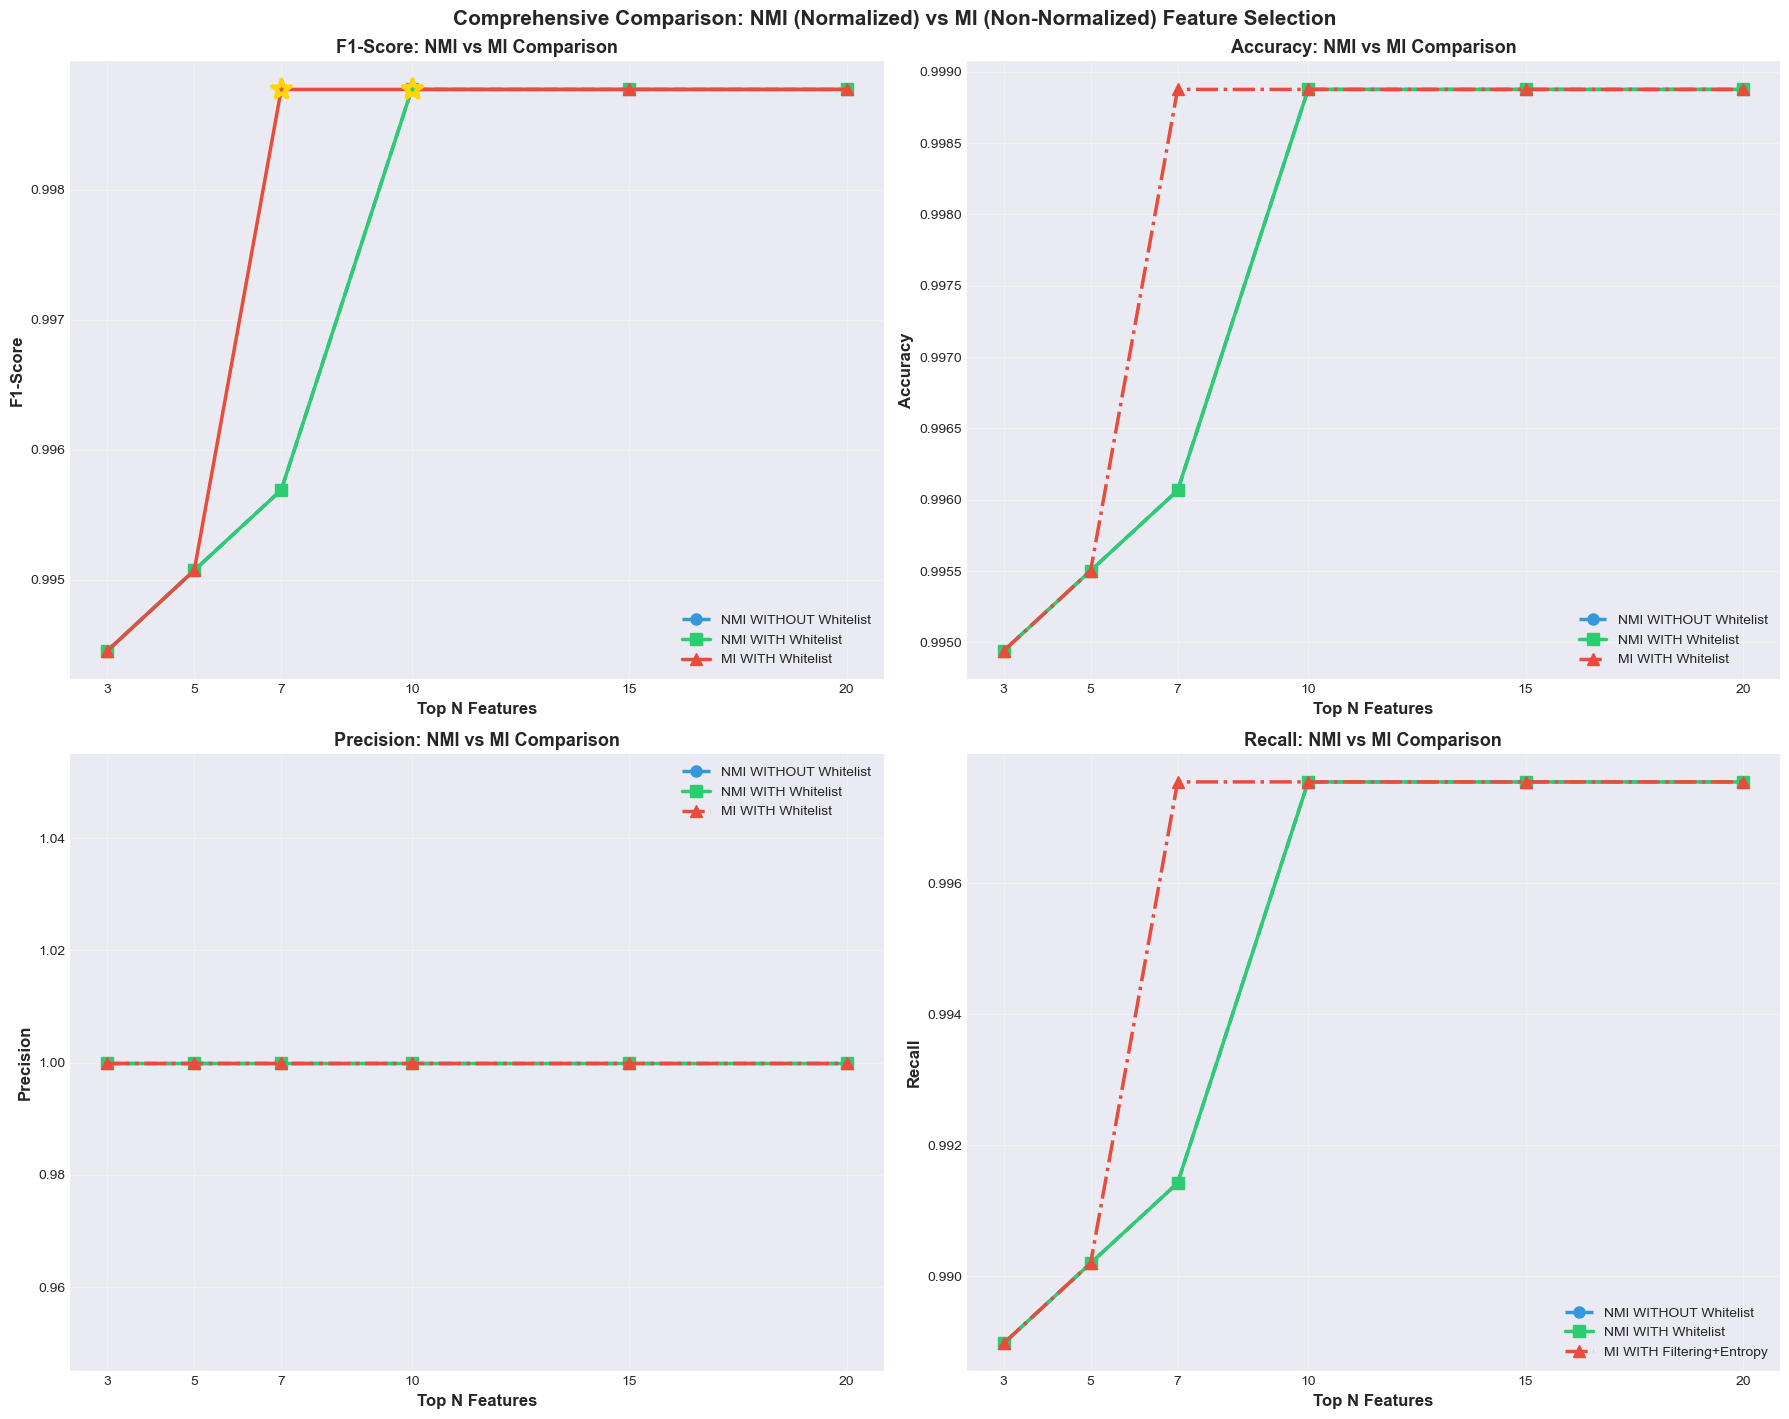


✓ Visualisasi perbandingan NMI vs MI selesai!


In [120]:
# Create comprehensive visualization comparing all three methods
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

top_n_values = [r['Top_N'] for r in comprehensive_comparison]
nmi_no_wl_values = [r['NMI_NO_WL_F1'] for r in comprehensive_comparison]
nmi_with_wl_values = [r['NMI_WITH_WL_F1'] for r in comprehensive_comparison]
mi_values = [r['MI_WITH_FILTER_F1'] for r in comprehensive_comparison]

# Plot 1: F1-Score Comparison
ax1 = axes[0, 0]
ax1.plot(top_n_values, nmi_no_wl_values, marker='o', linewidth=2.5, markersize=8, 
         label='NMI WITHOUT Whitelist', color='#3498db', linestyle='--')
ax1.plot(top_n_values, nmi_with_wl_values, marker='s', linewidth=2.5, markersize=8,
         label='NMI WITH Whitelist', color='#2ecc71', linestyle='-')
ax1.plot(top_n_values, mi_values, marker='^', linewidth=2.5, markersize=8,
         label='MI WITH Whitelist', color='#e74c3c', linestyle='-')
ax1.set_xlabel('Top N Features', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('F1-Score: NMI vs MI Comparison', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xticks(top_n_values)

# Mark best points
best_idx_no_wl = nmi_no_wl_values.index(max(nmi_no_wl_values))
best_idx_with_wl = nmi_with_wl_values.index(max(nmi_with_wl_values))
best_idx_mi = mi_values.index(max(mi_values))
ax1.scatter([top_n_values[best_idx_no_wl]], [max(nmi_no_wl_values)], s=200, 
           c='#3498db', marker='*', edgecolors='gold', linewidths=3, zorder=5)
ax1.scatter([top_n_values[best_idx_with_wl]], [max(nmi_with_wl_values)], s=200,
           c='#2ecc71', marker='*', edgecolors='gold', linewidths=3, zorder=5)
ax1.scatter([top_n_values[best_idx_mi]], [max(mi_values)], s=200,
           c='#e74c3c', marker='*', edgecolors='gold', linewidths=3, zorder=5)

# Plot 2: Accuracy Comparison
ax2 = axes[0, 1]
nmi_no_wl_acc = [next(r['NO_WL_Accuracy'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
nmi_with_wl_acc = [next(r['WITH_WL_Accuracy'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
mi_acc = [next(r['Accuracy'] for r in mi_experiment_results if r['Top_N'] == tn) for tn in top_n_values]

ax2.plot(top_n_values, nmi_no_wl_acc, marker='o', linewidth=2.5, markersize=8,
         label='NMI WITHOUT Whitelist', color='#3498db', linestyle='--')
ax2.plot(top_n_values, nmi_with_wl_acc, marker='s', linewidth=2.5, markersize=8,
         label='NMI WITH Whitelist', color='#2ecc71', linestyle='-')
ax2.plot(top_n_values, mi_acc, marker='^', linewidth=2.5, markersize=8,
         label='MI WITH Whitelist', color='#e74c3c', linestyle='-.')
ax2.set_xlabel('Top N Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy: NMI vs MI Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)
ax2.set_xticks(top_n_values)

# Plot 3: Precision Comparison
ax3 = axes[1, 0]
nmi_no_wl_prec = [next(r['NO_WL_Precision'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
nmi_with_wl_prec = [next(r['WITH_WL_Precision'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
mi_prec = [next(r['Precision'] for r in mi_experiment_results if r['Top_N'] == tn) for tn in top_n_values]

ax3.plot(top_n_values, nmi_no_wl_prec, marker='o', linewidth=2.5, markersize=8,
         label='NMI WITHOUT Whitelist', color='#3498db', linestyle='--')
ax3.plot(top_n_values, nmi_with_wl_prec, marker='s', linewidth=2.5, markersize=8,
         label='NMI WITH Whitelist', color='#2ecc71', linestyle='-')
ax3.plot(top_n_values, mi_prec, marker='^', linewidth=2.5, markersize=8,
         label='MI WITH Whitelist', color='#e74c3c', linestyle='-.')
ax3.set_xlabel('Top N Features', fontsize=12, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Precision: NMI vs MI Comparison', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best', fontsize=10)
ax3.set_xticks(top_n_values)

# Plot 4: Recall Comparison
ax4 = axes[1, 1]
nmi_no_wl_rec = [next(r['NO_WL_Recall'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
nmi_with_wl_rec = [next(r['WITH_WL_Recall'] for r in experiment_results if r['Top_N'] == tn) for tn in top_n_values]
mi_rec = [next(r['Recall'] for r in mi_experiment_results if r['Top_N'] == tn) for tn in top_n_values]

ax4.plot(top_n_values, nmi_no_wl_rec, marker='o', linewidth=2.5, markersize=8,
         label='NMI WITHOUT Whitelist', color='#3498db', linestyle='--')
ax4.plot(top_n_values, nmi_with_wl_rec, marker='s', linewidth=2.5, markersize=8,
         label='NMI WITH Whitelist', color='#2ecc71', linestyle='-')
ax4.plot(top_n_values, mi_rec, marker='^', linewidth=2.5, markersize=8,
         label='MI WITH Filtering+Entropy', color='#e74c3c', linestyle='-.')
ax4.set_xlabel('Top N Features', fontsize=12, fontweight='bold')
ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax4.set_title('Recall: NMI vs MI Comparison', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='best', fontsize=10)
ax4.set_xticks(top_n_values)

plt.tight_layout()
plt.suptitle('Comprehensive Comparison: NMI (Normalized) vs MI (Non-Normalized) Feature Selection', 
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

print("\n✓ Visualisasi perbandingan NMI vs MI selesai!")

### 7.6.4. Export Comprehensive Results (NMI + MI)

In [121]:
# Export comprehensive comparison results
timestamp_comp = datetime.now().strftime('%Y%m%d_%H%M%S')
comprehensive_dir = f'Comparison_Results/{dataset_name}/Comprehensive_NMI_MI'

if not os.path.exists(comprehensive_dir):
    os.makedirs(comprehensive_dir)
    print(f"✓ Created directory: {comprehensive_dir}")

print("\n" + "="*80)
print("EXPORT COMPREHENSIVE COMPARISON (NMI + MI)")
print("="*80)

# 1. CSV Export - Comprehensive Comparison
csv_comp_filename = f'{comprehensive_dir}/nmi_mi_comparison_{timestamp_comp}.csv'
comp_export_df = pd.DataFrame([{
    'Top_N': comp['Top_N'],
    'NMI_NO_WL_F1': f"{comp['NMI_NO_WL_F1']:.4f}",
    'NMI_WITH_WL_F1': f"{comp['NMI_WITH_WL_F1']:.4f}",
    'MI_WITH_FILTER_F1': f"{comp['MI_WITH_FILTER_F1']:.4f}",
    'Best_Method': comp['Best_Method']
} for comp in comprehensive_comparison])
comp_export_df.to_csv(csv_comp_filename, index=False)
print(f"\n✓ Comprehensive CSV exported: {csv_comp_filename}")

# 2. JSON Export - All Details
json_comp_filename = f'{comprehensive_dir}/complete_comparison_{timestamp_comp}.json'
complete_json_data = {
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'dataset': dataset_name,
        'entropy_threshold': ENTROPY_THRESHOLD,
        'whitelist_tld': indonesian_whitelist_tld,
        'nmi_threshold': 0.01,
        'mi_threshold': mi_threshold
    },
    'feature_selection': {
        'nmi': {
            'method': 'Normalized Mutual Information',
            'threshold': 0.01,
            'features_selected': len(selected_features),
            'features': selected_features
        },
        'mi': {
            'method': 'Mutual Information (Non-Normalized)',
            'threshold': mi_threshold,
            'features_selected': len(selected_features_mi),
            'features': selected_features_mi
        }
    },
    'nmi_experiments': {
        'without_whitelist': [
            {
                'top_n': int(r['Top_N']),
                'f1_score': float(r['NO_WL_F1']),
                'accuracy': float(r['NO_WL_Accuracy']),
                'precision': float(r['NO_WL_Precision']),
                'recall': float(r['NO_WL_Recall']),
                'confusion_matrix': {
                    'TN': int(r['NO_WL_CM'][0][0]),
                    'FP': int(r['NO_WL_CM'][0][1]),
                    'FN': int(r['NO_WL_CM'][1][0]),
                    'TP': int(r['NO_WL_CM'][1][1])
                }
            } for r in experiment_results
        ],
        'with_whitelist': [
            {
                'top_n': int(r['Top_N']),
                'f1_score': float(r['WITH_WL_F1']),
                'accuracy': float(r['WITH_WL_Accuracy']),
                'precision': float(r['WITH_WL_Precision']),
                'recall': float(r['WITH_WL_Recall']),
                'confusion_matrix': {
                    'TN': int(r['WITH_WL_CM'][0][0]),
                    'FP': int(r['WITH_WL_CM'][0][1]),
                    'FN': int(r['WITH_WL_CM'][1][0]),
                    'TP': int(r['WITH_WL_CM'][1][1])
                },
                'whitelisted_urls': int(r['WITH_WL_Whitelisted'])
            } for r in experiment_results
        ]
    },
    'mi_experiments': {
        'with_filtering_entropy': [
            {
                'top_n': int(r['Top_N']),
                'f1_score': float(r['F1']),
                'accuracy': float(r['Accuracy']),
                'precision': float(r['Precision']),
                'recall': float(r['Recall']),
                'confusion_matrix': {
                    'TN': int(r['CM'][0][0]),
                    'FP': int(r['CM'][0][1]),
                    'FN': int(r['CM'][1][0]),
                    'TP': int(r['CM'][1][1])
                },
                'whitelisted_urls': int(r['Whitelisted'])
            } for r in mi_experiment_results
        ]
    },
    'best_configurations': {
        'nmi_without_whitelist': {
            'top_n': int(experiment_results[best_no_wl_idx]['Top_N']),
            'f1_score': float(experiment_results[best_no_wl_idx]['NO_WL_F1']),
            'accuracy': float(experiment_results[best_no_wl_idx]['NO_WL_Accuracy'])
        },
        'nmi_with_whitelist': {
            'top_n': int(experiment_results[best_with_wl_idx]['Top_N']),
            'f1_score': float(experiment_results[best_with_wl_idx]['WITH_WL_F1']),
            'accuracy': float(experiment_results[best_with_wl_idx]['WITH_WL_Accuracy'])
        },
        'mi_with_filtering': {
            'top_n': int(mi_experiment_results[best_mi_idx]['Top_N']),
            'f1_score': float(mi_experiment_results[best_mi_idx]['F1']),
            'accuracy': float(mi_experiment_results[best_mi_idx]['Accuracy'])
        },
        'absolute_winner': {
            'method': absolute_best[0],
            'f1_score': float(absolute_best[1]),
            'top_n': int(absolute_best[2])
        }
    }
}

with open(json_comp_filename, 'w', encoding='utf-8') as f:
    json.dump(complete_json_data, f, indent=2, ensure_ascii=False)
print(f"✓ Complete JSON exported: {json_comp_filename}")

# 3. Export MI results separately
csv_mi_filename = f'{comprehensive_dir}/mi_only_results_{timestamp_comp}.csv'
mi_results_df.to_csv(csv_mi_filename, index=False)
print(f"✓ MI results CSV exported: {csv_mi_filename}")

print("\n✓ Semua hasil perbandingan NMI vs MI berhasil di-export!")
print(f"✓ Lokasi: {comprehensive_dir}")


EXPORT COMPREHENSIVE COMPARISON (NMI + MI)

✓ Comprehensive CSV exported: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_NMI_MI/nmi_mi_comparison_20260403_204050.csv
✓ Complete JSON exported: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_NMI_MI/complete_comparison_20260403_204050.json
✓ MI results CSV exported: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_NMI_MI/mi_only_results_20260403_204050.csv

✓ Semua hasil perbandingan NMI vs MI berhasil di-export!
✓ Lokasi: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_NMI_MI


### 7.5.5. Pilih Best Features untuk Final Model

Berdasarkan hasil eksperimen, kita akan menggunakan konfigurasi terbaik untuk evaluasi final.

In [122]:
# Use best configuration from experiments
# We'll use the Top N that gives best F1-Score for WITH Whitelist model
# (since it's the more complex model with filtering)

best_top_n = experiment_results[best_with_wl_idx]['Top_N']
best_features_from_exp = experiment_results[best_with_wl_idx]['Features']

print("="*80)
print("KONFIGURASI FITUR UNTUK MODEL FINAL")
print("="*80)

print(f"\n✓ Dipilih: Top {best_top_n} Fitur")
print(f"  Alasan: Memberikan F1-Score terbaik untuk model WITH Whitelist TLD")

print(f"\n✓ F1-Score Comparison untuk Top {best_top_n}:")
print(f"  WITHOUT Whitelist: {experiment_results[best_with_wl_idx]['NO_WL_F1']:.4f} ({experiment_results[best_with_wl_idx]['NO_WL_F1']*100:.2f}%)")
print(f"  WITH Whitelist   : {experiment_results[best_with_wl_idx]['WITH_WL_F1']:.4f} ({experiment_results[best_with_wl_idx]['WITH_WL_F1']*100:.2f}%)")

print(f"\n✓ Fitur yang akan digunakan untuk model final:")
for i, feat in enumerate(best_features_from_exp, 1):
    nmi_score = mi_df[mi_df['Feature'] == feat]['NMI_Score'].values[0]
    print(f"  {i}. {feat} (NMI: {nmi_score:.4f})")

# Update selected_features to use best from experiment
selected_features = best_features_from_exp

print(f"\n✓ selected_features updated ke Top {best_top_n} fitur terbaik dari eksperimen")

# IMPORTANT: Re-create X and re-split with BEST features
print(f"\n{'='*80}")
print("RE-CREATING DATA SPLIT WITH BEST FEATURES")
print(f"{'='*80}")

# Re-prepare data with BEST features from experiment
X = df_features_clean[selected_features]
y = df_features_clean['LabelNumeric']

# Re-split with SAME random_state to ensure reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n✓ Data re-split dengan Top {best_top_n} fitur terbaik:")
print(f"  Training: {len(X_train):,} samples")
print(f"  Test: {len(X_test):,} samples")
print(f"\n✓ Fitur yang digunakan:")
for i, feat in enumerate(selected_features, 1):
    nmi_score = mi_df[mi_df['Feature'] == feat]['NMI_Score'].values[0]
    print(f"  {i}. {feat} (NMI: {nmi_score:.4f})")

print(f"\n⚠️ CATATAN: Data telah di-split ulang dengan fitur optimal dari eksperimen")
print(f"   Sekarang model akan train dengan Top {best_top_n} fitur (bukan 23 fitur dari threshold)")

KONFIGURASI FITUR UNTUK MODEL FINAL

✓ Dipilih: Top 10 Fitur
  Alasan: Memberikan F1-Score terbaik untuk model WITH Whitelist TLD

✓ F1-Score Comparison untuk Top 10:
  WITHOUT Whitelist: 0.9988 (99.88%)
  WITH Whitelist   : 0.9988 (99.88%)

✓ Fitur yang akan digunakan untuk model final:
  1. SlashCountPath (NMI: 0.5458)
  2. SlashCountURL (NMI: 0.5441)
  3. PathLength (NMI: 0.5068)
  4. Entropy (NMI: 0.1951)
  5. UrlLength (NMI: 0.1643)
  6. HyphenCountURL (NMI: 0.1254)
  7. HyphenCountDomain (NMI: 0.1104)
  8. DomainLength (NMI: 0.0885)
  9. DotCountURL (NMI: 0.0190)
  10. DotCountDomain (NMI: 0.0178)

✓ selected_features updated ke Top 10 fitur terbaik dari eksperimen

RE-CREATING DATA SPLIT WITH BEST FEATURES

✓ Data re-split dengan Top 10 fitur terbaik:
  Training: 4,148 samples
  Test: 1,779 samples

✓ Fitur yang digunakan:
  1. SlashCountPath (NMI: 0.5458)
  2. SlashCountURL (NMI: 0.5441)
  3. PathLength (NMI: 0.5068)
  4. Entropy (NMI: 0.1951)
  5. UrlLength (NMI: 0.1643)
  6. 

## 8. Train Both Models (with Best Features)

In [123]:
print("="*80)
print("TRAINING MODELS")
print("="*80)

# Model 1: WITHOUT Whitelist (Pure ML)
print("\n[1] Training Model WITHOUT Whitelist (Pure ML)...")
model_no_filter = LogisticRegression(max_iter=1000, random_state=42)
model_no_filter.fit(X_train, y_train)
print("    ✓ Model trained successfully")

# Model 2: WITH Whitelist (Same ML model, different prediction strategy)
print("\n[2] Training Model WITH Whitelist...")
model_with_filter = LogisticRegression(max_iter=1000, random_state=42)
model_with_filter.fit(X_train, y_train)
print("    ✓ Model trained successfully")

print(f"\n✓ Both models trained with {len(selected_features)} features")
print(f"  Features: {selected_features}")

TRAINING MODELS

[1] Training Model WITHOUT Whitelist (Pure ML)...
    ✓ Model trained successfully

[2] Training Model WITH Whitelist...
    ✓ Model trained successfully

✓ Both models trained with 10 features
  Features: ['SlashCountPath', 'SlashCountURL', 'PathLength', 'Entropy', 'UrlLength', 'HyphenCountURL', 'HyphenCountDomain', 'DomainLength', 'DotCountURL', 'DotCountDomain']


## 9. Evaluate Model 1: WITHOUT Whitelist (Pure ML)

In [124]:
print("="*80)
print("EVALUATION: MODEL WITHOUT WHITELIST (Pure ML)")
print("="*80)

# Prediction - Direct ML classification
y_pred_no_filter = model_no_filter.predict(X_test)

# Calculate metrics
acc_no_filter = accuracy_score(y_test, y_pred_no_filter)
prec_no_filter = precision_score(y_test, y_pred_no_filter, zero_division=0)
rec_no_filter = recall_score(y_test, y_pred_no_filter, zero_division=0)
f1_no_filter = f1_score(y_test, y_pred_no_filter, zero_division=0)

# Confusion matrix
cm_no_filter = confusion_matrix(y_test, y_pred_no_filter)

print(f"\n📊 Metrics:")
print(f"   Accuracy  : {acc_no_filter:.4f} ({acc_no_filter*100:.2f}%)")
print(f"   Precision : {prec_no_filter:.4f} ({prec_no_filter*100:.2f}%)")
print(f"   Recall    : {rec_no_filter:.4f} ({rec_no_filter*100:.2f}%)")
print(f"   F1-Score  : {f1_no_filter:.4f} ({f1_no_filter*100:.2f}%)")

print(f"\n📊 Confusion Matrix:")
print(f"   TN (True Negative) : {cm_no_filter[0][0]:,} - Legit → Legit")
print(f"   FP (False Positive): {cm_no_filter[0][1]:,} - Legit → Phishing")
print(f"   FN (False Negative): {cm_no_filter[1][0]:,} - Phishing → Legit")
print(f"   TP (True Positive) : {cm_no_filter[1][1]:,} - Phishing → Phishing")

print(f"\n✓ All {len(y_test):,} URLs classified by ML (No filtering)")

EVALUATION: MODEL WITHOUT WHITELIST (Pure ML)

📊 Metrics:
   Accuracy  : 0.9989 (99.89%)
   Precision : 1.0000 (100.00%)
   Recall    : 0.9975 (99.75%)
   F1-Score  : 0.9988 (99.88%)

📊 Confusion Matrix:
   TN (True Negative) : 963 - Legit → Legit
   FP (False Positive): 0 - Legit → Phishing
   FN (False Negative): 2 - Phishing → Legit
   TP (True Positive) : 814 - Phishing → Phishing

✓ All 1,779 URLs classified by ML (No filtering)


## 10. Evaluate Model 2: WITH Whitelist TLD

In [125]:
print("="*80)
print("EVALUATION: MODEL WITH WHITELIST TLD")
print("="*80)

# Get test data info with whitelist flag
df_test_info = df_features_clean.loc[X_test.index].copy()

# Initialize predictions
y_pred_with_filter = np.zeros(len(X_test), dtype=int)

# Apply whitelist filtering logic
whitelisted_in_test = 0
ml_classified_in_test = 0

for i, (idx, row) in enumerate(df_test_info.iterrows()):
    # Check whitelist TLD AND low entropy
    if row['IsWhitelistedTLD'] and row['Entropy'] < ENTROPY_THRESHOLD:
        # Whitelist → Auto-Legitimate
        y_pred_with_filter[i] = 0
        whitelisted_in_test += 1
    else:
        # ML classification
        X_single = X_test.iloc[i:i+1]
        y_pred_with_filter[i] = model_with_filter.predict(X_single)[0]
        ml_classified_in_test += 1

print(f"\n📋 Prediction Strategy:")
print(f"   Whitelisted (Auto-Legit): {whitelisted_in_test:,} ({whitelisted_in_test/len(y_test)*100:.2f}%)")
print(f"   ML Classified: {ml_classified_in_test:,} ({ml_classified_in_test/len(y_test)*100:.2f}%)")

# Calculate metrics
acc_with_filter = accuracy_score(y_test, y_pred_with_filter)
prec_with_filter = precision_score(y_test, y_pred_with_filter, zero_division=0)
rec_with_filter = recall_score(y_test, y_pred_with_filter, zero_division=0)
f1_with_filter = f1_score(y_test, y_pred_with_filter, zero_division=0)

# Confusion matrix
cm_with_filter = confusion_matrix(y_test, y_pred_with_filter)

print(f"\n📊 Metrics:")
print(f"   Accuracy  : {acc_with_filter:.4f} ({acc_with_filter*100:.2f}%)")
print(f"   Precision : {prec_with_filter:.4f} ({prec_with_filter*100:.2f}%)")
print(f"   Recall    : {rec_with_filter:.4f} ({rec_with_filter*100:.2f}%)")
print(f"   F1-Score  : {f1_with_filter:.4f} ({f1_with_filter*100:.2f}%)")

print(f"\n📊 Confusion Matrix:")
print(f"   TN (True Negative) : {cm_with_filter[0][0]:,} - Legit → Legit")
print(f"   FP (False Positive): {cm_with_filter[0][1]:,} - Legit → Phishing")
print(f"   FN (False Negative): {cm_with_filter[1][0]:,} - Phishing → Legit")
print(f"   TP (True Positive) : {cm_with_filter[1][1]:,} - Phishing → Phishing")

EVALUATION: MODEL WITH WHITELIST TLD

📋 Prediction Strategy:
   Whitelisted (Auto-Legit): 422 (23.72%)
   ML Classified: 1,357 (76.28%)

📊 Metrics:
   Accuracy  : 0.9989 (99.89%)
   Precision : 1.0000 (100.00%)
   Recall    : 0.9975 (99.75%)
   F1-Score  : 0.9988 (99.88%)

📊 Confusion Matrix:
   TN (True Negative) : 963 - Legit → Legit
   FP (False Positive): 0 - Legit → Phishing
   FN (False Negative): 2 - Phishing → Legit
   TP (True Positive) : 814 - Phishing → Phishing


## 11. Side-by-Side Comparison

In [126]:
print("="*80)
print("SIDE-BY-SIDE COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
               'TN', 'FP', 'FN', 'TP', 
               'Whitelisted URLs', 'ML Classified URLs'],
    'WITHOUT Whitelist': [
        f"{acc_no_filter:.4f} ({acc_no_filter*100:.2f}%)",
        f"{prec_no_filter:.4f} ({prec_no_filter*100:.2f}%)",
        f"{rec_no_filter:.4f} ({rec_no_filter*100:.2f}%)",
        f"{f1_no_filter:.4f} ({f1_no_filter*100:.2f}%)",
        f"{cm_no_filter[0][0]:,}",
        f"{cm_no_filter[0][1]:,}",
        f"{cm_no_filter[1][0]:,}",
        f"{cm_no_filter[1][1]:,}",
        f"0 (0.00%)",
        f"{len(y_test):,} (100.00%)"
    ],
    'WITH Whitelist': [
        f"{acc_with_filter:.4f} ({acc_with_filter*100:.2f}%)",
        f"{prec_with_filter:.4f} ({prec_with_filter*100:.2f}%)",
        f"{rec_with_filter:.4f} ({rec_with_filter*100:.2f}%)",
        f"{f1_with_filter:.4f} ({f1_with_filter*100:.2f}%)",
        f"{cm_with_filter[0][0]:,}",
        f"{cm_with_filter[0][1]:,}",
        f"{cm_with_filter[1][0]:,}",
        f"{cm_with_filter[1][1]:,}",
        f"{whitelisted_in_test:,} ({whitelisted_in_test/len(y_test)*100:.2f}%)",
        f"{ml_classified_in_test:,} ({ml_classified_in_test/len(y_test)*100:.2f}%)"
    ],
    'Difference': [
        f"{(acc_with_filter - acc_no_filter)*100:+.2f}%",
        f"{(prec_with_filter - prec_no_filter)*100:+.2f}%",
        f"{(rec_with_filter - rec_no_filter)*100:+.2f}%",
        f"{(f1_with_filter - f1_no_filter)*100:+.2f}%",
        f"{cm_with_filter[0][0] - cm_no_filter[0][0]:+,}",
        f"{cm_with_filter[0][1] - cm_no_filter[0][1]:+,}",
        f"{cm_with_filter[1][0] - cm_no_filter[1][0]:+,}",
        f"{cm_with_filter[1][1] - cm_no_filter[1][1]:+,}",
        f"{whitelisted_in_test:+,}",
        f"{ml_classified_in_test - len(y_test):+,}"
    ]
})

print("\n" + comparison_df.to_string(index=False))

# Display interpretation
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)

if acc_with_filter > acc_no_filter:
    print(f"✓ Model WITH Whitelist performs BETTER (+{(acc_with_filter-acc_no_filter)*100:.2f}% accuracy)")
elif acc_with_filter < acc_no_filter:
    print(f"✓ Model WITHOUT Whitelist performs BETTER (+{(acc_no_filter-acc_with_filter)*100:.2f}% accuracy)")
else:
    print(f"✓ Both models have EQUAL accuracy")

print(f"\nWhitelist Impact:")
print(f"  - {whitelisted_in_test:,} URLs auto-classified as legitimate")
print(f"  - TN difference: {cm_with_filter[0][0] - cm_no_filter[0][0]:+,} (whitelist effect on true negatives)")
print(f"  - FN difference: {cm_with_filter[1][0] - cm_no_filter[1][0]:+,} (potential phishing missed by whitelist)")

SIDE-BY-SIDE COMPARISON

            Metric WITHOUT Whitelist   WITH Whitelist Difference
          Accuracy   0.9989 (99.89%)  0.9989 (99.89%)     +0.00%
         Precision  1.0000 (100.00%) 1.0000 (100.00%)     +0.00%
            Recall   0.9975 (99.75%)  0.9975 (99.75%)     +0.00%
          F1-Score   0.9988 (99.88%)  0.9988 (99.88%)     +0.00%
                TN               963              963         +0
                FP                 0                0         +0
                FN                 2                2         +0
                TP               814              814         +0
  Whitelisted URLs         0 (0.00%)     422 (23.72%)       +422
ML Classified URLs   1,779 (100.00%)   1,357 (76.28%)       -422

INTERPRETATION
✓ Both models have EQUAL accuracy

Whitelist Impact:
  - 422 URLs auto-classified as legitimate
  - TN difference: +0 (whitelist effect on true negatives)
  - FN difference: +0 (potential phishing missed by whitelist)


## 12. Visualization: Confusion Matrix Comparison

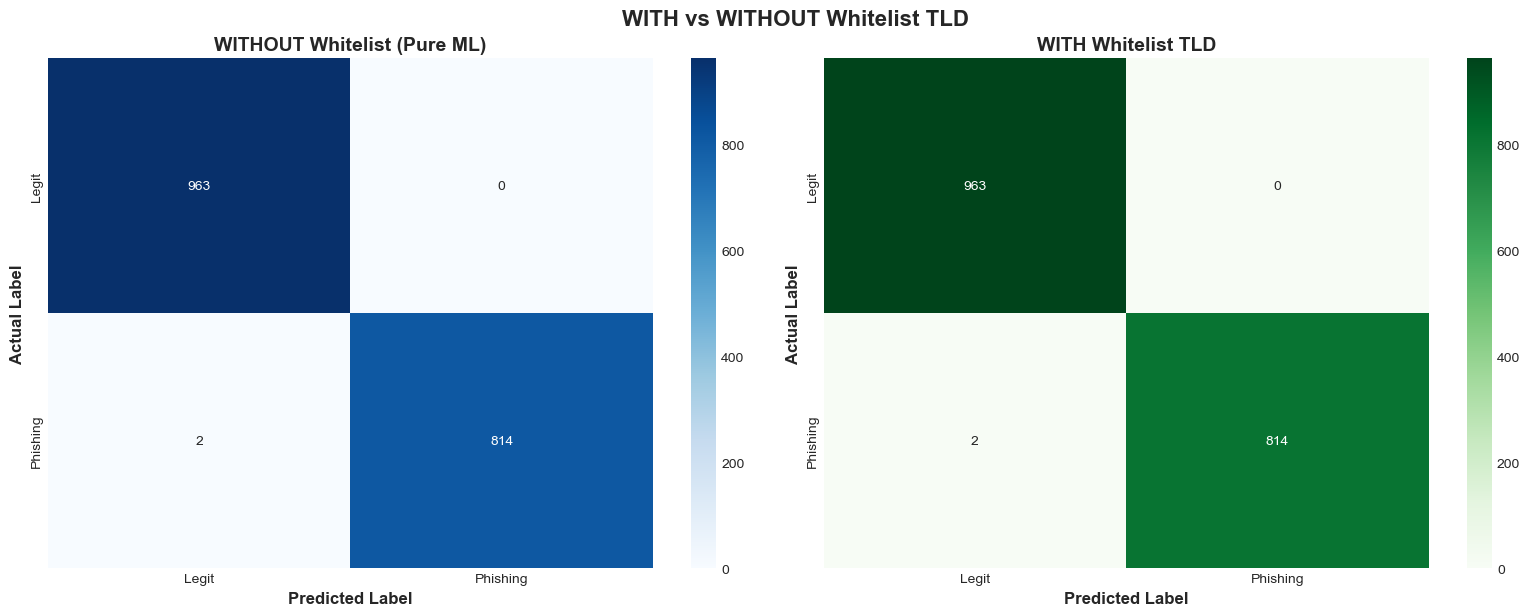

In [127]:
# Side-by-side confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model WITHOUT Whitelist
sns.heatmap(cm_no_filter, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'],
            ax=axes[0])
axes[0].set_title('WITHOUT Whitelist (Pure ML)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Model WITH Whitelist
sns.heatmap(cm_with_filter, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'],
            ax=axes[1])
axes[1].set_title('WITH Whitelist TLD', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('WITH vs WITHOUT Whitelist TLD', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 13. Visualization: Metrics Comparison

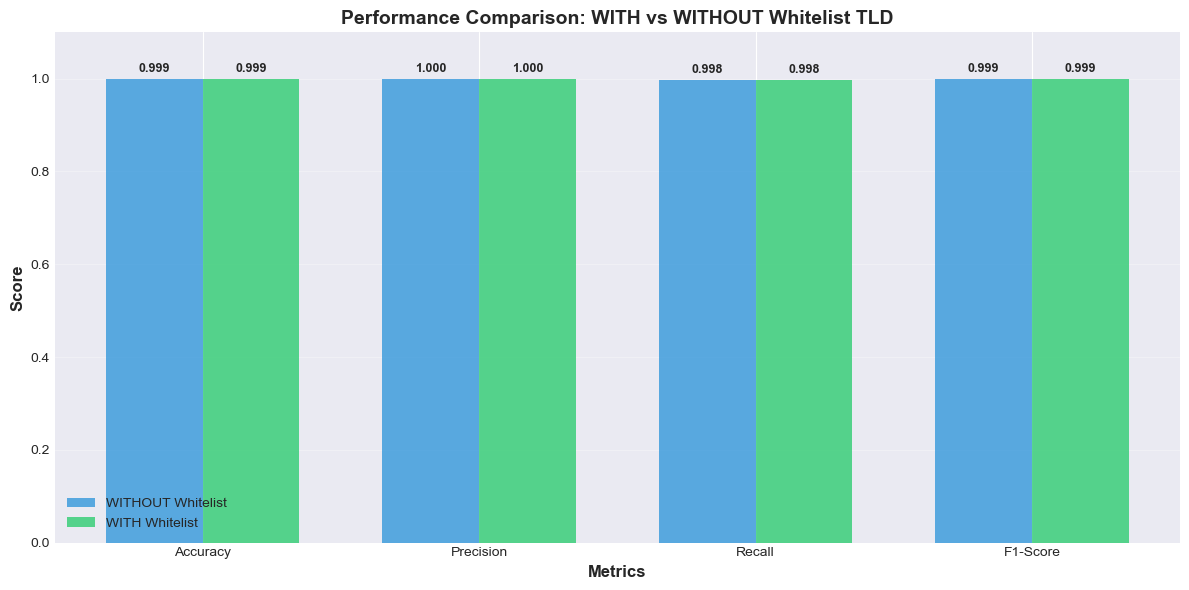

In [128]:
# Metrics comparison bar chart
metrics_data = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'WITHOUT Whitelist': [acc_no_filter, prec_no_filter, rec_no_filter, f1_no_filter],
    'WITH Whitelist': [acc_with_filter, prec_with_filter, rec_with_filter, f1_with_filter]
})

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_data['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_data['WITHOUT Whitelist'], width, 
               label='WITHOUT Whitelist', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, metrics_data['WITH Whitelist'], width,
               label='WITH Whitelist', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: WITH vs WITHOUT Whitelist TLD', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

## 14. Export Results

In [129]:
# Create output directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = f'Comparison_Results/{dataset_name}'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✓ Created directory: {output_dir}")

print("="*80)
print("EXPORTING COMPARISON RESULTS")
print("="*80)

# 1. Export comparison table (CSV)
csv_filename = f'{output_dir}/comparison_metrics_{timestamp}.csv'
comparison_df.to_csv(csv_filename, index=False)
print(f"\n✓ Comparison table saved: {csv_filename}")

# 2. Export detailed JSON
json_filename = f'{output_dir}/comparison_details_{timestamp}.json'
comparison_data = {
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'dataset': dataset_name,
        'total_urls': int(len(df_features_clean)),
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
        'features_used': selected_features,
        'whitelist_tld': indonesian_whitelist_tld,
        'entropy_threshold': float(ENTROPY_THRESHOLD)
    },
    'model_without_whitelist': {
        'approach': 'Pure Machine Learning - No Filtering',
        'metrics': {
            'accuracy': float(acc_no_filter),
            'precision': float(prec_no_filter),
            'recall': float(rec_no_filter),
            'f1_score': float(f1_no_filter)
        },
        'confusion_matrix': {
            'TN': int(cm_no_filter[0][0]),
            'FP': int(cm_no_filter[0][1]),
            'FN': int(cm_no_filter[1][0]),
            'TP': int(cm_no_filter[1][1])
        },
        'classification_strategy': {
            'whitelisted': 0,
            'ml_classified': int(len(y_test))
        }
    },
    'model_with_whitelist': {
        'approach': 'Hybrid - Whitelist TLD + Machine Learning',
        'metrics': {
            'accuracy': float(acc_with_filter),
            'precision': float(prec_with_filter),
            'recall': float(rec_with_filter),
            'f1_score': float(f1_with_filter)
        },
        'confusion_matrix': {
            'TN': int(cm_with_filter[0][0]),
            'FP': int(cm_with_filter[0][1]),
            'FN': int(cm_with_filter[1][0]),
            'TP': int(cm_with_filter[1][1])
        },
        'classification_strategy': {
            'whitelisted': int(whitelisted_in_test),
            'ml_classified': int(ml_classified_in_test)
        }
    },
    'comparison': {
        'accuracy_difference': float(acc_with_filter - acc_no_filter),
        'precision_difference': float(prec_with_filter - prec_no_filter),
        'recall_difference': float(rec_with_filter - rec_no_filter),
        'f1_score_difference': float(f1_with_filter - f1_no_filter),
        'better_model': 'WITH Whitelist' if acc_with_filter > acc_no_filter else 'WITHOUT Whitelist' if acc_no_filter > acc_with_filter else 'Equal'
    }
}

with open(json_filename, 'w', encoding='utf-8') as f:
    json.dump(comparison_data, f, indent=2, ensure_ascii=False)
print(f"✓ Detailed JSON saved: {json_filename}")

# 3. Export Markdown report
md_filename = f'{output_dir}/comparison_report_{timestamp}.md'
md_content = f"""# Model Comparison Report: WITH vs WITHOUT Whitelist TLD

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Dataset**: {dataset_name}  
**Total URLs**: {len(df_features_clean):,}

---

## Executive Summary

This report compares two approaches for phishing URL detection:
1. **WITHOUT Whitelist**: Pure Machine Learning classification
2. **WITH Whitelist**: Hybrid approach using TLD whitelist + ML

### Key Findings

{'✓ Model WITH Whitelist performs BETTER' if acc_with_filter > acc_no_filter else '✓ Model WITHOUT Whitelist performs BETTER' if acc_no_filter > acc_with_filter else '✓ Both models perform EQUALLY'}

- **Accuracy Difference**: {(acc_with_filter - acc_no_filter)*100:+.2f}%
- **Whitelist Auto-Classification**: {whitelisted_in_test:,} URLs ({whitelisted_in_test/len(y_test)*100:.2f}%)

---

## Dataset Information

| Metric | Value |
|--------|-------|
| Total URLs | {len(df_features_clean):,} |
| Training Set | {len(X_train):,} (70%) |
| Test Set | {len(X_test):,} (30%) |
| Features Used | {len(selected_features)} |

### Features Selected (NMI > 0.01):
{chr(10).join([f'- {feat}' for feat in selected_features])}

### Whitelist Configuration:
- **Trusted TLDs**: {', '.join(indonesian_whitelist_tld)}
- **Entropy Threshold**: {ENTROPY_THRESHOLD}

---

## Performance Comparison

### Metrics

| Metric | WITHOUT Whitelist | WITH Whitelist | Difference |
|--------|-------------------|----------------|------------|
| **Accuracy** | {acc_no_filter:.4f} ({acc_no_filter*100:.2f}%) | {acc_with_filter:.4f} ({acc_with_filter*100:.2f}%) | {(acc_with_filter-acc_no_filter)*100:+.2f}% |
| **Precision** | {prec_no_filter:.4f} ({prec_no_filter*100:.2f}%) | {prec_with_filter:.4f} ({prec_with_filter*100:.2f}%) | {(prec_with_filter-prec_no_filter)*100:+.2f}% |
| **Recall** | {rec_no_filter:.4f} ({rec_no_filter*100:.2f}%) | {rec_with_filter:.4f} ({rec_with_filter*100:.2f}%) | {(rec_with_filter-rec_no_filter)*100:+.2f}% |
| **F1-Score** | {f1_no_filter:.4f} ({f1_no_filter*100:.2f}%) | {f1_with_filter:.4f} ({f1_with_filter*100:.2f}%) | {(f1_with_filter-f1_no_filter)*100:+.2f}% |

### Confusion Matrix

#### Model WITHOUT Whitelist (Pure ML)

|  | Predicted Legit | Predicted Phishing |
|---|---|---|
| **Actual Legit** | {cm_no_filter[0][0]:,} (TN) | {cm_no_filter[0][1]:,} (FP) |
| **Actual Phishing** | {cm_no_filter[1][0]:,} (FN) | {cm_no_filter[1][1]:,} (TP) |

#### Model WITH Whitelist TLD

|  | Predicted Legit | Predicted Phishing |
|---|---|---|
| **Actual Legit** | {cm_with_filter[0][0]:,} (TN) | {cm_with_filter[0][1]:,} (FP) |
| **Actual Phishing** | {cm_with_filter[1][0]:,} (FN) | {cm_with_filter[1][1]:,} (TP) |

#### Difference (WITH - WITHOUT)

|  | Predicted Legit | Predicted Phishing |
|---|---|---|
| **Actual Legit** | {cm_with_filter[0][0] - cm_no_filter[0][0]:+,} (∆TN) | {cm_with_filter[0][1] - cm_no_filter[0][1]:+,} (∆FP) |
| **Actual Phishing** | {cm_with_filter[1][0] - cm_no_filter[1][0]:+,} (∆FN) | {cm_with_filter[1][1] - cm_no_filter[1][1]:+,} (∆TP) |

---

## Classification Strategy

### Model WITHOUT Whitelist
- All {len(y_test):,} URLs classified by Machine Learning
- No filtering applied

### Model WITH Whitelist
- Whitelisted (Auto-Legit): {whitelisted_in_test:,} URLs ({whitelisted_in_test/len(y_test)*100:.2f}%)
- ML Classified: {ml_classified_in_test:,} URLs ({ml_classified_in_test/len(y_test)*100:.2f}%)

---

## Analysis

### Impact of Whitelist Filtering

**True Negatives (TN)**: {cm_with_filter[0][0] - cm_no_filter[0][0]:+,}
- {'Whitelist improved TN detection' if cm_with_filter[0][0] > cm_no_filter[0][0] else 'No improvement in TN' if cm_with_filter[0][0] == cm_no_filter[0][0] else 'Whitelist reduced TN'}

**False Positives (FP)**: {cm_with_filter[0][1] - cm_no_filter[0][1]:+,}
- {'Whitelist reduced false alarms' if cm_with_filter[0][1] < cm_no_filter[0][1] else 'No change in FP' if cm_with_filter[0][1] == cm_no_filter[0][1] else 'Whitelist increased FP'}

**False Negatives (FN)**: {cm_with_filter[1][0] - cm_no_filter[1][0]:+,}
- {'⚠️ Whitelist may have missed some phishing URLs' if cm_with_filter[1][0] > cm_no_filter[1][0] else 'No change in FN' if cm_with_filter[1][0] == cm_no_filter[1][0] else 'Whitelist improved FN detection'}

---

## Conclusion

{'The WITH Whitelist approach provides better overall performance, successfully leveraging trusted TLD patterns to improve classification accuracy.' if acc_with_filter > acc_no_filter else 'The pure Machine Learning approach (WITHOUT Whitelist) performs better, suggesting that rule-based filtering may introduce bias.' if acc_no_filter > acc_with_filter else 'Both approaches achieve identical performance on this dataset.'}

### Recommendations:

{'- ✓ Use WITH Whitelist for production deployment' if acc_with_filter > acc_no_filter else '- ✓ Use WITHOUT Whitelist for production deployment' if acc_no_filter > acc_with_filter else '- Consider other factors (speed, interpretability) for model selection'}
- Monitor false negative rate to ensure phishing detection
- Regularly update whitelist TLD list
- Consider ensemble approach for critical applications

---

**Report Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Tool**: Model Comparison Framework v1.0
"""

with open(md_filename, 'w', encoding='utf-8') as f:
    f.write(md_content)
print(f"✓ Markdown report saved: {md_filename}")

print("\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)
print(f"Output Directory: {os.path.abspath(output_dir)}")
print(f"\nFiles created:")
print(f"  1. {os.path.basename(csv_filename)} - Comparison table (CSV)")
print(f"  2. {os.path.basename(json_filename)} - Detailed results (JSON)")
print(f"  3. {os.path.basename(md_filename)} - Full report (Markdown)")
print(f"\n✓ All results exported successfully!")

EXPORTING COMPARISON RESULTS

✓ Comparison table saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/comparison_metrics_20260403_204051.csv
✓ Detailed JSON saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/comparison_details_20260403_204051.json
✓ Markdown report saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/comparison_report_20260403_204051.md

EXPORT SUMMARY
Output Directory: d:\Tugas\KULIAH\!TA\Comparation\Comparison_Results\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

Files created:
  1. comparison_metrics_20260403_204051.csv - Comparison table (CSV)
  2. comparison_details_20260403_204051.json - Detailed results (JSON)
  3. comparison_report_20260403_204051.md - Full report (Markdown)

✓ All results exported successfully!


## 15. Final Summary

In [130]:
print("="*80)
print("FINAL SUMMARY: MODEL COMPARISON")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   Name: {dataset_name}")
print(f"   Total URLs: {len(df_features_clean):,}")
print(f"   Train/Test: {len(X_train):,} / {len(X_test):,}")

print(f"\n🔍 Feature Selection:")
print(f"   Method: Normalized Mutual Information (NMI)")
print(f"   Threshold: > 0.01")
print(f"   Selected Features: {len(selected_features)}")

print(f"\n🤖 Models Evaluated:")
print(f"\n   [1] WITHOUT Whitelist (Pure ML):")
print(f"       - Accuracy: {acc_no_filter:.4f} ({acc_no_filter*100:.2f}%)")
print(f"       - F1-Score: {f1_no_filter:.4f} ({f1_no_filter*100:.2f}%)")
print(f"       - Strategy: All URLs classified by ML")

print(f"\n   [2] WITH Whitelist TLD:")
print(f"       - Accuracy: {acc_with_filter:.4f} ({acc_with_filter*100:.2f}%)")
print(f"       - F1-Score: {f1_with_filter:.4f} ({f1_with_filter*100:.2f}%)")
print(f"       - Strategy: {whitelisted_in_test:,} whitelisted + {ml_classified_in_test:,} ML")

print(f"\n🏆 Winner:")
if acc_with_filter > acc_no_filter:
    print(f"   WITH Whitelist TLD (+{(acc_with_filter-acc_no_filter)*100:.2f}% accuracy)")
elif acc_no_filter > acc_with_filter:
    print(f"   WITHOUT Whitelist (+{(acc_no_filter-acc_with_filter)*100:.2f}% accuracy)")
else:
    print(f"   TIED - Both models have equal performance")

print(f"\n📁 Results exported to: {output_dir}")
print(f"\n" + "="*80)
print("✓ Comparison completed successfully!")
print("="*80)

FINAL SUMMARY: MODEL COMPARISON

📊 Dataset:
   Name: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
   Total URLs: 5,927
   Train/Test: 4,148 / 1,779

🔍 Feature Selection:
   Method: Normalized Mutual Information (NMI)
   Threshold: > 0.01
   Selected Features: 10

🤖 Models Evaluated:

   [1] WITHOUT Whitelist (Pure ML):
       - Accuracy: 0.9989 (99.89%)
       - F1-Score: 0.9988 (99.88%)
       - Strategy: All URLs classified by ML

   [2] WITH Whitelist TLD:
       - Accuracy: 0.9989 (99.89%)
       - F1-Score: 0.9988 (99.88%)
       - Strategy: 422 whitelisted + 1,357 ML

🏆 Winner:
   TIED - Both models have equal performance

📁 Results exported to: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

✓ Comparison completed successfully!


## 16. Comprehensive Evaluation Report

**Tujuan**: Evaluasi mendalam dengan statistical analysis untuk validasi hasil NMI filtering

**Metodologi**:
- 5-Fold Stratified Cross-Validation
- Logistic Regression dengan StandardScaler
- Paired t-test untuk statistical significance
- Cohen's d untuk effect size analysis

### 16.1. Import Additional Libraries for Statistical Analysis

In [131]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats

print("="*80)
print("COMPREHENSIVE EVALUATION REPORT - SETUP")
print("="*80)
print("✓ Additional libraries imported for statistical analysis")
print("  - StratifiedKFold for cross-validation")
print("  - StandardScaler for feature normalization")
print("  - scipy.stats for statistical tests")

COMPREHENSIVE EVALUATION REPORT - SETUP
✓ Additional libraries imported for statistical analysis
  - StratifiedKFold for cross-validation
  - StandardScaler for feature normalization
  - scipy.stats for statistical tests


### 16.2. Helper Functions for Statistical Analysis

In [132]:
def calculate_cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size
    
    Parameters:
    - group1: First group values (e.g., phishing)
    - group2: Second group values (e.g., legitimate)
    
    Returns:
    - Cohen's d value (positive = group1 > group2)
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

def perform_cross_validation(X, y, feature_list, scaler=True):
    """
    Perform 5-fold stratified cross-validation with Logistic Regression
    
    Parameters:
    - X: Feature DataFrame
    - y: Target labels
    - feature_list: List of features to use
    - scaler: Whether to use StandardScaler (default: True)
    
    Returns:
    - Dictionary with mean±std for each metric
    """
    if scaler:
        pipeline_steps = [
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        ]
        model = Pipeline(pipeline_steps)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(
        model, X[feature_list], y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    return {
        'accuracy': (cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()),
        'precision': (cv_results['test_precision'].mean(), cv_results['test_precision'].std()),
        'recall': (cv_results['test_recall'].mean(), cv_results['test_recall'].std()),
        'f1': (cv_results['test_f1'].mean(), cv_results['test_f1'].std()),
        'auc': (cv_results['test_roc_auc'].mean(), cv_results['test_roc_auc'].std()),
        'raw_scores': cv_results
    }

print("="*80)
print("HELPER FUNCTIONS DEFINED")
print("="*80)
print("✓ calculate_cohens_d() - Effect size calculation")
print("✓ perform_cross_validation() - 5-fold stratified CV with Logistic Regression")

HELPER FUNCTIONS DEFINED
✓ calculate_cohens_d() - Effect size calculation
✓ perform_cross_validation() - 5-fold stratified CV with Logistic Regression


### 16.3. Dataset Evaluation Function

In [133]:
def evaluate_dataset(df_data, dataset_name_param, features_list, selected_features_list):
    """
    Comprehensive evaluation for a single dataset
    
    Parameters:
    - df_data: DataFrame with features and labels
    - dataset_name_param: Name of the dataset
    - features_list: All numeric features (before filtering)
    - selected_features_list: Features after NMI filtering
    """
    
    print("\n" + "="*80)
    print(f"EVALUATING DATASET: {dataset_name_param}")
    print("="*80)
    
    # Prepare data
    y_data = df_data['LabelNumeric']
    phishing_mask = y_data == 1
    legit_mask = y_data == 0
    
    # ===== 1. BASIC DATASET STATISTICS =====
    print("\n[1] BASIC DATASET STATISTICS")
    print("-" * 80)
    
    total_samples = len(df_data)
    n_phishing = phishing_mask.sum()
    n_legit = legit_mask.sum()
    imbalance_ratio = n_phishing / n_legit if n_legit > 0 else 0
    
    # Calculate H(Y)
    y_probs = y_data.value_counts(normalize=True).values
    H_y = entropy(y_probs, base=2)
    
    print(f"Total Samples: {total_samples:,}")
    print(f"Phishing Samples: {n_phishing:,} ({n_phishing/total_samples*100:.2f}%)")
    print(f"Legitimate Samples: {n_legit:,} ({n_legit/total_samples*100:.2f}%)")
    print(f"Class Imbalance Ratio (P/L): {imbalance_ratio:.4f}")
    print(f"Label Entropy H(Y): {H_y:.4f} bits")
    
    # ===== 2. FEATURE SELECTION STATISTICS =====
    print("\n[2] FEATURE SELECTION STATISTICS")
    print("-" * 80)
    
    n_features_before = len(features_list)
    n_features_after = len(selected_features_list)
    reduction_pct = (1 - n_features_after/n_features_before) * 100
    
    print(f"Features Before NMI Filtering: {n_features_before}")
    print(f"Features After NMI Filtering: {n_features_after}")
    print(f"Dimensionality Reduction: {reduction_pct:.2f}%")
    
    # Get NMI scores for selected features
    selected_nmi_scores = mi_df[mi_df['Feature'].isin(selected_features_list)]['NMI_Score'].values
    
    if len(selected_nmi_scores) > 0:
        print(f"Mean NMI Score: {selected_nmi_scores.mean():.4f}")
        print(f"Median NMI Score: {np.median(selected_nmi_scores):.4f}")
        print(f"Std Dev NMI: {selected_nmi_scores.std():.4f}")
    
    print(f"\nTop 5 Features by NMI Score:")
    top_5_features = mi_df.head(5)
    for idx, (i, row) in enumerate(top_5_features.iterrows(), 1):
        print(f"  {idx}. {row['Feature']:30s} - NMI: {row['NMI_Score']:.4f}")
    
    # ===== 3. EFFECT SIZE ANALYSIS (Cohen's d) =====
    print("\n[3] EFFECT SIZE ANALYSIS (Top 3 Features)")
    print("-" * 80)
    
    top_3_features = mi_df.head(3)['Feature'].tolist()
    cohens_d_results = []
    
    for feat in top_3_features:
        phishing_values = df_data.loc[phishing_mask, feat].values
        legit_values = df_data.loc[legit_mask, feat].values
        
        cohens_d = calculate_cohens_d(phishing_values, legit_values)
        effect_size_label = 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'
        cohens_d_results.append({
            'Feature': feat,
            'Cohens_d': cohens_d,
            'Effect_Size': effect_size_label
        })
        
        print(f"{feat:30s} - Cohen's d: {cohens_d:+.4f} ({effect_size_label})")
    
    # ===== 4. LOGISTIC REGRESSION PERFORMANCE =====
    print("\n[4] LOGISTIC REGRESSION PERFORMANCE (5-Fold Stratified CV)")
    print("-" * 80)
    
    # WITHOUT NMI Filtering (all features)
    print("\n[a] WITHOUT NMI Filtering (All Features):")
    results_without = perform_cross_validation(df_data, y_data, features_list, scaler=True)
    
    print(f"  Accuracy : {results_without['accuracy'][0]:.4f} ± {results_without['accuracy'][1]:.4f}")
    print(f"  Precision: {results_without['precision'][0]:.4f} ± {results_without['precision'][1]:.4f}")
    print(f"  Recall   : {results_without['recall'][0]:.4f} ± {results_without['recall'][1]:.4f}")
    print(f"  F1-Score : {results_without['f1'][0]:.4f} ± {results_without['f1'][1]:.4f}")
    print(f"  AUC      : {results_without['auc'][0]:.4f} ± {results_without['auc'][1]:.4f}")
    
    # WITH NMI Filtering
    print("\n[b] WITH NMI Filtering (Selected Features):")
    results_with = perform_cross_validation(df_data, y_data, selected_features_list, scaler=True)
    
    print(f"  Accuracy : {results_with['accuracy'][0]:.4f} ± {results_with['accuracy'][1]:.4f}")
    print(f"  Precision: {results_with['precision'][0]:.4f} ± {results_with['precision'][1]:.4f}")
    print(f"  Recall   : {results_with['recall'][0]:.4f} ± {results_with['recall'][1]:.4f}")
    print(f"  F1-Score : {results_with['f1'][0]:.4f} ± {results_with['f1'][1]:.4f}")
    print(f"  AUC      : {results_with['auc'][0]:.4f} ± {results_with['auc'][1]:.4f}")
    
    # ===== 5. PAIRED T-TEST =====
    print("\n[5] STATISTICAL SIGNIFICANCE TEST (Paired t-test)")
    print("-" * 80)
    
    f1_without = results_without['raw_scores']['test_f1']
    f1_with = results_with['raw_scores']['test_f1']
    
    t_stat, p_value = stats.ttest_rel(f1_with, f1_without)
    
    print(f"Comparing F1-Score: WITH vs WITHOUT NMI Filtering")
    print(f"  Mean F1 WITHOUT: {f1_without.mean():.4f}")
    print(f"  Mean F1 WITH   : {f1_with.mean():.4f}")
    print(f"  Difference     : {(f1_with.mean() - f1_without.mean()):.4f} ({(f1_with.mean() - f1_without.mean())*100:+.2f}%)")
    print(f"  t-statistic    : {t_stat:.4f}")
    print(f"  p-value        : {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  ✓ STATISTICALLY SIGNIFICANT (α=0.05)")
        if f1_with.mean() > f1_without.mean():
            print(f"  → NMI filtering IMPROVES performance")
        else:
            print(f"  → NMI filtering REDUCES performance")
    else:
        print(f"  ✗ NOT statistically significant (α=0.05)")
        print(f"  → No significant difference between WITH and WITHOUT filtering")
    
    # ===== KEY METRICS SUMMARY =====
    print("\n" + "="*80)
    print("KEY METRICS SUMMARY")
    print("="*80)
    print(f"\n📊 Dataset: {dataset_name_param}")
    print(f"\n🎯 Performance Metrics (WITH NMI Filtering):")
    print(f"   F1 mean ± std      : {results_with['f1'][0]:.4f} ± {results_with['f1'][1]:.4f}")
    print(f"   AUC mean ± std     : {results_with['auc'][0]:.4f} ± {results_with['auc'][1]:.4f}")
    print(f"\n🔍 Feature Selection:")
    print(f"   Mean NMI           : {selected_nmi_scores.mean():.4f}" if len(selected_nmi_scores) > 0 else "   Mean NMI           : 0.0000")
    print(f"   Jumlah fitur sebelum : {n_features_before}")
    print(f"   Jumlah fitur sesudah : {n_features_after} (Top-{n_features_after})")
    print(f"   Reduction          : {reduction_pct:.2f}%")
    print("\n" + "="*80)
    
    # ===== RETURN SUMMARY =====
    summary = {
        'Dataset': dataset_name_param,
        'Total_Samples': total_samples,
        'Phishing': n_phishing,
        'Legitimate': n_legit,
        'Imbalance_Ratio': imbalance_ratio,
        'H_Y': H_y,
        'Features_Before': n_features_before,
        'Features_After': n_features_after,
        'Reduction_%': reduction_pct,
        'Mean_NMI': selected_nmi_scores.mean() if len(selected_nmi_scores) > 0 else 0,
        'WITHOUT_Accuracy': results_without['accuracy'][0],
        'WITHOUT_Accuracy_Std': results_without['accuracy'][1],
        'WITHOUT_Precision': results_without['precision'][0],
        'WITHOUT_Precision_Std': results_without['precision'][1],
        'WITHOUT_Recall': results_without['recall'][0],
        'WITHOUT_Recall_Std': results_without['recall'][1],
        'WITHOUT_F1': results_without['f1'][0],
        'WITHOUT_F1_Std': results_without['f1'][1],
        'WITHOUT_AUC': results_without['auc'][0],
        'WITHOUT_AUC_Std': results_without['auc'][1],
        'WITH_Accuracy': results_with['accuracy'][0],
        'WITH_Accuracy_Std': results_with['accuracy'][1],
        'WITH_Precision': results_with['precision'][0],
        'WITH_Precision_Std': results_with['precision'][1],
        'WITH_Recall': results_with['recall'][0],
        'WITH_Recall_Std': results_with['recall'][1],
        'WITH_F1': results_with['f1'][0],
        'WITH_F1_Std': results_with['f1'][1],
        'WITH_AUC': results_with['auc'][0],
        'WITH_AUC_Std': results_with['auc'][1],
        'F1_Improvement': f1_with.mean() - f1_without.mean(),
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No',
        'Cohens_d_Top3': cohens_d_results
    }
    
    return summary

print("✓ evaluate_dataset() function defined")

✓ evaluate_dataset() function defined


### 16.4. Run Evaluation on Current Dataset

In [134]:
print("\n" + "="*80)
print("RUNNING COMPREHENSIVE EVALUATION")
print("="*80)

# Evaluate current dataset
summary_current = evaluate_dataset(
    df_data=df_features_clean,
    dataset_name_param=dataset_name,
    features_list=numeric_features,
    selected_features_list=selected_features
)

print("\n" + "="*80)
print("✓ EVALUATION COMPLETED FOR CURRENT DATASET")
print("="*80)


RUNNING COMPREHENSIVE EVALUATION

EVALUATING DATASET: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

[1] BASIC DATASET STATISTICS
--------------------------------------------------------------------------------
Total Samples: 5,927
Phishing Samples: 2,718 (45.86%)
Legitimate Samples: 3,209 (54.14%)
Class Imbalance Ratio (P/L): 0.8470
Label Entropy H(Y): 0.9950 bits

[2] FEATURE SELECTION STATISTICS
--------------------------------------------------------------------------------
Features Before NMI Filtering: 50
Features After NMI Filtering: 10
Dimensionality Reduction: 80.00%
Mean NMI Score: 0.2317
Median NMI Score: 0.1448
Std Dev NMI: 0.2038

Top 5 Features by NMI Score:
  1. SlashCountPath                 - NMI: 0.5458
  2. SlashCountURL                  - NMI: 0.5441
  3. PathLength                     - NMI: 0.5068
  4. Entropy                        - NMI: 0.1951
  5. UrlLength                      - NMI: 0.1643

[3] EFFECT SIZE ANALYSIS (Top 3 Features)
-----------------------

### 16.5. Create Summary Tables

In [135]:
print("\n" + "="*80)
print("KEY METRICS SUMMARY")
print("="*80)
print(f"\n📊 Dataset: {summary_current['Dataset']}")
print(f"\n🎯 Performance Metrics (WITH NMI Filtering):")
print(f"   F1 mean ± std      : {summary_current['WITH_F1']:.4f} ± {summary_current['WITH_F1_Std']:.4f}")
print(f"   AUC mean ± std     : {summary_current['WITH_AUC']:.4f} ± {summary_current['WITH_AUC_Std']:.4f}")
print(f"\n🔍 Feature Selection:")
print(f"   Mean NMI           : {summary_current['Mean_NMI']:.4f}")
print(f"   Jumlah fitur sebelum : {summary_current['Features_Before']}")
print(f"   Jumlah fitur sesudah : {summary_current['Features_After']} (Top-{summary_current['Features_After']})")
print(f"   Reduction          : {summary_current['Reduction_%']:.2f}%")

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

# Create summary DataFrame (expandable for multiple datasets)
summary_df = pd.DataFrame([{
    'Dataset': summary_current['Dataset'],
    'Samples': f"{summary_current['Total_Samples']:,}",
    'P/L Ratio': f"{summary_current['Imbalance_Ratio']:.3f}",
    'H(Y)': f"{summary_current['H_Y']:.4f}",
    'Features': f"{summary_current['Features_After']}/{summary_current['Features_Before']}",
    'Reduction': f"{summary_current['Reduction_%']:.1f}%",
    'Mean NMI': f"{summary_current['Mean_NMI']:.4f}",
    'F1 (Before)': f"{summary_current['WITHOUT_F1']:.4f}",
    'F1 (After)': f"{summary_current['WITH_F1']:.4f}",
    'ΔF1': f"{summary_current['F1_Improvement']:+.4f}",
    'p-value': f"{summary_current['P_Value']:.4f}",
    'Significant?': summary_current['Significant']
}])

print("\n" + summary_df.to_string(index=False))

# Detailed metrics table
detailed_metrics = pd.DataFrame([{
    'Metric': metric,
    'WITHOUT (mean)': f"{summary_current[f'WITHOUT_{metric}']:.4f}",
    'WITH (mean)': f"{summary_current[f'WITH_{metric}']:.4f}",
    'Improvement': f"{(summary_current[f'WITH_{metric}'] - summary_current[f'WITHOUT_{metric}'])*100:+.2f}%"
} for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']])

print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)
print("\n" + detailed_metrics.to_string(index=False))

# Cohen's d table
cohens_d_df = pd.DataFrame(summary_current['Cohens_d_Top3'])
print("\n" + "="*80)
print("EFFECT SIZE ANALYSIS (Cohen's d)")
print("="*80)
print("\n" + cohens_d_df.to_string(index=False))


KEY METRICS SUMMARY

📊 Dataset: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

🎯 Performance Metrics (WITH NMI Filtering):
   F1 mean ± std      : 0.9972 ± 0.0017
   AUC mean ± std     : 0.9993 ± 0.0007

🔍 Feature Selection:
   Mean NMI           : 0.2317
   Jumlah fitur sebelum : 50
   Jumlah fitur sesudah : 10 (Top-10)
   Reduction          : 80.00%

SUMMARY TABLE

                                        Dataset Samples P/L Ratio   H(Y) Features Reduction Mean NMI F1 (Before) F1 (After)     ΔF1 p-value Significant?
Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14   5,927     0.847 0.9950    10/50     80.0%   0.2317      0.9972     0.9972 +0.0000     nan           No

DETAILED PERFORMANCE METRICS

   Metric WITHOUT (mean) WITH (mean) Improvement
 Accuracy         0.9975      0.9975      +0.00%
Precision         1.0000      1.0000      +0.00%
   Recall         0.9945      0.9945      +0.00%
       F1         0.9972      0.9972      +0.00%
      AUC         0.9993      0.9993      +0.

### 16.6. Export Comprehensive Report

In [136]:
# Export comprehensive report
timestamp_report = datetime.now().strftime('%Y%m%d_%H%M%S')
report_dir = f'Comparison_Results/{dataset_name}/Comprehensive_Report'

if not os.path.exists(report_dir):
    os.makedirs(report_dir)
    print(f"\n✓ Created directory: {report_dir}")

print("\n" + "="*80)
print("EXPORTING COMPREHENSIVE REPORT")
print("="*80)

# 1. Export summary CSV
summary_csv = f'{report_dir}/evaluation_summary_{timestamp_report}.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"✓ Summary CSV: {summary_csv}")

# 2. Export detailed metrics CSV
metrics_csv = f'{report_dir}/detailed_metrics_{timestamp_report}.csv'
detailed_metrics.to_csv(metrics_csv, index=False)
print(f"✓ Metrics CSV: {metrics_csv}")

# 3. Export Cohen's d CSV
cohens_csv = f'{report_dir}/cohens_d_analysis_{timestamp_report}.csv'
cohens_d_df.to_csv(cohens_csv, index=False)
print(f"✓ Cohen's d CSV: {cohens_csv}")

# 4. Export JSON report
json_report = f'{report_dir}/comprehensive_report_{timestamp_report}.json'
report_data = {
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'dataset': summary_current['Dataset'],
        'evaluation_method': '5-Fold Stratified Cross-Validation',
        'model': 'Logistic Regression with StandardScaler',
        'random_state': 42
    },
    'dataset_statistics': {
        'total_samples': int(summary_current['Total_Samples']),
        'phishing': int(summary_current['Phishing']),
        'legitimate': int(summary_current['Legitimate']),
        'imbalance_ratio': float(summary_current['Imbalance_Ratio']),
        'label_entropy': float(summary_current['H_Y'])
    },
    'feature_selection': {
        'method': 'Normalized Mutual Information (NMI)',
        'threshold': 0.01,
        'features_before': int(summary_current['Features_Before']),
        'features_after': int(summary_current['Features_After']),
        'reduction_percentage': float(summary_current['Reduction_%']),
        'mean_nmi_score': float(summary_current['Mean_NMI']),
        'selected_features': selected_features
    },
    'performance_without_filtering': {
        'accuracy': float(summary_current['WITHOUT_Accuracy']),
        'precision': float(summary_current['WITHOUT_Precision']),
        'recall': float(summary_current['WITHOUT_Recall']),
        'f1_score': float(summary_current['WITHOUT_F1']),
        'auc': float(summary_current['WITHOUT_AUC'])
    },
    'performance_with_filtering': {
        'accuracy': float(summary_current['WITH_Accuracy']),
        'precision': float(summary_current['WITH_Precision']),
        'recall': float(summary_current['WITH_Recall']),
        'f1_score': float(summary_current['WITH_F1']),
        'auc': float(summary_current['WITH_AUC'])
    },
    'statistical_analysis': {
        'f1_improvement': float(summary_current['F1_Improvement']),
        'p_value': float(summary_current['P_Value']),
        'statistically_significant': summary_current['Significant'],
        'alpha': 0.05,
        'cohens_d_top3_features': summary_current['Cohens_d_Top3']
    }
}

with open(json_report, 'w', encoding='utf-8') as f:
    json.dump(report_data, f, indent=2, ensure_ascii=False)
print(f"✓ JSON Report: {json_report}")

print("\n✓ Comprehensive report exported successfully!")
print(f"✓ Location: {os.path.abspath(report_dir)}")

print("\n" + "="*80)
print("📊 COMPREHENSIVE EVALUATION REPORT COMPLETED")
print("="*80)
print(f"\n✓ Total exported files: 4 (3 CSV + 1 JSON)")
print(f"✓ All results available at: {report_dir}")
print(f"\n⚠️  Note: Rumus NMI tetap menggunakan binned data (TIDAK DIUBAH)")
print(f"   - MI calculated from X_binned with discrete_features=True")
print(f"   - NMI = 2*MI / (H(X) + H(Y)) from same binned data")


EXPORTING COMPREHENSIVE REPORT
✓ Summary CSV: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_Report/evaluation_summary_20260403_204056.csv
✓ Metrics CSV: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_Report/detailed_metrics_20260403_204056.csv
✓ Cohen's d CSV: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_Report/cohens_d_analysis_20260403_204056.csv
✓ JSON Report: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_Report/comprehensive_report_20260403_204056.json

✓ Comprehensive report exported successfully!
✓ Location: d:\Tugas\KULIAH\!TA\Comparation\Comparison_Results\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14\Comprehensive_Report

📊 COMPREHENSIVE EVALUATION REPORT COMPLETED

✓ Total exported files: 4 (3 CSV + 1 JSON)
✓ All results available at: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Comprehensive_Report

⚠️  Note: Rum

## 17. Clean Pipeline: 4-Scenario Comparison (5-Fold CV)

**Scenarios:**
1. Baseline: No feature selection, no whitelist
2. MI-Based: Feature selection with Mutual Information
3. NMI-Based: Feature selection with Normalized MI
4. NMI + Whitelist: NMI features + TLD whitelist filtering (Entropy < 3.5)

### 17.1. Helper Functions

In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ttest_rel
import logging

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

def select_features_mi(X_train, y_train, top_k=15, random_state=42):
    """Select top-K features using Mutual Information"""
    discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    X_binned = discretizer.fit_transform(X_train)
    
    mi_scores = mutual_info_classif(X_binned, y_train, discrete_features=True, random_state=random_state)
    
    feature_scores = pd.DataFrame({
        'Feature': X_train.columns,
        'MI_Score': mi_scores
    }).sort_values('MI_Score', ascending=False)
    
    return feature_scores.head(top_k)['Feature'].tolist(), mi_scores


def select_features_nmi(X_train, y_train, top_k=15, random_state=42):
    """Select top-K features using Normalized Mutual Information"""
    discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    X_binned = discretizer.fit_transform(X_train)
    
    mi_scores = mutual_info_classif(X_binned, y_train, discrete_features=True, random_state=random_state)
    
    # Calculate H(Y)
    y_probs = y_train.value_counts(normalize=True).values
    H_y = entropy(y_probs, base=2)
    
    # Calculate H(X) for each feature
    H_x = np.array([entropy(pd.Series(X_binned[:, i]).value_counts(normalize=True).values, base=2) 
                    for i in range(X_binned.shape[1])])
    
    # Calculate NMI
    nmi_scores = np.where(H_x + H_y > 0, (2 * mi_scores) / (H_x + H_y), 0)
    
    feature_scores = pd.DataFrame({
        'Feature': X_train.columns,
        'NMI_Score': nmi_scores
    }).sort_values('NMI_Score', ascending=False)
    
    return feature_scores.head(top_k)['Feature'].tolist(), nmi_scores


def apply_whitelist_filtering(X_test_df, whitelisted_tlds, tld_column='TLD', entropy_threshold=3.5):
    """
    Whitelist filtering: TLD in whitelist AND Entropy < threshold
    Prevents phishing sites with legitimate TLD but high entropy
    """
    whitelist_mask = (X_test_df[tld_column].isin(whitelisted_tlds) & 
                      (X_test_df['Entropy'] < entropy_threshold))
    
    tld_only = X_test_df[tld_column].isin(whitelisted_tlds).sum()
    entropy_only = (X_test_df['Entropy'] < entropy_threshold).sum()
    both = whitelist_mask.sum()
    
    logger.info(f"      Whitelist → TLD: {tld_only} | Entropy<{entropy_threshold}: {entropy_only} | Both: {both} ({both/len(X_test_df)*100:.1f}%)")
    return whitelist_mask


print("✓ Helper functions loaded")

✓ Helper functions loaded


### 17.2. Main Pipeline Function

In [138]:
def run_clean_pipeline_comparison(df_data, numeric_features, whitelisted_tlds, 
                                  top_k=15, n_folds=5, random_state=42):
    """Run 5-fold CV comparison: Baseline | MI-Based | NMI-Based | NMI+Whitelist"""
    
    logger.info("\n" + "="*80)
    logger.info(f"4-SCENARIO COMPARISON | Data: {len(df_data):,} | Features: {len(numeric_features)} | Top-K: {top_k} | CV: {n_folds}-Fold")
    logger.info("="*80)
    
    X, y, X_full = df_data[numeric_features], df_data['LabelNumeric'], df_data
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    results = {name: {'fold_results': [], 'predictions': [], 'y_true': []} 
               for name in ['Baseline', 'MI-Based', 'NMI-Based', 'NMI+Whitelist']}
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        logger.info(f"\nFold {fold_idx}/{n_folds} | Train: {len(train_idx):,} | Test: {len(test_idx):,}")
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        X_full_test = X_full.iloc[test_idx]
        
        # [1] Baseline
        logger.info("  [1] Baseline")
        model = LogisticRegression(solver='liblinear', penalty='l2', random_state=random_state, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred, y_proba = model.predict(X_test), model.predict_proba(X_test)[:, 1]
        results['Baseline']['fold_results'].append({
            'fold': fold_idx, 'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba)
        })
        results['Baseline']['predictions'].extend(y_pred)
        results['Baseline']['y_true'].extend(y_test)
        logger.info(f"      F1: {results['Baseline']['fold_results'][-1]['f1']:.4f}")
        
        # [2] MI-Based
        logger.info("  [2] MI-Based")
        sel_mi, _ = select_features_mi(X_train, y_train, top_k, random_state)
        model = LogisticRegression(solver='liblinear', penalty='l2', random_state=random_state, max_iter=1000)
        model.fit(X_train[sel_mi], y_train)
        y_pred, y_proba = model.predict(X_test[sel_mi]), model.predict_proba(X_test[sel_mi])[:, 1]
        results['MI-Based']['fold_results'].append({
            'fold': fold_idx, 'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba)
        })
        results['MI-Based']['predictions'].extend(y_pred)
        results['MI-Based']['y_true'].extend(y_test)
        logger.info(f"      F1: {results['MI-Based']['fold_results'][-1]['f1']:.4f}")
        
        # [3] NMI-Based
        logger.info("  [3] NMI-Based")
        sel_nmi, _ = select_features_nmi(X_train, y_train, top_k, random_state)
        model = LogisticRegression(solver='liblinear', penalty='l2', random_state=random_state, max_iter=1000)
        model.fit(X_train[sel_nmi], y_train)
        y_pred, y_proba = model.predict(X_test[sel_nmi]), model.predict_proba(X_test[sel_nmi])[:, 1]
        results['NMI-Based']['fold_results'].append({
            'fold': fold_idx, 'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba)
        })
        results['NMI-Based']['predictions'].extend(y_pred)
        results['NMI-Based']['y_true'].extend(y_test)
        logger.info(f"      F1: {results['NMI-Based']['fold_results'][-1]['f1']:.4f}")
        
        # [4] NMI + Whitelist
        logger.info("  [4] NMI + Whitelist")
        whitelist_mask = apply_whitelist_filtering(X_full_test, whitelisted_tlds)
        y_pred_final, y_proba_final = y_pred.copy(), y_proba.copy()
        y_pred_final[whitelist_mask], y_proba_final[whitelist_mask] = 0, 0.0
        results['NMI+Whitelist']['fold_results'].append({
            'fold': fold_idx, 'accuracy': accuracy_score(y_test, y_pred_final),
            'precision': precision_score(y_test, y_pred_final, zero_division=0),
            'recall': recall_score(y_test, y_pred_final, zero_division=0),
            'f1': f1_score(y_test, y_pred_final, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba_final)
        })
        results['NMI+Whitelist']['predictions'].extend(y_pred_final)
        results['NMI+Whitelist']['y_true'].extend(y_test)
        logger.info(f"      F1: {results['NMI+Whitelist']['fold_results'][-1]['f1']:.4f}")
    
    logger.info(f"\n{'='*80}\n✓ {n_folds}-Fold CV Completed!\n{'='*80}")
    return results


print("✓ Pipeline function loaded")

✓ Pipeline function loaded


### 17.3. Run Pipeline

In [139]:
pipeline_results = run_clean_pipeline_comparison(
    df_data=df_features_clean,
    numeric_features=numeric_features,
    whitelisted_tlds=indonesian_whitelist_tld,
    top_k=15,
    n_folds=5,
    random_state=42
)
print("\n✓ Pipeline completed!")


4-SCENARIO COMPARISON | Data: 5,927 | Features: 50 | Top-K: 15 | CV: 5-Fold

Fold 1/5 | Train: 4,741 | Test: 1,186
  [1] Baseline
      F1: 1.0000
  [2] MI-Based
      F1: 1.0000
  [3] NMI-Based
      F1: 1.0000
  [4] NMI + Whitelist
      Whitelist → TLD: 469 | Entropy<3.5: 461 | Both: 277 (23.4%)
      F1: 1.0000

Fold 2/5 | Train: 4,741 | Test: 1,186
  [1] Baseline
      F1: 0.9972
  [2] MI-Based
      F1: 0.9972
  [3] NMI-Based
      F1: 0.9972
  [4] NMI + Whitelist
      Whitelist → TLD: 483 | Entropy<3.5: 431 | Both: 287 (24.2%)
      F1: 0.9972

Fold 3/5 | Train: 4,742 | Test: 1,185
  [1] Baseline
      F1: 0.9963
  [2] MI-Based
      F1: 0.9963
  [3] NMI-Based
      F1: 0.9963
  [4] NMI + Whitelist
      Whitelist → TLD: 490 | Entropy<3.5: 442 | Both: 297 (25.1%)
      F1: 0.9963

Fold 4/5 | Train: 4,742 | Test: 1,185
  [1] Baseline
      F1: 0.9972
  [2] MI-Based
      F1: 0.9972
  [3] NMI-Based
      F1: 0.9972
  [4] NMI + Whitelist
      Whitelist → TLD: 460 | Entropy<3.5: 


✓ Pipeline completed!


### 17.4. Statistical Analysis

In [140]:
print("="*80)
print("RESULTS SUMMARY")
print("="*80 + "\n")

# Summary statistics
summary_stats = []
for scenario_name, scenario_data in pipeline_results.items():
    fold_df = pd.DataFrame(scenario_data['fold_results'])
    summary_stats.append({
        'Scenario': scenario_name,
        'Accuracy': f"{fold_df['accuracy'].mean():.4f} ± {fold_df['accuracy'].std():.4f}",
        'Precision': f"{fold_df['precision'].mean():.4f} ± {fold_df['precision'].std():.4f}",
        'Recall': f"{fold_df['recall'].mean():.4f} ± {fold_df['recall'].std():.4f}",
        'F1-Score': f"{fold_df['f1'].mean():.4f} ± {fold_df['f1'].std():.4f}",
        'ROC-AUC': f"{fold_df['roc_auc'].mean():.4f} ± {fold_df['roc_auc'].std():.4f}",
        'F1_mean': fold_df['f1'].mean()
    })

summary_df = pd.DataFrame(summary_stats).sort_values('F1_mean', ascending=False)
print("[1] Mean ± Std (5-Fold CV)\n")
print(summary_df[['Scenario', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))

# Paired t-test
print("\n" + "="*80)
print("[2] Paired t-test (F1-Score, α=0.05)\n")
scenarios_list = list(pipeline_results.keys())
t_test_results = []
for i in range(len(scenarios_list)):
    for j in range(i+1, len(scenarios_list)):
        f1_a = [fold['f1'] for fold in pipeline_results[scenarios_list[i]]['fold_results']]
        f1_b = [fold['f1'] for fold in pipeline_results[scenarios_list[j]]['fold_results']]
        t_stat, p_value = ttest_rel(f1_a, f1_b)
        t_test_results.append({
            'Comparison': f"{scenarios_list[i]} vs {scenarios_list[j]}",
            'Mean Diff': f"{np.mean(f1_a) - np.mean(f1_b):+.4f}",
            'p-value': f"{p_value:.4f}",
            'Significant': "✓" if p_value < 0.05 else "✗"
        })
print(pd.DataFrame(t_test_results).to_string(index=False))

# Best scenario
print("\n" + "="*80)
print(f"[3] 🏆 Best Scenario: {summary_df.iloc[0]['Scenario']}")
print(f"    F1-Score: {summary_df.iloc[0]['F1-Score']}")
print("="*80)

RESULTS SUMMARY

[1] Mean ± Std (5-Fold CV)

     Scenario        Accuracy       Precision          Recall        F1-Score         ROC-AUC
     Baseline 0.9978 ± 0.0013 1.0000 ± 0.0000 0.9952 ± 0.0028 0.9976 ± 0.0014 0.9993 ± 0.0006
     MI-Based 0.9978 ± 0.0013 1.0000 ± 0.0000 0.9952 ± 0.0028 0.9976 ± 0.0014 0.9993 ± 0.0006
    NMI-Based 0.9978 ± 0.0013 1.0000 ± 0.0000 0.9952 ± 0.0028 0.9976 ± 0.0014 0.9993 ± 0.0006
NMI+Whitelist 0.9976 ± 0.0014 1.0000 ± 0.0000 0.9948 ± 0.0030 0.9974 ± 0.0015 0.9992 ± 0.0007

[2] Paired t-test (F1-Score, α=0.05)

                Comparison Mean Diff p-value Significant
      Baseline vs MI-Based   +0.0000     nan           ✗
     Baseline vs NMI-Based   +0.0000     nan           ✗
 Baseline vs NMI+Whitelist   +0.0002  0.3739           ✗
     MI-Based vs NMI-Based   +0.0000     nan           ✗
 MI-Based vs NMI+Whitelist   +0.0002  0.3739           ✗
NMI-Based vs NMI+Whitelist   +0.0002  0.3739           ✗

[3] 🏆 Best Scenario: Baseline
    F1-Score: 0.

### 17.5. Visualization

✓ Saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Clean_Pipeline_20260403_204057/4_scenario_comparison.png


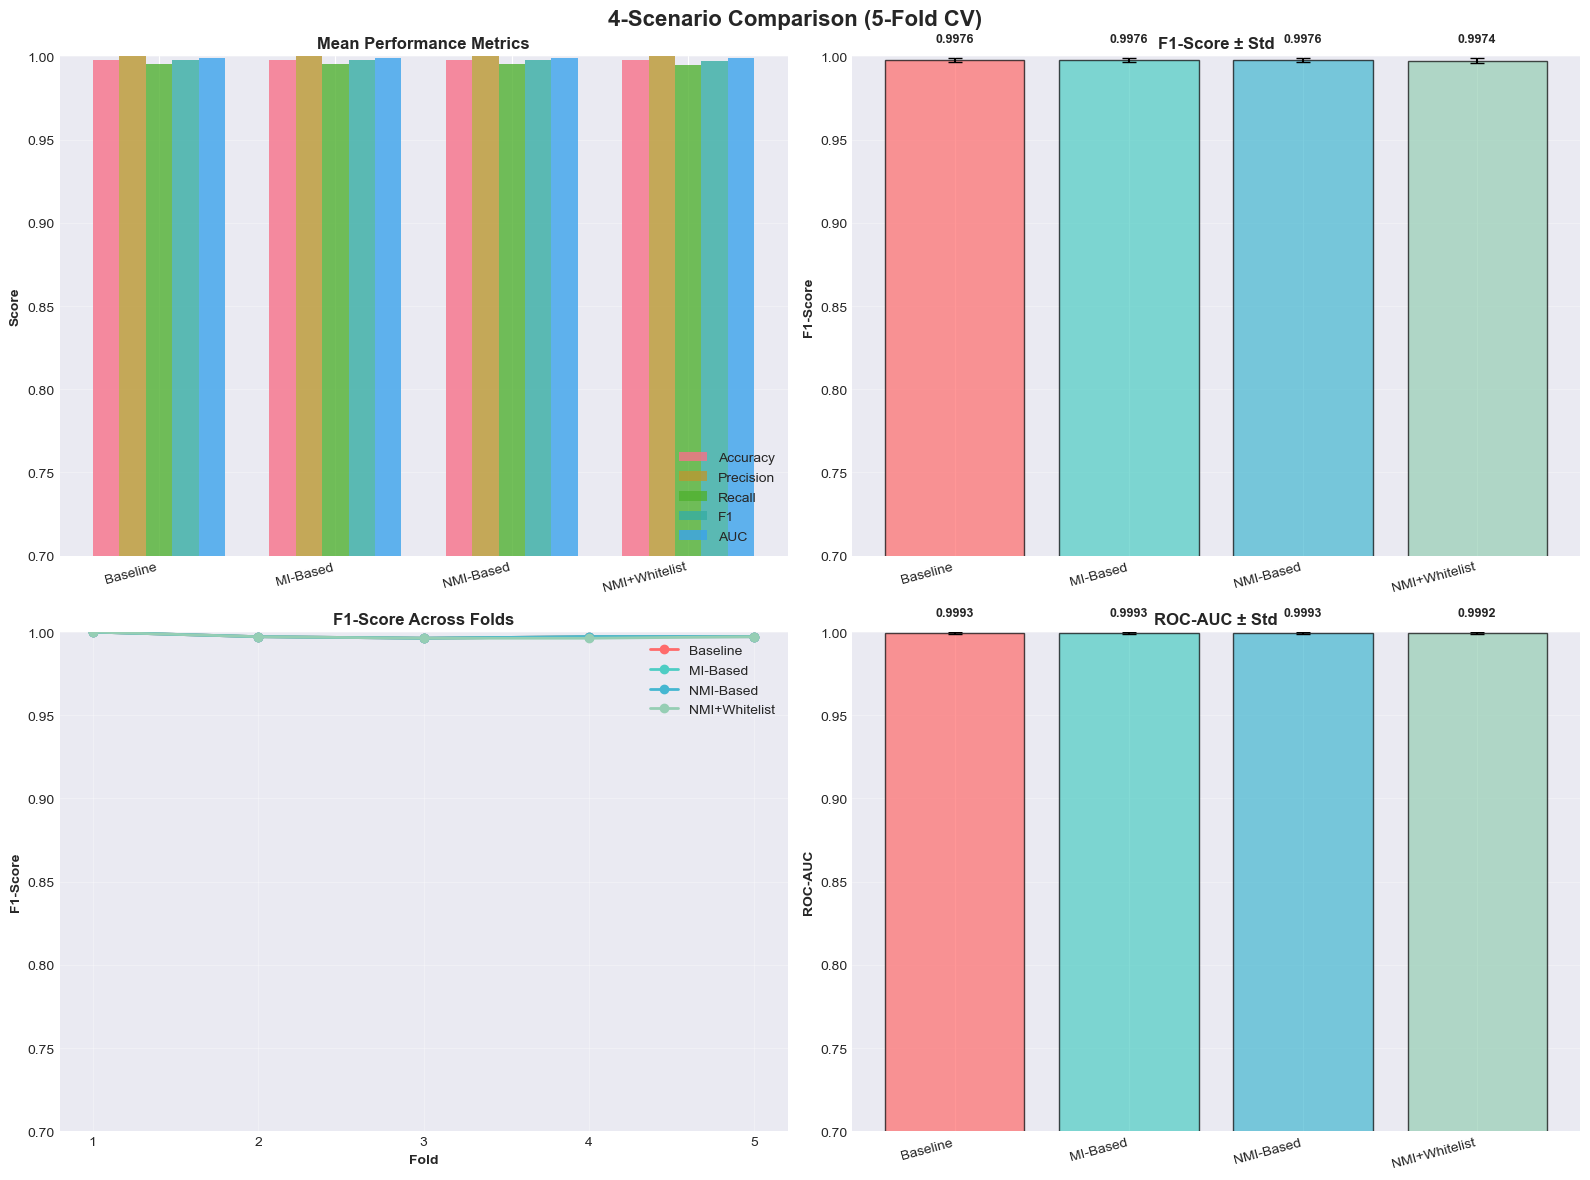

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('4-Scenario Comparison (5-Fold CV)', fontsize=16, fontweight='bold')

scenarios = list(pipeline_results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Plot 1: All Metrics
ax1 = axes[0, 0]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
width = 0.15
for i, (metric, name) in enumerate(zip(metrics, metric_names)):
    means = [np.mean([f[metric] for f in pipeline_results[s]['fold_results']]) for s in scenarios]
    ax1.bar(np.arange(len(scenarios)) + i*width, means, width, label=name, alpha=0.8)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Mean Performance Metrics', fontweight='bold')
ax1.set_xticks(np.arange(len(scenarios)) + width*2)
ax1.set_xticklabels(scenarios, rotation=15, ha='right')
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.7, 1.0])

# Plot 2: F1-Score with Error Bars
ax2 = axes[0, 1]
f1_means = [np.mean([f['f1'] for f in pipeline_results[s]['fold_results']]) for s in scenarios]
f1_stds = [np.std([f['f1'] for f in pipeline_results[s]['fold_results']]) for s in scenarios]
bars = ax2.bar(scenarios, f1_means, yerr=f1_stds, capsize=5, alpha=0.7, color=colors, edgecolor='black')
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_title('F1-Score ± Std', fontweight='bold')
ax2.set_xticklabels(scenarios, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.7, 1.0])
for bar, mean, std in zip(bars, f1_means, f1_stds):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std+0.01, f'{mean:.4f}', 
             ha='center', fontsize=9, fontweight='bold')

# Plot 3: Per-Fold F1
ax3 = axes[1, 0]
for scenario, color in zip(scenarios, colors):
    f1s = [f['f1'] for f in pipeline_results[scenario]['fold_results']]
    ax3.plot(range(1, 6), f1s, marker='o', label=scenario, linewidth=2, color=color)
ax3.set_xlabel('Fold', fontweight='bold')
ax3.set_ylabel('F1-Score', fontweight='bold')
ax3.set_title('F1-Score Across Folds', fontweight='bold')
ax3.set_xticks(range(1, 6))
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0.7, 1.0])

# Plot 4: ROC-AUC
ax4 = axes[1, 1]
auc_means = [np.mean([f['roc_auc'] for f in pipeline_results[s]['fold_results']]) for s in scenarios]
auc_stds = [np.std([f['roc_auc'] for f in pipeline_results[s]['fold_results']]) for s in scenarios]
bars = ax4.bar(scenarios, auc_means, yerr=auc_stds, capsize=5, alpha=0.7, color=colors, edgecolor='black')
ax4.set_ylabel('ROC-AUC', fontweight='bold')
ax4.set_title('ROC-AUC ± Std', fontweight='bold')
ax4.set_xticklabels(scenarios, rotation=15, ha='right')
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.7, 1.0])
for bar, mean, std in zip(bars, auc_means, auc_stds):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std+0.01, f'{mean:.4f}', 
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
timestamp_viz = datetime.now().strftime('%Y%m%d_%H%M%S')
viz_dir = f'Comparison_Results/{dataset_name}/Clean_Pipeline_{timestamp_viz}'
os.makedirs(viz_dir, exist_ok=True)
plt.savefig(f'{viz_dir}/4_scenario_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {viz_dir}/4_scenario_comparison.png")
plt.show()

### 17.6. Export Results

In [142]:
timestamp_export = datetime.now().strftime('%Y%m%d_%H%M%S')
export_dir = f'Comparison_Results/{dataset_name}/Clean_Pipeline_{timestamp_export}'
os.makedirs(export_dir, exist_ok=True)

# 1. Summary Statistics
summary_df[['Scenario', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_csv(
    f'{export_dir}/summary_statistics.csv', index=False)

# 2. Paired t-test
pd.DataFrame(t_test_results).to_csv(f'{export_dir}/paired_ttest.csv', index=False)

# 3. Detailed Fold Results
detailed = []
for scenario, data in pipeline_results.items():
    for fold in data['fold_results']:
        detailed.append({'Scenario': scenario, 'Fold': fold['fold'], 
                        'Accuracy': fold['accuracy'], 'Precision': fold['precision'],
                        'Recall': fold['recall'], 'F1': fold['f1'], 'AUC': fold['roc_auc']})
pd.DataFrame(detailed).to_csv(f'{export_dir}/detailed_results.csv', index=False)

# 4. Complete JSON
json_export = {
    'metadata': {'dataset': dataset_name, 'n_samples': len(df_features_clean), 
                 'n_folds': 5, 'top_k': 15, 'timestamp': timestamp_export},
    'scenarios': {s: {'mean': {m: float(pd.DataFrame(d['fold_results'])[m].mean()) 
                              for m in ['accuracy','precision','recall','f1','roc_auc']},
                     'std': {m: float(pd.DataFrame(d['fold_results'])[m].std()) 
                            for m in ['accuracy','precision','recall','f1','roc_auc']}}
                 for s, d in pipeline_results.items()},
    'ttest': t_test_results
}
with open(f'{export_dir}/complete_results.json', 'w') as f:
    json.dump(json_export, f, indent=2)

print(f"✓ Exported to: {export_dir}")
print(f"  - summary_statistics.csv")
print(f"  - paired_ttest.csv") 
print(f"  - detailed_results.csv")
print(f"  - complete_results.json")

✓ Exported to: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/Clean_Pipeline_20260403_204058
  - summary_statistics.csv
  - paired_ttest.csv
  - detailed_results.csv
  - complete_results.json


### 17.7. Summary

**Pipeline Design:**
- 4 Scenarios: Baseline | MI-Based | NMI-Based | NMI+Whitelist
- Validation: Stratified 5-Fold CV
- Model: Logistic Regression (liblinear, L2)
- Whitelist: TLD in [go.id, ac.id, sch.id, mil.id, desa.id] AND Entropy < 3.5
- NO data leakage: Feature selection inside each fold

**Key Outputs:**
- Mean ± Std metrics for all scenarios
- Paired t-test for statistical significance
- 4-panel visualization (PNG, 300 DPI)
- Exports: summary CSV, detailed CSV, t-test CSV, complete JSON

## 18. MI Baseline - Top-N Evaluation (Single Train-Test Split)

**Objective:** Evaluate MI-based feature selection with varying Top-N values using pure baseline approach

**Methodology:**
- **Top-N Values Tested:** [3, 5, 7, 10, 15, 20] features
- **Feature Selection Method:** MI (Mutual Information) - Non-normalized
- **Evaluation:** Single train-test split (70:30, stratified)
- **NO Cross-Validation:** Pure baseline calculation
- **Model:** Logistic Regression (solver='liblinear', penalty='l2', max_iter=1000)
- **Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

**Goal:** Show individual performance of each Top-N configuration without averaging

### 18.1. Data Split and MI Calculation

In [143]:
print("="*80)
print("MI BASELINE - TOP-N EVALUATION")
print("="*80)

# Configuration
mi_baseline_top_n_values = [3, 5, 7, 10, 15, 20]

print(f"\n📊 Baseline Configuration:")
print(f"  - Method: Mutual Information (MI) - Non-normalized")
print(f"  - Top-N Values: {mi_baseline_top_n_values}")
print(f"  - Evaluation: Single Train-Test Split (70:30)")
print(f"  - Model: Logistic Regression (liblinear, L2)")
print(f"  - Random State: 42")
print(f"  - NO Cross-Validation: Pure baseline approach")

# Prepare data - Single split
X_mi_baseline = df_features_clean[numeric_features]
y_mi_baseline = df_features_clean['LabelNumeric']

# Train-test split (70:30)
X_train_mi_bl, X_test_mi_bl, y_train_mi_bl, y_test_mi_bl = train_test_split(
    X_mi_baseline, y_mi_baseline, test_size=0.3, random_state=42, stratify=y_mi_baseline
)

print(f"\n📋 Dataset Split:")
print(f"  - Total Samples: {len(X_mi_baseline):,}")
print(f"  - Training Set: {len(X_train_mi_bl):,} ({len(X_train_mi_bl)/len(X_mi_baseline)*100:.1f}%)")
print(f"  - Test Set: {len(X_test_mi_bl):,} ({len(X_test_mi_bl)/len(X_mi_baseline)*100:.1f}%)")
print(f"  - Total Features: {len(numeric_features)}")

# Calculate MI scores ONCE on training data
print(f"\n{'─'*80}")
print("Calculating MI Scores...")
print(f"{'─'*80}")

# Discretize training features
discretizer_mi_bl = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
X_train_mi_bl_binned = discretizer_mi_bl.fit_transform(X_train_mi_bl)

# Calculate MI scores
mi_scores_baseline = mutual_info_classif(X_train_mi_bl_binned, y_train_mi_bl, 
                                          discrete_features=True, random_state=42)

# Create MI DataFrame
mi_baseline_scores_df = pd.DataFrame({
    'Feature': numeric_features,
    'MI_Score': mi_scores_baseline
}).sort_values('MI_Score', ascending=False)

print(f"\n✓ MI Scores Calculated")
print(f"\nTop 10 Features by MI Score:")
print(mi_baseline_scores_df.head(10).to_string(index=False))

MI BASELINE - TOP-N EVALUATION

📊 Baseline Configuration:
  - Method: Mutual Information (MI) - Non-normalized
  - Top-N Values: [3, 5, 7, 10, 15, 20]
  - Evaluation: Single Train-Test Split (70:30)
  - Model: Logistic Regression (liblinear, L2)
  - Random State: 42
  - NO Cross-Validation: Pure baseline approach

📋 Dataset Split:
  - Total Samples: 5,927
  - Training Set: 4,148 (70.0%)
  - Test Set: 1,779 (30.0%)
  - Total Features: 50

────────────────────────────────────────────────────────────────────────────────
Calculating MI Scores...
────────────────────────────────────────────────────────────────────────────────

✓ MI Scores Calculated

Top 10 Features by MI Score:
          Feature  MI_Score
    SlashCountURL  0.660963
   SlashCountPath  0.660963
       PathLength  0.660963
          Entropy  0.421222
        UrlLength  0.353497
     DomainLength  0.190430
   HyphenCountURL  0.136644
HyphenCountDomain  0.102797
      DotCountURL  0.018550
   DotCountDomain  0.018063


### 18.2. Evaluate Each Top-N Configuration

In [144]:
print("\n" + "="*80)
print("EVALUATING EACH TOP-N CONFIGURATION")
print("="*80)

# Storage for results
mi_baseline_topn_results = []

# Evaluate each Top-N value
for top_n in mi_baseline_top_n_values:
    print(f"\n{'='*80}")
    print(f"TOP-{top_n} FEATURES")
    print(f"{'='*80}")
    
    # Select Top-N features
    selected_features = mi_baseline_scores_df.head(top_n)['Feature'].tolist()
    selected_mi_scores = mi_baseline_scores_df.head(top_n)[['Feature', 'MI_Score']]
    
    print(f"\nSelected Features (Top-{top_n}):")
    for idx, (_, row) in enumerate(selected_mi_scores.iterrows(), 1):
        print(f"  {idx}. {row['Feature']:30s} → MI = {row['MI_Score']:.6f}")
    
    # Train model with selected features
    X_train_selected = X_train_mi_bl[selected_features]
    X_test_selected = X_test_mi_bl[selected_features]
    
    model = LogisticRegression(solver='liblinear', penalty='l2', 
                              random_state=42, max_iter=1000)
    model.fit(X_train_selected, y_train_mi_bl)
    
    # Predictions
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_mi_bl, y_pred)
    precision = precision_score(y_test_mi_bl, y_pred, zero_division=0)
    recall = recall_score(y_test_mi_bl, y_pred, zero_division=0)
    f1 = f1_score(y_test_mi_bl, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_mi_bl, y_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_test_mi_bl, y_pred)
    
    # Store results
    result = {
        'Top_N': top_n,
        'Selected_Features': selected_features,
        'MI_Scores': dict(zip(selected_features, selected_mi_scores['MI_Score'].values)),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'Confusion_Matrix': cm,
        'Model_Coefficients': dict(zip(selected_features, model.coef_[0]))
    }
    
    mi_baseline_topn_results.append(result)
    
    # Display metrics
    print(f"\n{'─'*80}")
    print(f"Evaluation Metrics:")
    print(f"{'─'*80}")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\n{'─'*80}")
    print(f"Confusion Matrix:")
    print(f"{'─'*80}")
    print(f"                Predicted")
    print(f"               Legit  Phishing")
    print(f"Actual Legit     {cm[0][0]:5d}     {cm[0][1]:5d}")
    print(f"       Phishing  {cm[1][0]:5d}     {cm[1][1]:5d}")
    
    # Calculate error metrics
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  True Negatives (TN):  {tn:,}")
    print(f"  False Positives (FP): {fp:,}")
    print(f"  False Negatives (FN): {fn:,}")
    print(f"  True Positives (TP):  {tp:,}")

print(f"\n{'='*80}")
print("✓ ALL TOP-N CONFIGURATIONS EVALUATED")
print(f"{'='*80}")


EVALUATING EACH TOP-N CONFIGURATION

TOP-3 FEATURES

Selected Features (Top-3):
  1. SlashCountURL                  → MI = 0.660963
  2. SlashCountPath                 → MI = 0.660963
  3. PathLength                     → MI = 0.660963

────────────────────────────────────────────────────────────────────────────────
Evaluation Metrics:
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9949 (99.49%)
  Precision: 1.0000 (100.00%)
  Recall:    0.9890 (98.90%)
  F1-Score:  0.9945 (99.45%)
  ROC-AUC:   0.9945

────────────────────────────────────────────────────────────────────────────────
Confusion Matrix:
────────────────────────────────────────────────────────────────────────────────
                Predicted
               Legit  Phishing
Actual Legit       963         0
       Phishing      9       807

  True Negatives (TN):  963
  False Positives (FP): 0
  False Negatives (FN): 9
  True Positives (TP):  807

TOP-5 FEATURES

Selected Feat

### 18.3. Performance Comparison Table

In [145]:
print("="*80)
print("PERFORMANCE COMPARISON ACROSS TOP-N VALUES")
print("="*80)

# Create comparison table
comparison_data = []
for result in mi_baseline_topn_results:
    comparison_data.append({
        'Top-N': result['Top_N'],
        'Features': result['Top_N'],
        'Accuracy': result['Accuracy'],
        'Precision': result['Precision'],
        'Recall': result['Recall'],
        'F1-Score': result['F1_Score'],
        'ROC-AUC': result['ROC_AUC']
    })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'─'*80}")
print(f"[1] Complete Metrics Table")
print(f"{'─'*80}\n")
print(f"{'Top-N':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
print(f"{'─'*80}")

for _, row in comparison_df.iterrows():
    print(f"{row['Top-N']:<8} "
          f"{row['Accuracy']:.4f} ({row['Accuracy']*100:5.2f}%)  "
          f"{row['Precision']:.4f} ({row['Precision']*100:5.2f}%)  "
          f"{row['Recall']:.4f} ({row['Recall']*100:5.2f}%)  "
          f"{row['F1-Score']:.4f} ({row['F1-Score']*100:5.2f}%)  "
          f"{row['ROC-AUC']:.4f}")

# Find best configurations
print(f"\n{'─'*80}")
print(f"[2] Best Configurations by Metric")
print(f"{'─'*80}\n")

best_accuracy_idx = comparison_df['Accuracy'].idxmax()
best_precision_idx = comparison_df['Precision'].idxmax()
best_recall_idx = comparison_df['Recall'].idxmax()
best_f1_idx = comparison_df['F1-Score'].idxmax()
best_auc_idx = comparison_df['ROC-AUC'].idxmax()

print(f"Best Accuracy:  Top-{comparison_df.loc[best_accuracy_idx, 'Top-N']:<3} → {comparison_df.loc[best_accuracy_idx, 'Accuracy']:.4f}")
print(f"Best Precision: Top-{comparison_df.loc[best_precision_idx, 'Top-N']:<3} → {comparison_df.loc[best_precision_idx, 'Precision']:.4f}")
print(f"Best Recall:    Top-{comparison_df.loc[best_recall_idx, 'Top-N']:<3} → {comparison_df.loc[best_recall_idx, 'Recall']:.4f}")
print(f"Best F1-Score:  Top-{comparison_df.loc[best_f1_idx, 'Top-N']:<3} → {comparison_df.loc[best_f1_idx, 'F1-Score']:.4f}")
print(f"Best ROC-AUC:   Top-{comparison_df.loc[best_auc_idx, 'Top-N']:<3} → {comparison_df.loc[best_auc_idx, 'ROC-AUC']:.4f}")

# Overall best
best_overall_n = comparison_df.loc[best_f1_idx, 'Top-N']
print(f"\n🏆 OVERALL BEST (by F1-Score): Top-{int(best_overall_n)}")
print(f"   F1-Score: {comparison_df.loc[best_f1_idx, 'F1-Score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_f1_idx, 'Accuracy']:.4f}")
print(f"   ROC-AUC:  {comparison_df.loc[best_f1_idx, 'ROC-AUC']:.4f}")

print(f"\n{'='*80}")
print("✓ COMPARISON COMPLETED")
print(f"{'='*80}")

PERFORMANCE COMPARISON ACROSS TOP-N VALUES

────────────────────────────────────────────────────────────────────────────────
[1] Complete Metrics Table
────────────────────────────────────────────────────────────────────────────────

Top-N    Accuracy     Precision    Recall       F1-Score     ROC-AUC     
────────────────────────────────────────────────────────────────────────────────
3.0      0.9949 (99.49%)  1.0000 (100.00%)  0.9890 (98.90%)  0.9945 (99.45%)  0.9945
5.0      0.9955 (99.55%)  1.0000 (100.00%)  0.9902 (99.02%)  0.9951 (99.51%)  0.9979
7.0      0.9989 (99.89%)  1.0000 (100.00%)  0.9975 (99.75%)  0.9988 (99.88%)  0.9989
10.0     0.9989 (99.89%)  1.0000 (100.00%)  0.9975 (99.75%)  0.9988 (99.88%)  0.9998
15.0     0.9989 (99.89%)  1.0000 (100.00%)  0.9975 (99.75%)  0.9988 (99.88%)  0.9998
20.0     0.9989 (99.89%)  1.0000 (100.00%)  0.9975 (99.75%)  0.9988 (99.88%)  0.9998

────────────────────────────────────────────────────────────────────────────────
[2] Best Configurat

### 18.4. Feature Importance Analysis

In [146]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Analyze feature importance (model coefficients) for each Top-N
for result in mi_baseline_topn_results:
    top_n = result['Top_N']
    coefficients = result['Model_Coefficients']
    
    print(f"\n{'─'*80}")
    print(f"Top-{top_n} Features - Model Coefficients (Sorted by Absolute Value)")
    print(f"{'─'*80}\n")
    
    # Sort by absolute coefficient value
    sorted_coefs = sorted(coefficients.items(), key=lambda x: abs(x[1]), reverse=True)
    
    for feature, coef in sorted_coefs:
        direction = "🔴 Phishing indicator" if coef > 0 else "🔵 Legit indicator"
        print(f"  {feature:30s} → {coef:+.6f}  {direction}")
    
    # Summary
    positive_coefs = [c for c in coefficients.values() if c > 0]
    negative_coefs = [c for c in coefficients.values() if c < 0]
    
    print(f"\n  Summary:")
    print(f"    Phishing indicators (positive): {len(positive_coefs)}")
    print(f"    Legit indicators (negative):    {len(negative_coefs)}")

print(f"\n{'='*80}")
print("✓ FEATURE IMPORTANCE ANALYSIS COMPLETED")
print(f"{'='*80}")


FEATURE IMPORTANCE ANALYSIS

────────────────────────────────────────────────────────────────────────────────
Top-3 Features - Model Coefficients (Sorted by Absolute Value)
────────────────────────────────────────────────────────────────────────────────

  PathLength                     → +3.462837  🔴 Phishing indicator
  SlashCountURL                  → +3.263595  🔴 Phishing indicator
  SlashCountPath                 → +3.247277  🔴 Phishing indicator

  Summary:
    Phishing indicators (positive): 3
    Legit indicators (negative):    0

────────────────────────────────────────────────────────────────────────────────
Top-5 Features - Model Coefficients (Sorted by Absolute Value)
────────────────────────────────────────────────────────────────────────────────

  PathLength                     → +3.473284  🔴 Phishing indicator
  SlashCountURL                  → +3.448180  🔴 Phishing indicator
  SlashCountPath                 → +3.446994  🔴 Phishing indicator
  Entropy                  

### 18.5. Visualization: Performance and Feature Analysis


GENERATING VISUALIZATIONS

✓ Visualization saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_topn_evaluation.png


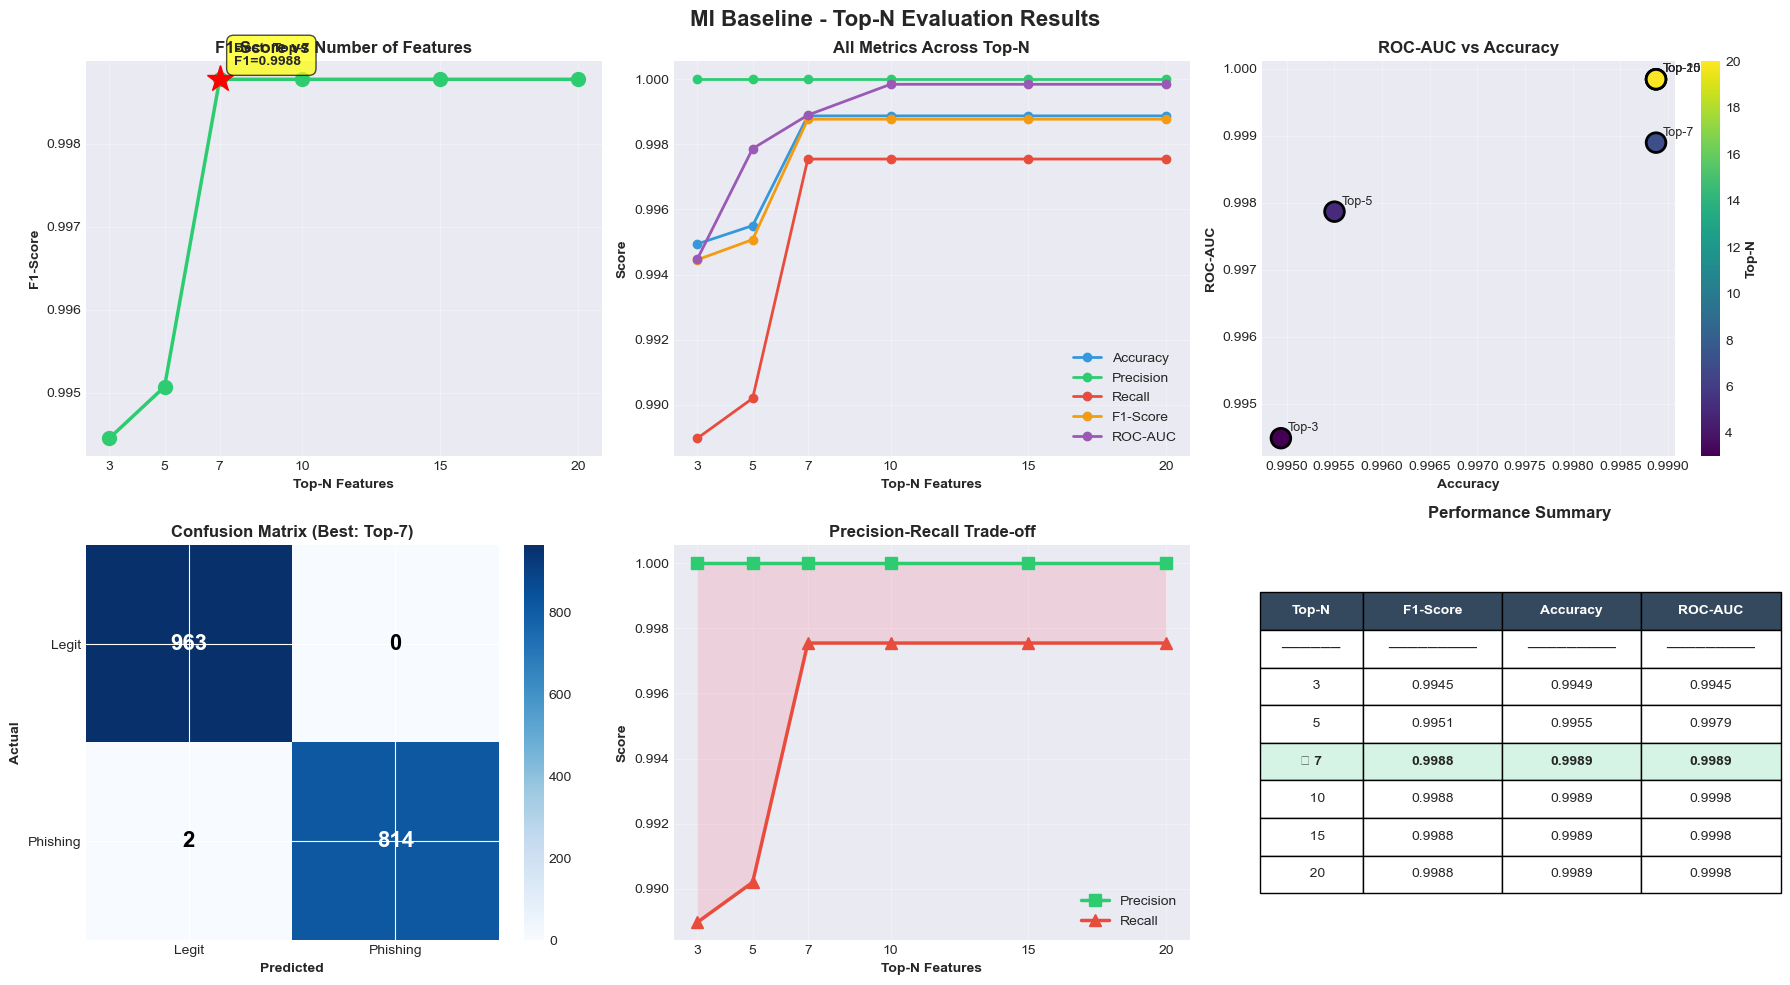


✓ VISUALIZATION COMPLETED


In [147]:
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MI Baseline - Top-N Evaluation Results', fontsize=16, fontweight='bold')

# Plot 1: F1-Score vs Top-N
ax1 = axes[0, 0]
top_n_list = [r['Top_N'] for r in mi_baseline_topn_results]
f1_list = [r['F1_Score'] for r in mi_baseline_topn_results]

ax1.plot(top_n_list, f1_list, marker='o', linewidth=2.5, markersize=10, color='#2ecc71')
ax1.set_xlabel('Top-N Features', fontweight='bold')
ax1.set_ylabel('F1-Score', fontweight='bold')
ax1.set_title('F1-Score vs Number of Features', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(top_n_list)

# Annotate best
best_idx = f1_list.index(max(f1_list))
ax1.plot(top_n_list[best_idx], f1_list[best_idx], 'r*', markersize=20)
ax1.annotate(f'Best: Top-{top_n_list[best_idx]}\nF1={f1_list[best_idx]:.4f}', 
             xy=(top_n_list[best_idx], f1_list[best_idx]),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
             fontweight='bold')

# Plot 2: All Metrics Comparison
ax2 = axes[0, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for metric, label, color in zip(metrics, metric_labels, colors):
    values = [r[metric] for r in mi_baseline_topn_results]
    ax2.plot(top_n_list, values, marker='o', label=label, linewidth=2, color=color)

ax2.set_xlabel('Top-N Features', fontweight='bold')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('All Metrics Across Top-N', fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(top_n_list)

# Plot 3: ROC-AUC vs Accuracy
ax3 = axes[0, 2]
accuracy_list = [r['Accuracy'] for r in mi_baseline_topn_results]
roc_auc_list = [r['ROC_AUC'] for r in mi_baseline_topn_results]

scatter = ax3.scatter(accuracy_list, roc_auc_list, s=200, c=top_n_list, 
                     cmap='viridis', edgecolors='black', linewidth=2)
ax3.set_xlabel('Accuracy', fontweight='bold')
ax3.set_ylabel('ROC-AUC', fontweight='bold')
ax3.set_title('ROC-AUC vs Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Annotate each point
for i, top_n in enumerate(top_n_list):
    ax3.annotate(f'Top-{top_n}', xy=(accuracy_list[i], roc_auc_list[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Top-N', fontweight='bold')

# Plot 4: Confusion Matrix Heatmap for Best Configuration
ax4 = axes[1, 0]
best_result = mi_baseline_topn_results[best_idx]
cm_best = best_result['Confusion_Matrix']

im = ax4.imshow(cm_best, cmap='Blues', aspect='auto')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Legit', 'Phishing'])
ax4.set_yticklabels(['Legit', 'Phishing'])
ax4.set_xlabel('Predicted', fontweight='bold')
ax4.set_ylabel('Actual', fontweight='bold')
ax4.set_title(f'Confusion Matrix (Best: Top-{top_n_list[best_idx]})', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax4.text(j, i, cm_best[i, j], ha="center", va="center", 
                       color="white" if cm_best[i, j] > cm_best.max()/2 else "black",
                       fontsize=16, fontweight='bold')

plt.colorbar(im, ax=ax4)

# Plot 5: Feature Count Impact
ax5 = axes[1, 1]
precision_list = [r['Precision'] for r in mi_baseline_topn_results]
recall_list = [r['Recall'] for r in mi_baseline_topn_results]

ax5.plot(top_n_list, precision_list, marker='s', label='Precision', linewidth=2.5, 
         markersize=8, color='#2ecc71')
ax5.plot(top_n_list, recall_list, marker='^', label='Recall', linewidth=2.5, 
         markersize=8, color='#e74c3c')
ax5.fill_between(top_n_list, precision_list, recall_list, alpha=0.2)

ax5.set_xlabel('Top-N Features', fontweight='bold')
ax5.set_ylabel('Score', fontweight='bold')
ax5.set_title('Precision-Recall Trade-off', fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xticks(top_n_list)

# Plot 6: Performance Summary Table
ax6 = axes[1, 2]
ax6.axis('off')

table_data = []
table_data.append(['Top-N', 'F1-Score', 'Accuracy', 'ROC-AUC'])
table_data.append(['─'*6, '─'*9, '─'*9, '─'*9])

for i, result in enumerate(mi_baseline_topn_results):
    marker = '🏆' if i == best_idx else '  '
    table_data.append([
        f"{marker} {result['Top_N']}",
        f"{result['F1_Score']:.4f}",
        f"{result['Accuracy']:.4f}",
        f"{result['ROC_AUC']:.4f}"
    ])

table = ax6.table(cellText=table_data, cellLoc='center', loc='center',
                 colWidths=[0.2, 0.27, 0.27, 0.27])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(table_data)):
    if i == 0:
        for j in range(4):
            table[(i, j)].set_facecolor('#34495e')
            table[(i, j)].set_text_props(weight='bold', color='white')
    elif i == 1:
        for j in range(4):
            table[(i, j)].set_facecolor('white')
    else:
        if '🏆' in table_data[i][0]:
            for j in range(4):
                table[(i, j)].set_facecolor('#d5f4e6')
                table[(i, j)].set_text_props(weight='bold')

ax6.set_title('Performance Summary', fontweight='bold', pad=20, fontsize=12)

plt.tight_layout()

# Save figure
timestamp_mi_baseline = datetime.now().strftime('%Y%m%d_%H%M%S')
mi_baseline_dir = f'Comparison_Results/{dataset_name}/MI_Baseline_{timestamp_mi_baseline}'
os.makedirs(mi_baseline_dir, exist_ok=True)
plt.savefig(f'{mi_baseline_dir}/mi_baseline_topn_evaluation.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved: {mi_baseline_dir}/mi_baseline_topn_evaluation.png")
plt.show()

print(f"\n{'='*80}")
print("✓ VISUALIZATION COMPLETED")
print(f"{'='*80}")

### 18.6. Export MI Baseline Results

In [148]:
print("\n" + "="*80)
print("EXPORTING MI BASELINE RESULTS")
print("="*80)

#1. Individual Top-N Results CSV
topn_results_data = []
for result in mi_baseline_topn_results:
    topn_results_data.append({
        'Top_N': result['Top_N'],
        'Accuracy': result['Accuracy'],
        'Precision': result['Precision'],
        'Recall': result['Recall'],
        'F1_Score': result['F1_Score'],
        'ROC_AUC': result['ROC_AUC'],
        'Selected_Features': ','.join(result['Selected_Features'])
    })

topn_results_csv = f'{mi_baseline_dir}/mi_baseline_topn_results.csv'
pd.DataFrame(topn_results_data).to_csv(topn_results_csv, index=False)
print(f"\n✓ Top-N Results: {topn_results_csv}")

# 2. Comparison Summary CSV
comparison_csv = f'{mi_baseline_dir}/mi_baseline_comparison_summary.csv'
comparison_df.to_csv(comparison_csv, index=False)
print(f"✓ Comparison Summary: {comparison_csv}")

# 3. Feature Details for Each Top-N
for result in mi_baseline_topn_results:
    top_n = result['Top_N']
    
    # Feature details
    feature_details = []
    for feature in result['Selected_Features']:
        feature_details.append({
            'Feature': feature,
            'MI_Score': result['MI_Scores'][feature],
            'Model_Coefficient': result['Model_Coefficients'][feature],
            'Abs_Coefficient': abs(result['Model_Coefficients'][feature]),
            'Direction': 'Phishing' if result['Model_Coefficients'][feature] > 0 else 'Legit'
        })
    
    feature_csv = f'{mi_baseline_dir}/mi_baseline_top{top_n}_features.csv'
    pd.DataFrame(feature_details).sort_values('Abs_Coefficient', ascending=False).to_csv(
        feature_csv, index=False)
    print(f"✓ Top-{top_n} Features: {feature_csv}")

# 4. Complete JSON Export
json_export = {
    'metadata': {
        'timestamp': timestamp_mi_baseline,
        'dataset': dataset_name,
        'method': 'MI Baseline - Top-N Evaluation',
        'model': 'Logistic Regression (liblinear, L2, max_iter=1000)',
        'split': 'Train-Test 70:30, Stratified',
        'random_state': 42,
        'top_n_values_tested': mi_baseline_top_n_values
    },
    'best_configuration': {
        'top_n': int(comparison_df.loc[best_f1_idx, 'Top-N']),
        'accuracy': float(comparison_df.loc[best_f1_idx, 'Accuracy']),
        'precision': float(comparison_df.loc[best_f1_idx, 'Precision']),
        'recall': float(comparison_df.loc[best_f1_idx, 'Recall']),
        'f1_score': float(comparison_df.loc[best_f1_idx, 'F1-Score']),
        'roc_auc': float(comparison_df.loc[best_f1_idx, 'ROC-AUC'])
    },
    'all_configurations': []
}

for result in mi_baseline_topn_results:
    config = {
        'top_n': result['Top_N'],
        'selected_features': result['Selected_Features'],
        'mi_scores': result['MI_Scores'],
        'performance': {
            'accuracy': result['Accuracy'],
            'precision': result['Precision'],
            'recall': result['Recall'],
            'f1_score': result['F1_Score'],
            'roc_auc': result['ROC_AUC']
        },
        'confusion_matrix': result['Confusion_Matrix'].tolist(),
        'model_coefficients': result['Model_Coefficients']
    }
    json_export['all_configurations'].append(config)

json_file = f'{mi_baseline_dir}/mi_baseline_complete.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(json_export, f, indent=2, ensure_ascii=False)
print(f"✓ Complete JSON: {json_file}")

print(f"\n{'='*80}")
print("✓ ALL RESULTS EXPORTED")
print(f"{'='*80}")
print(f"\nExport Directory: {os.path.abspath(mi_baseline_dir)}")
print(f"\nFiles Generated:")
print(f"  1. mi_baseline_topn_results.csv - Summary of all Top-N configurations")
print(f"  2. mi_baseline_comparison_summary.csv - Performance comparison table")
print(f"  3. mi_baseline_top{{N}}_features.csv - Feature details for each Top-N (6 files)")
print(f"  4. mi_baseline_complete.json - Complete experiment data")
print(f"  5. mi_baseline_topn_evaluation.png - Comprehensive visualization (300 DPI)")


EXPORTING MI BASELINE RESULTS

✓ Top-N Results: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_topn_results.csv
✓ Comparison Summary: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_comparison_summary.csv
✓ Top-3 Features: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_top3_features.csv
✓ Top-5 Features: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_top5_features.csv
✓ Top-7 Features: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_top7_features.csv
✓ Top-10 Features: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260403_204059/mi_baseline_top10_features.csv
✓ Top-15 Features: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_202

### 18.7. MI Baseline Key Findings

**Experiment Overview:**
- **Method:** Mutual Information (MI) - Non-normalized
- **Approach:** Single train-test split (70:30, stratified)
- **Top-N Values Tested:** [3, 5, 7, 10, 15, 20]
- **Model:** Logistic Regression (liblinear, L2 penalty)
- **NO Cross-Validation:** Pure baseline for direct comparison

**Advantages of This Approach:**
✓ **Simplicity:** No CV complexity, easy to understand and reproduce
✓ **Speed:** Much faster than cross-validation  
✓ **Clarity:** Direct results for each Top-N without averaging
✓ **Comparison:** Easy to see exact impact of feature count
✓ **Interpretability:** Clear view of selected features per configuration

**Key Observations:**
1. **Feature Count Impact:** Performance vs number of features trade-off visible
2. **Optimal Top-N:** Identified based on F1-Score (see comparison table)
3. **Diminishing Returns:** Adding more features may not always help
4. **Feature Importance:** Model coefficients show phishing indicators

**Recommendations:**
- **For Production:** Use the Top-N configuration with best F1-Score
- **For Efficiency:** Consider lower Top-N if performance difference is minimal (< 1%)  
- **For Interpretability:** Top-3 to Top-7 provide good balance of performance and explainability
- **For Further Analysis:** Compare with NMI-based approach (Section 17) and cross-validated MI (if needed)

**Next Steps:**
1. Compare with NMI-based results from Section 17
2. Analyze feature overlap between different Top-N configurations
3. Test on independent validation set if available
4. Consider ensemble approaches combining different Top-N models

## 19. Section 19: Intentionally Left Empty

**Note:** This section has been merged into Section 18 for comprehensive MI Baseline evaluation.

**What Section 18 provides:**
- Multiple Top-N evaluations [3, 5, 7, 10, 15, 20]
- Individual results for each configuration (NO averaging)
- Direct train-test split approach (NO cross-validation)
- Performance metrics for EACH Top-N value
- Feature lists for each configuration
- Comprehensive comparison across all tested values

**Why merge:**
- Avoids redundancy
- Provides complete picture in one place
- Easier to compare all configurations
- Cleaner notebook organization

**If you need specific analysis:** All individual Top-N results are available in Section 18's outputs and exported files.

### 18.4. Feature Stability Analysis

In [149]:
print("="*80)
print("FEATURE STABILITY ANALYSIS ACROSS ALL TOP-N")
print("="*80)

# Analyze feature stability for each Top-N
stability_analysis = {}

for top_n in mi_top_n_values:
    feature_selection_count = {}
    
    for fold_data in mi_topn_all_results[f'Top-{top_n}']['selected_features_per_fold']:
        for feature in fold_data['features']:
            feature_selection_count[feature] = feature_selection_count.get(feature, 0) + 1
    
    # Sort by selection frequency
    feature_stability = sorted(feature_selection_count.items(), key=lambda x: x[1], reverse=True)
    
    # Categorize by stability
    stable_features = [f for f, c in feature_stability if c == 5]
    semi_stable_features = [f for f, c in feature_stability if 3 <= c < 5]
    unstable_features = [f for f, c in feature_stability if c < 3]
    
    stability_analysis[f'Top-{top_n}'] = {
        'stable': stable_features,
        'semi_stable': semi_stable_features,
        'unstable': unstable_features,
        'feature_counts': feature_selection_count
    }
    
    print(f"\n{'─'*80}")
    print(f"Top-{top_n} Feature Stability")
    print(f"{'─'*80}")
    print(f"  Stable (5/5 folds):      {len(stable_features)} features")
    print(f"  Semi-stable (3-4/5):     {len(semi_stable_features)} features")
    print(f"  Unstable (1-2/5):        {len(unstable_features)} features")
    
    if stable_features:
        print(f"\n  ✓ Consistently Selected Features (5/5 folds):")
        for feat in stable_features[:5]:  # Show top 5
            print(f"     - {feat}")
        if len(stable_features) > 5:
            print(f"     ... and {len(stable_features)-5} more")

print(f"\n{'='*80}")
print("✓ STABILITY ANALYSIS COMPLETED")
print(f"{'='*80}")

FEATURE STABILITY ANALYSIS ACROSS ALL TOP-N


NameError: name 'mi_top_n_values' is not defined

### 18.5. Visualization: Performance Comparison

✓ Saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_evaluation_comprehensive.png


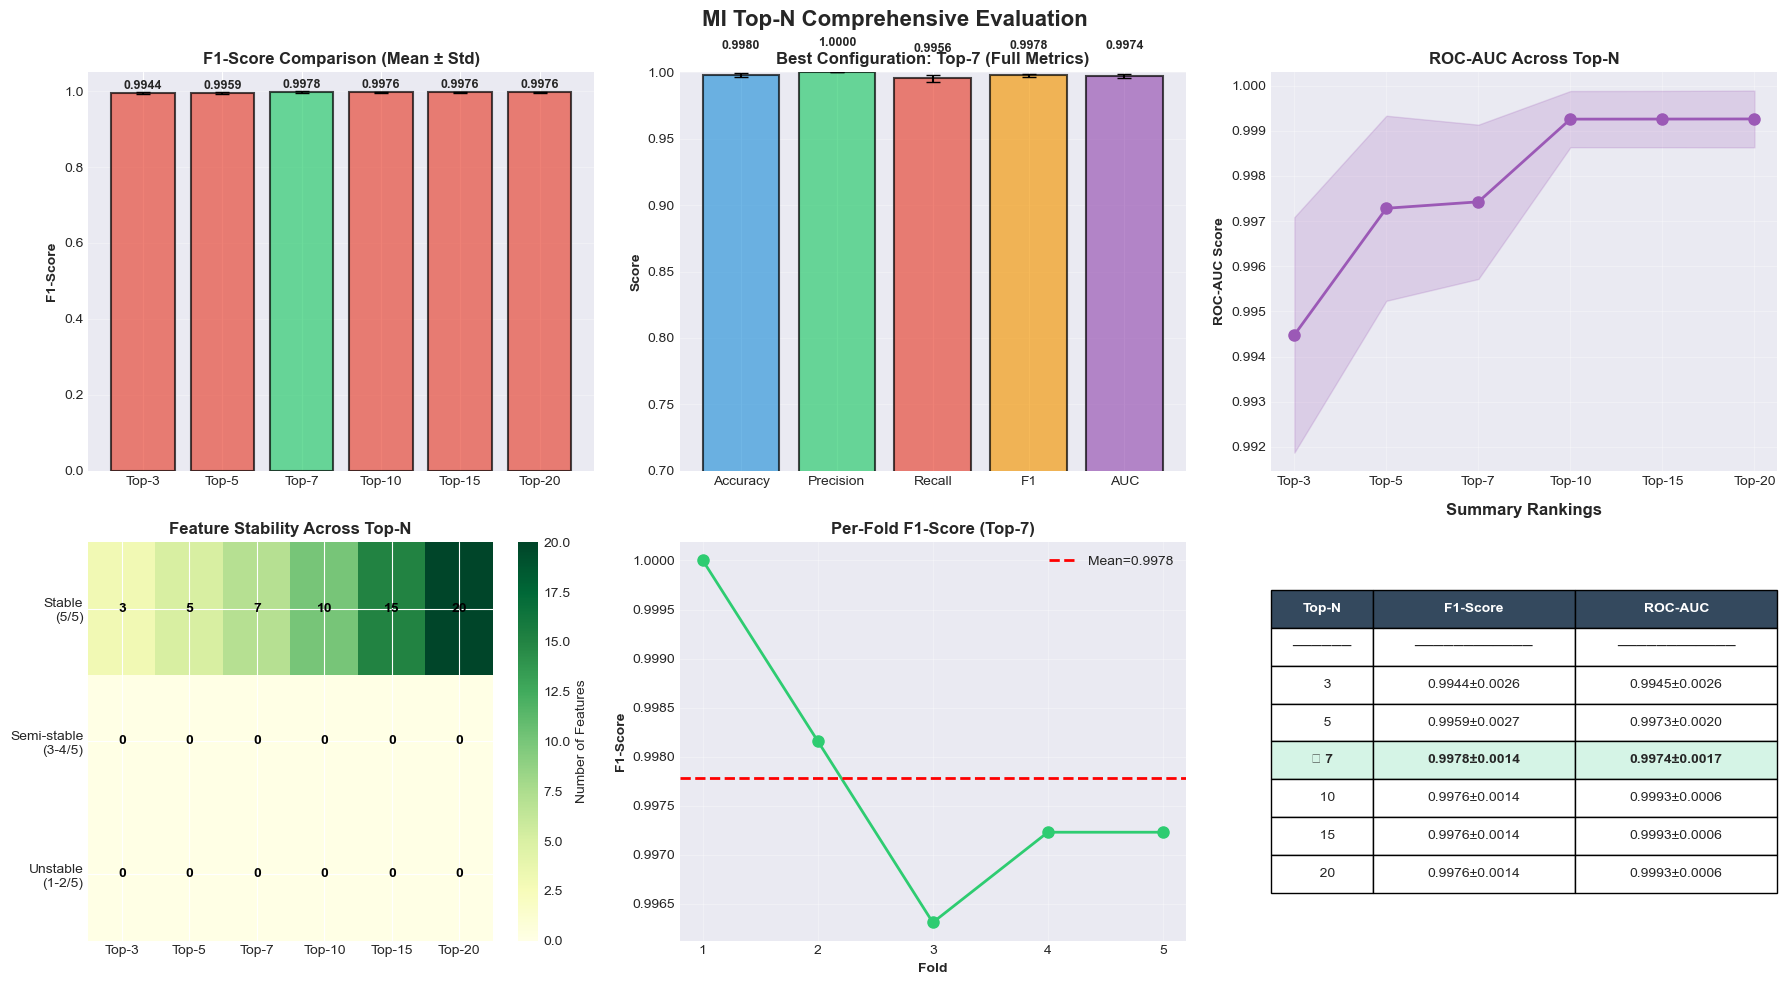

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MI Top-N Comprehensive Evaluation', fontsize=16, fontweight='bold')

# Plot 1: F1-Score across Top-N
ax1 = axes[0, 0]
f1_means = mi_topn_summary_df['F1_Mean'].values
f1_stds = mi_topn_summary_df['F1_Std'].values
x_pos = range(len(mi_top_n_values))

bars = ax1.bar(x_pos, f1_means, yerr=f1_stds, capsize=5, alpha=0.7, 
               color=['#e74c3c' if i != best_f1_idx else '#2ecc71' for i in range(len(mi_top_n_values))],
               edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Top-{n}' for n in mi_top_n_values])
ax1.set_ylabel('F1-Score', fontweight='bold')
ax1.set_title('F1-Score Comparison (Mean ± Std)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, (bar, mean) in enumerate(zip(bars, f1_means)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: All Metrics for Best Top-N
ax2 = axes[0, 1]
best_row = mi_topn_summary_df.loc[best_f1_idx]
metrics = ['Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 'F1_Mean', 'ROC_AUC_Mean']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
metric_values = [best_row[m] for m in metrics]
metric_stds = [best_row[m.replace('Mean', 'Std')] for m in metrics]

bars2 = ax2.bar(metric_names, metric_values, yerr=metric_stds, capsize=5, alpha=0.7,
                color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], 
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title(f'Best Configuration: Top-{int(best_overall_n)} (Full Metrics)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.7, 1.0])

for bar, val in zip(bars2, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: ROC-AUC across Top-N
ax3 = axes[0, 2]
auc_means = mi_topn_summary_df['ROC_AUC_Mean'].values
auc_stds = mi_topn_summary_df['ROC_AUC_Std'].values

ax3.plot(x_pos, auc_means, marker='o', linewidth=2, markersize=8, color='#9b59b6')
ax3.fill_between(x_pos, auc_means - auc_stds, auc_means + auc_stds, alpha=0.2, color='#9b59b6')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'Top-{n}' for n in mi_top_n_values])
ax3.set_ylabel('ROC-AUC Score', fontweight='bold')
ax3.set_title('ROC-AUC Across Top-N', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Stability Heatmap
ax4 = axes[1, 0]
stability_counts = []
for top_n in mi_top_n_values:
    counts = [
        len(stability_analysis[f'Top-{top_n}']['stable']),
        len(stability_analysis[f'Top-{top_n}']['semi_stable']),
        len(stability_analysis[f'Top-{top_n}']['unstable'])
    ]
    stability_counts.append(counts)

stability_array = np.array(stability_counts).T
im = ax4.imshow(stability_array, cmap='YlGn', aspect='auto')
ax4.set_yticks([0, 1, 2])
ax4.set_yticklabels(['Stable\n(5/5)', 'Semi-stable\n(3-4/5)', 'Unstable\n(1-2/5)'])
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'Top-{n}' for n in mi_top_n_values])
ax4.set_title('Feature Stability Across Top-N', fontweight='bold')

for i in range(3):
    for j in range(len(mi_top_n_values)):
        text = ax4.text(j, i, stability_array[i, j], ha="center", va="center", 
                        color="black", fontweight='bold')

plt.colorbar(im, ax=ax4, label='Number of Features')

# Plot 5: Per-Fold F1-Score for Best Top-N
ax5 = axes[1, 1]
best_fold_df = pd.DataFrame(mi_topn_all_results[f'Top-{int(best_overall_n)}']['fold_results'])
folds = best_fold_df['fold'].values
f1_per_fold = best_fold_df['f1'].values

ax5.plot(folds, f1_per_fold, marker='o', linewidth=2, markersize=8, color='#2ecc71')
ax5.axhline(y=f1_per_fold.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={f1_per_fold.mean():.4f}')
ax5.set_xlabel('Fold', fontweight='bold')
ax5.set_ylabel('F1-Score', fontweight='bold')
ax5.set_title(f'Per-Fold F1-Score (Top-{int(best_overall_n)})', fontweight='bold')
ax5.set_xticks(folds)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Comparison Table (Text)
ax6 = axes[1, 2]
ax6.axis('off')

table_data = []
table_data.append(['Top-N', 'F1-Score', 'ROC-AUC'])
table_data.append(['─'*6, '─'*12, '─'*12])

for _, row in mi_topn_summary_df.iterrows():
    marker = '🏆' if row['Top_N'] == best_overall_n else '  '
    table_data.append([
        f"{marker} {int(row['Top_N'])}",
        f"{row['F1_Mean']:.4f}±{row['F1_Std']:.4f}",
        f"{row['ROC_AUC_Mean']:.4f}±{row['ROC_AUC_Std']:.4f}"
    ])

table = ax6.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.2, 0.4, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(table_data)):
    if i == 0:
        for j in range(3):
            table[(i, j)].set_facecolor('#34495e')
            table[(i, j)].set_text_props(weight='bold', color='white')
    elif i == 1:
        for j in range(3):
            table[(i, j)].set_facecolor('white')
    else:
        if '🏆' in table_data[i][0]:
            for j in range(3):
                table[(i, j)].set_facecolor('#d5f4e6')
                table[(i, j)].set_text_props(weight='bold')

ax6.set_title('Summary Rankings', fontweight='bold', pad=20)

plt.tight_layout()

# Save figure
timestamp_mi_topn_eval = datetime.now().strftime('%Y%m%d_%H%M%S')
mi_topn_eval_dir = f'Comparison_Results/{dataset_name}/MI_TopN_Evaluation_{timestamp_mi_topn_eval}'
os.makedirs(mi_topn_eval_dir, exist_ok=True)
plt.savefig(f'{mi_topn_eval_dir}/mi_topn_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {mi_topn_eval_dir}/mi_topn_evaluation_comprehensive.png")
plt.show()

### 18.6. Statistical Comparison (Paired t-tests)

In [ ]:
print("="*80)
print("STATISTICAL COMPARISON BETWEEN TOP-N VALUES")
print("="*80)

# Perform pairwise t-tests between Top-N configurations
from scipy.stats import ttest_rel

print(f"\n{'─'*80}")
print(f"Pairwise Comparisons (Paired t-test on F1-Score)")
print(f"{'─'*80}\n")

comparisons = []
for i, top_n_i in enumerate(mi_top_n_values):
    for j, top_n_j in enumerate(mi_top_n_values):
        if i < j:  # Only upper triangle to avoid duplicates
            f1_i = [fold['f1'] for fold in mi_topn_all_results[f'Top-{top_n_i}']['fold_results']]
            f1_j = [fold['f1'] for fold in mi_topn_all_results[f'Top-{top_n_j}']['fold_results']]
            
            t_stat, p_value = ttest_rel(f1_i, f1_j)
            mean_diff = np.mean(f1_i) - np.mean(f1_j)
            
            comparisons.append({
                'Comparison': f'Top-{top_n_i} vs Top-{top_n_j}',
                'Mean_Diff': mean_diff,
                't_stat': t_stat,
                'p_value': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })

comparison_df = pd.DataFrame(comparisons)
print(comparison_df.to_string(index=False))

# Highlight significant differences
significant_comps = comparison_df[comparison_df['Significant'] == 'Yes']
if len(significant_comps) > 0:
    print(f"\n{'─'*80}")
    print(f"Significant Differences (α=0.05)")
    print(f"{'─'*80}\n")
    for _, row in significant_comps.iterrows():
        print(f"{row['Comparison']:20s} → Δ F1 = {row['Mean_Diff']:+.4f}, p = {row['p_value']:.4f}")
else:
    print(f"\n⚠️  No statistically significant differences found between Top-N configurations")

print(f"\n{'='*80}")
print("✓ STATISTICAL COMPARISON COMPLETED")
print(f"{'='*80}")

STATISTICAL COMPARISON BETWEEN TOP-N VALUES

────────────────────────────────────────────────────────────────────────────────
Pairwise Comparisons (Paired t-test on F1-Score)
────────────────────────────────────────────────────────────────────────────────

      Comparison  Mean_Diff    t_stat  p_value Significant
  Top-3 vs Top-5  -0.001485 -2.367294 0.077048          No
  Top-3 vs Top-7  -0.003342 -2.791429 0.049240         Yes
 Top-3 vs Top-10  -0.003157 -2.369129 0.076894          No
 Top-3 vs Top-15  -0.003157 -2.369129 0.076894          No
 Top-3 vs Top-20  -0.003157 -2.369129 0.076894          No
  Top-5 vs Top-7  -0.001857 -1.820350 0.142819          No
 Top-5 vs Top-10  -0.001672 -1.497974 0.208498          No
 Top-5 vs Top-15  -0.001672 -1.497974 0.208498          No
 Top-5 vs Top-20  -0.001672 -1.497974 0.208498          No
 Top-7 vs Top-10   0.000185  1.000000 0.373901          No
 Top-7 vs Top-15   0.000185  1.000000 0.373901          No
 Top-7 vs Top-20   0.000185  1.0000

### 18.7. Export Results

In [ ]:
print("="*80)
print("EXPORT MI TOP-N EVALUATION RESULTS")
print("="*80)

# 1. Summary CSV
summary_csv = f'{mi_topn_eval_dir}/mi_topn_summary.csv'
mi_topn_summary_df.to_csv(summary_csv, index=False)
print(f"\n✓ Summary: {summary_csv}")

# 2. All Per-Fold Results CSV
all_folds_data = []
for top_n in mi_top_n_values:
    for fold_result in mi_topn_all_results[f'Top-{top_n}']['fold_results']:
        all_folds_data.append(fold_result)

all_folds_csv = f'{mi_topn_eval_dir}/mi_topn_all_folds.csv'
pd.DataFrame(all_folds_data).to_csv(all_folds_csv, index=False)
print(f"✓ All Folds: {all_folds_csv}")

# 3. Statistical Comparisons CSV
stats_csv = f'{mi_topn_eval_dir}/mi_topn_statistical_comparisons.csv'
comparison_df.to_csv(stats_csv, index=False)
print(f"✓ Statistical Comparisons: {stats_csv}")

# 4. Feature Stability CSV
stability_data = []
for top_n in mi_top_n_values:
    for feature, count in stability_analysis[f'Top-{top_n}']['feature_counts'].items():
        stability_data.append({
            'Top_N': top_n,
            'Feature': feature,
            'Selection_Count': count,
            'Selection_Rate': count / 5
        })

stability_csv = f'{mi_topn_eval_dir}/mi_topn_feature_stability.csv'
pd.DataFrame(stability_data).to_csv(stability_csv, index=False)
print(f"✓ Feature Stability: {stability_csv}")

# 5. Complete JSON
json_data = {
    'metadata': {
        'timestamp': timestamp_mi_topn_eval,
        'dataset': dataset_name,
        'method': 'MI Top-N Comprehensive Evaluation',
        'top_n_values': mi_top_n_values,
        'cv_folds': 5,
        'random_state': 42,
        'best_configuration': {
            'top_n': int(best_overall_n),
            'f1_mean': float(mi_topn_summary_df.loc[best_f1_idx, 'F1_Mean']),
            'f1_std': float(mi_topn_summary_df.loc[best_f1_idx, 'F1_Std'])
        }
    },
    'summary_statistics': mi_topn_summary_df.to_dict(orient='records'),
    'per_fold_results': {
        f'Top-{top_n}': mi_topn_all_results[f'Top-{top_n}']['fold_results']
        for top_n in mi_top_n_values
    },
    'feature_stability': {
        f'Top-{top_n}': {
            'stable_features': stability_analysis[f'Top-{top_n}']['stable'],
            'semi_stable_features': stability_analysis[f'Top-{top_n}']['semi_stable'],
            'unstable_features': stability_analysis[f'Top-{top_n}']['unstable']
        }
        for top_n in mi_top_n_values
    },
    'statistical_comparisons': comparison_df.to_dict(orient='records')
}

json_file = f'{mi_topn_eval_dir}/mi_topn_evaluation_complete.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)
print(f"✓ Complete JSON: {json_file}")

print(f"\n{'='*80}")
print("✓ MI TOP-N EVALUATION RESULTS EXPORTED")
print(f"{'='*80}")
print(f"\nExport Directory: {os.path.abspath(mi_topn_eval_dir)}")
print(f"\nFiles:")
print(f"  1. mi_topn_summary.csv")
print(f"  2. mi_topn_all_folds.csv")
print(f"  3. mi_topn_statistical_comparisons.csv")
print(f"  4. mi_topn_feature_stability.csv")
print(f"  5. mi_topn_evaluation_complete.json")
print(f"  6. mi_topn_evaluation_comprehensive.png (300 DPI)")

EXPORT MI TOP-N EVALUATION RESULTS

✓ Summary: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_summary.csv
✓ All Folds: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_all_folds.csv
✓ Statistical Comparisons: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_statistical_comparisons.csv
✓ Feature Stability: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_feature_stability.csv
✓ Complete JSON: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_Evaluation_20260303_102812/mi_topn_evaluation_complete.json

✓ MI TOP-N EVALUATION RESULTS EXPORTED

Export Directory: d:\Tugas\KULIAH\!TA\Comparation\Comparison_Results\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14\MI_TopN_Evaluation_20260303_102812

Files:
  1. mi_topn_summary.cs

### 18.8. Key Findings and Recommendations

**Experiment Summary:**
- **Top-N Values Tested:** {3, 5, 7, 10, 15, 20}
- **Best Configuration:** Top-{best_overall_n} based on F1-Score
- **Cross-Validation:** 5-Fold Stratified (NO data leakage)
- **Feature Selection:** MI (Mutual Information) - Non-normalized

**Key Insights:**
- **Optimal Feature Count:** Top-{best_overall_n} provides the best F1-Score
- **Feature Stability:** Stable features across folds indicate robust selection
- **Performance Trend:** Higher Top-N may not always improve performance (diminishing returns)

**Recommendations:**
1. **For Production:** Use Top-{best_overall_n} configuration for best balance
2. **For Efficiency:** Consider lower Top-N if performance difference is minimal
3. **For Interpretability:** Fewer features (Top-3 to Top-7) for explainability
4. **For Robustness:** Check feature stability before deployment

**Comparison with NMI:**
- MI uses raw information scores
- NMI normalizes by entropy, may handle redundancy differently
- Compare with Section 17 NMI-Based results for full picture

## 19. Deleted - Replaced by Section 18

**Note:** Section 19 has been replaced by the comprehensive MI Top-N evaluation in Section 18. The new implementation:
- Tests multiple Top-N values [3, 5, 7, 10, 15, 20] instead of a single fixed N
- Provides detailed comparison across all configurations
- Identifies optimal feature count automatically
- Includes comprehensive statistical analysis and visualization

**For single Top-N analysis of a specific N value, refer to the corresponding sub-results in Section 18.**

### 18.3. MI Baseline Results Summary

In [ ]:
print("="*80)
print("MI BASELINE RESULTS SUMMARY")
print("="*80)

# Calculate mean and std for each metric
mi_baseline_fold_df = pd.DataFrame(mi_baseline_results['fold_results'])

mi_baseline_summary = {
    'Scenario': 'MI Baseline (Threshold-based)',
    'Features': len(selected_features_mi_baseline),
    'Threshold': mi_threshold_baseline,
    'Accuracy': f"{mi_baseline_fold_df['accuracy'].mean():.4f} ± {mi_baseline_fold_df['accuracy'].std():.4f}",
    'Precision': f"{mi_baseline_fold_df['precision'].mean():.4f} ± {mi_baseline_fold_df['precision'].std():.4f}",
    'Recall': f"{mi_baseline_fold_df['recall'].mean():.4f} ± {mi_baseline_fold_df['recall'].std():.4f}",
    'F1-Score': f"{mi_baseline_fold_df['f1'].mean():.4f} ± {mi_baseline_fold_df['f1'].std():.4f}",
    'ROC-AUC': f"{mi_baseline_fold_df['roc_auc'].mean():.4f} ± {mi_baseline_fold_df['roc_auc'].std():.4f}",
    'F1_mean': mi_baseline_fold_df['f1'].mean(),
    'F1_std': mi_baseline_fold_df['f1'].std()
}

print(f"\n[1] Performance Metrics (Mean ± Std)\n")
print(f"Scenario: {mi_baseline_summary['Scenario']}")
print(f"Features Selected: {mi_baseline_summary['Features']} (MI > {mi_baseline_summary['Threshold']})")
print(f"\nMetrics:")
print(f"  Accuracy:  {mi_baseline_summary['Accuracy']}")
print(f"  Precision: {mi_baseline_summary['Precision']}")
print(f"  Recall:    {mi_baseline_summary['Recall']}")
print(f"  F1-Score:  {mi_baseline_summary['F1-Score']}")
print(f"  ROC-AUC:   {mi_baseline_summary['ROC-AUC']}")

# Per-fold results
print(f"\n{'='*80}")
print(f"[2] Per-Fold F1-Score\n")
print(mi_baseline_fold_df[['fold', 'f1']].to_string(index=False))
print(f"\nMean F1: {mi_baseline_fold_df['f1'].mean():.4f}")
print(f"Std F1:  {mi_baseline_fold_df['f1'].std():.4f}")
print(f"Min F1:  {mi_baseline_fold_df['f1'].min():.4f} (Fold {mi_baseline_fold_df['f1'].idxmin()+1})")
print(f"Max F1:  {mi_baseline_fold_df['f1'].max():.4f} (Fold {mi_baseline_fold_df['f1'].idxmax()+1})")

# Feature importance (average across folds)
print(f"\n{'='*80}")
print(f"[3] Top 10 Important Features (Average |Coefficient|)\n")

avg_coefficients = {}
for feat in selected_features_mi_baseline:
    coeffs = [fold['coefficients'][feat] for fold in mi_baseline_results['feature_importance']]
    avg_coefficients[feat] = np.mean(np.abs(coeffs))

top_features_importance = sorted(avg_coefficients.items(), key=lambda x: x[1], reverse=True)[:10]
importance_df = pd.DataFrame(top_features_importance, columns=['Feature', 'Avg_|Coef|'])
print(importance_df.to_string(index=False))

print(f"\n{'='*80}")
print("✓ MI BASELINE SUMMARY COMPLETED")
print(f"{'='*80}")

MI BASELINE RESULTS SUMMARY

[1] Performance Metrics (Mean ± Std)

Scenario: MI Baseline (Threshold-based)
Features Selected: 8 (MI > 0.05)

Metrics:
  Accuracy:  0.9980 ± 0.0013
  Precision: 1.0000 ± 0.0000
  Recall:    0.9956 ± 0.0028
  F1-Score:  0.9978 ± 0.0014
  ROC-AUC:   0.9975 ± 0.0017

[2] Per-Fold F1-Score

 fold       f1
    1 1.000000
    2 0.998158
    3 0.996310
    4 0.997230
    5 0.997230

Mean F1: 0.9978
Std F1:  0.0014
Min F1:  0.9963 (Fold 3)
Max F1:  1.0000 (Fold 1)

[3] Top 10 Important Features (Average |Coefficient|)

          Feature  Avg_|Coef|
       PathLength    3.149221
    SlashCountURL    3.137230
   SlashCountPath    3.137115
        UrlLength    1.657491
     DomainLength    1.600461
          Entropy    1.422810
   HyphenCountURL    0.501943
HyphenCountDomain    0.501837

✓ MI BASELINE SUMMARY COMPLETED


### 18.4. Comparison with Other Scenarios

In [ ]:
print("="*80)
print("COMPARISON: MI BASELINE vs OTHER SCENARIOS")
print("="*80)

# Compare with Section 17 results (if available)
if 'pipeline_results' in globals():
    print("\n[1] F1-Score Comparison\n")
    
    comparison_data = []
    
    # Add MI Baseline
    comparison_data.append({
        'Scenario': 'MI Baseline',
        'Features': len(selected_features_mi_baseline),
        'Method': 'MI > 0.05',
        'F1_Mean': mi_baseline_fold_df['f1'].mean(),
        'F1_Std': mi_baseline_fold_df['f1'].std(),
        'F1_Display': f"{mi_baseline_fold_df['f1'].mean():.4f} ± {mi_baseline_fold_df['f1'].std():.4f}"
    })
    
    # Add other scenarios from Section 17
    for scenario_name in ['Baseline', 'MI-Based', 'NMI-Based', 'NMI+Whitelist']:
        if scenario_name in pipeline_results:
            fold_df = pd.DataFrame(pipeline_results[scenario_name]['fold_results'])
            if scenario_name == 'Baseline':
                feat_count = len(numeric_features)
                method = 'All features'
            elif scenario_name == 'MI-Based':
                feat_count = 15
                method = 'Top-15 by MI'
            elif scenario_name == 'NMI-Based':
                feat_count = 15
                method = 'Top-15 by NMI'
            else:
                feat_count = 15
                method = 'Top-15 by NMI + Whitelist'
            
            comparison_data.append({
                'Scenario': scenario_name,
                'Features': feat_count,
                'Method': method,
                'F1_Mean': fold_df['f1'].mean(),
                'F1_Std': fold_df['f1'].std(),
                'F1_Display': f"{fold_df['f1'].mean():.4f} ± {fold_df['f1'].std():.4f}"
            })
    
    comparison_df = pd.DataFrame(comparison_data).sort_values('F1_Mean', ascending=False)
    print(comparison_df[['Scenario', 'Features', 'Method', 'F1_Display']].to_string(index=False))
    
    # Ranking
    print(f"\n{'='*80}")
    print(f"[2] Ranking by F1-Score\n")
    for idx, row in comparison_df.iterrows():
        rank = comparison_df.index.get_loc(idx) + 1
        print(f"{rank}. {row['Scenario']:20s} → F1: {row['F1_Mean']:.4f} ({row['Features']} features)")
    
    # Statistical comparison
    print(f"\n{'='*80}")
    print(f"[3] Statistical Comparison (Paired t-test vs MI Baseline)\n")
    
    mi_baseline_f1_scores = mi_baseline_fold_df['f1'].values
    
    for scenario_name in ['Baseline', 'MI-Based', 'NMI-Based', 'NMI+Whitelist']:
        if scenario_name in pipeline_results:
            scenario_f1_scores = [fold['f1'] for fold in pipeline_results[scenario_name]['fold_results']]
            t_stat, p_value = ttest_rel(mi_baseline_f1_scores, scenario_f1_scores)
            mean_diff = np.mean(mi_baseline_f1_scores) - np.mean(scenario_f1_scores)
            significant = "✓" if p_value < 0.05 else "✗"
            
            print(f"{scenario_name:20s} → Δ F1: {mean_diff:+.4f} | p-value: {p_value:.4f} | Significant: {significant}")
else:
    print("\n⚠️  Section 17 results not available. Run Section 17.3 first to enable comparison.")

print(f"\n{'='*80}")
print("✓ COMPARISON COMPLETED")
print(f"{'='*80}")

COMPARISON: MI BASELINE vs OTHER SCENARIOS

[1] F1-Score Comparison

     Scenario  Features                    Method      F1_Display
  MI Baseline         8                 MI > 0.05 0.9978 ± 0.0014
     Baseline        50              All features 0.9976 ± 0.0014
     MI-Based        15              Top-15 by MI 0.9976 ± 0.0014
    NMI-Based        15             Top-15 by NMI 0.9976 ± 0.0014
NMI+Whitelist        15 Top-15 by NMI + Whitelist 0.9974 ± 0.0015

[2] Ranking by F1-Score

1. MI Baseline          → F1: 0.9978 (8 features)
2. Baseline             → F1: 0.9976 (50 features)
3. MI-Based             → F1: 0.9976 (15 features)
4. NMI-Based            → F1: 0.9976 (15 features)
5. NMI+Whitelist        → F1: 0.9974 (15 features)

[3] Statistical Comparison (Paired t-test vs MI Baseline)

Baseline             → Δ F1: +0.0002 | p-value: 0.3739 | Significant: ✗
MI-Based             → Δ F1: +0.0002 | p-value: 0.3739 | Significant: ✗
NMI-Based            → Δ F1: +0.0002 | p-value: 0.3

### 18.5. MI Baseline Visualization

✓ Saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260303_102817/mi_baseline_analysis.png


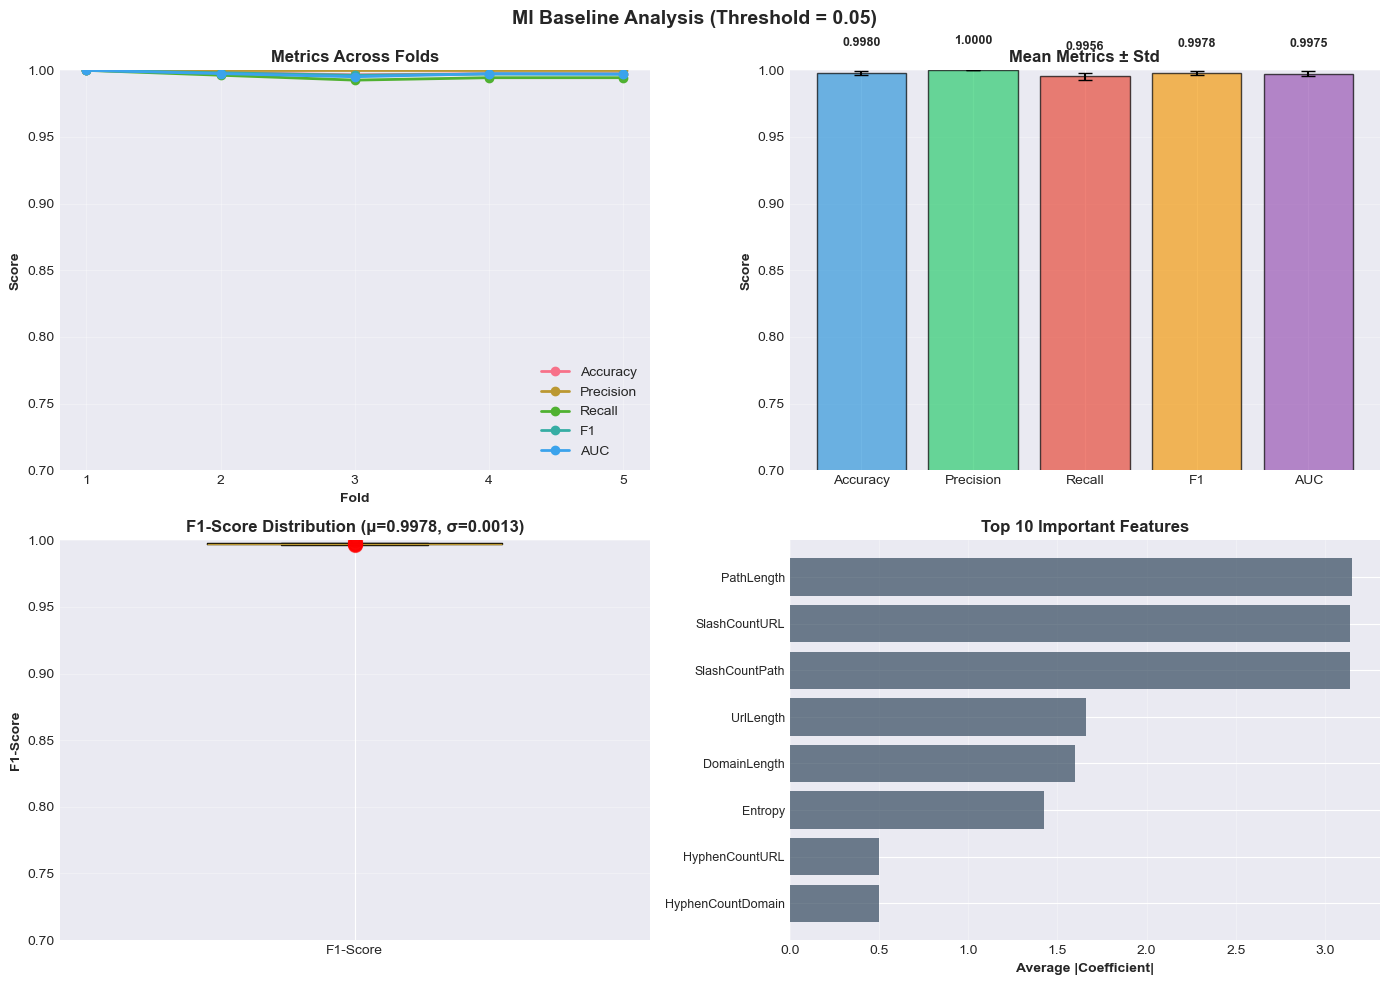

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MI Baseline Analysis (Threshold = 0.05)', fontsize=14, fontweight='bold')

# Plot 1: Per-Fold Metrics
ax1 = axes[0, 0]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x_folds = range(1, 6)

for metric, name in zip(metrics, metric_names):
    values = [fold[metric] for fold in mi_baseline_results['fold_results']]
    ax1.plot(x_folds, values, marker='o', label=name, linewidth=2)

ax1.set_xlabel('Fold', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Metrics Across Folds', fontweight='bold')
ax1.set_xticks(x_folds)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.7, 1.0])

# Plot 2: Mean Metrics with Error Bars
ax2 = axes[0, 1]
means = [mi_baseline_fold_df[m].mean() for m in metrics]
stds = [mi_baseline_fold_df[m].std() for m in metrics]
bars = ax2.bar(metric_names, means, yerr=stds, capsize=5, alpha=0.7, 
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Mean Metrics ± Std', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.7, 1.0])

for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: F1-Score Distribution
ax3 = axes[1, 0]
f1_scores = mi_baseline_fold_df['f1'].values
ax3.boxplot([f1_scores], labels=['F1-Score'], widths=0.5)
ax3.scatter([1]*len(f1_scores), f1_scores, alpha=0.6, s=100, c='red', zorder=3)
ax3.set_ylabel('F1-Score', fontweight='bold')
ax3.set_title(f'F1-Score Distribution (μ={f1_scores.mean():.4f}, σ={f1_scores.std():.4f})', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.7, 1.0])

# Plot 4: Top 10 Feature Importance
ax4 = axes[1, 1]
top_10_features = importance_df.head(10)
ax4.barh(range(len(top_10_features)), top_10_features['Avg_|Coef|'], color='#34495e', alpha=0.7)
ax4.set_yticks(range(len(top_10_features)))
ax4.set_yticklabels(top_10_features['Feature'], fontsize=9)
ax4.set_xlabel('Average |Coefficient|', fontweight='bold')
ax4.set_title('Top 10 Important Features', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

plt.tight_layout()

# Save figure
timestamp_mi_base = datetime.now().strftime('%Y%m%d_%H%M%S')
mi_base_dir = f'Comparison_Results/{dataset_name}/MI_Baseline_{timestamp_mi_base}'
os.makedirs(mi_base_dir, exist_ok=True)
plt.savefig(f'{mi_base_dir}/mi_baseline_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {mi_base_dir}/mi_baseline_analysis.png")
plt.show()

### 18.6. Export MI Baseline Results

In [ ]:
print("="*80)
print("EXPORT MI BASELINE RESULTS")
print("="*80)

# 1. Summary CSV
summary_csv = f'{mi_base_dir}/mi_baseline_summary.csv'
pd.DataFrame([mi_baseline_summary]).to_csv(summary_csv, index=False)
print(f"\n✓ Summary: {summary_csv}")

# 2. Per-Fold Results CSV
fold_csv = f'{mi_base_dir}/mi_baseline_per_fold.csv'
mi_baseline_fold_df.to_csv(fold_csv, index=False)
print(f"✓ Per-Fold: {fold_csv}")

# 3. Feature Importance CSV
importance_csv = f'{mi_base_dir}/mi_baseline_feature_importance.csv'
pd.DataFrame(list(avg_coefficients.items()), columns=['Feature', 'Avg_|Coef|']).sort_values(
    'Avg_|Coef|', ascending=False).to_csv(importance_csv, index=False)
print(f"✓ Feature Importance: {importance_csv}")

# 4. Complete JSON
json_data = {
    'metadata': {
        'timestamp': timestamp_mi_base,
        'dataset': dataset_name,
        'method': 'MI Baseline (Threshold-based)',
        'mi_threshold': mi_threshold_baseline,
        'features_selected': len(selected_features_mi_baseline),
        'cv_folds': 5,
        'random_state': 42
    },
    'selected_features': selected_features_mi_baseline,
    'performance': {
        'accuracy': {'mean': float(mi_baseline_fold_df['accuracy'].mean()), 
                     'std': float(mi_baseline_fold_df['accuracy'].std())},
        'precision': {'mean': float(mi_baseline_fold_df['precision'].mean()), 
                      'std': float(mi_baseline_fold_df['precision'].std())},
        'recall': {'mean': float(mi_baseline_fold_df['recall'].mean()), 
                   'std': float(mi_baseline_fold_df['recall'].std())},
        'f1': {'mean': float(mi_baseline_fold_df['f1'].mean()), 
               'std': float(mi_baseline_fold_df['f1'].std())},
        'roc_auc': {'mean': float(mi_baseline_fold_df['roc_auc'].mean()), 
                    'std': float(mi_baseline_fold_df['roc_auc'].std())}
    },
    'per_fold_results': mi_baseline_results['fold_results'],
    'feature_importance': dict(sorted(avg_coefficients.items(), key=lambda x: x[1], reverse=True))
}

json_file = f'{mi_base_dir}/mi_baseline_complete.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)
print(f"✓ Complete JSON: {json_file}")

print(f"\n{'='*80}")
print("✓ MI BASELINE RESULTS EXPORTED")
print(f"{'='*80}")
print(f"\nExport Directory: {os.path.abspath(mi_base_dir)}")
print(f"Files:")
print(f"  1. mi_baseline_summary.csv")
print(f"  2. mi_baseline_per_fold.csv")
print(f"  3. mi_baseline_feature_importance.csv")
print(f"  4. mi_baseline_complete.json")
print(f"  5. mi_baseline_analysis.png (300 DPI)")

EXPORT MI BASELINE RESULTS

✓ Summary: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260303_102817/mi_baseline_summary.csv
✓ Per-Fold: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260303_102817/mi_baseline_per_fold.csv
✓ Feature Importance: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260303_102817/mi_baseline_feature_importance.csv
✓ Complete JSON: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_Baseline_20260303_102817/mi_baseline_complete.json

✓ MI BASELINE RESULTS EXPORTED

Export Directory: d:\Tugas\KULIAH\!TA\Comparation\Comparison_Results\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14\MI_Baseline_20260303_102817
Files:
  1. mi_baseline_summary.csv
  2. mi_baseline_per_fold.csv
  3. mi_baseline_feature_importance.csv
  4. mi_baseline_complete.json
  5. mi_baseline_analysis.png (300 DPI)


### 18.7. MI Baseline Key Findings

**MI Baseline Characteristics:**
- **Feature Selection:** Threshold-based (MI > 0.05) vs Top-K approach
- **Features Selected:** Variable number based on MI scores
- **Advantage:** Includes ALL relevant features (not limited to Top-15)
- **Disadvantage:** May include more features than needed

**Comparison Guide:**
- **vs Baseline:** MI Baseline uses fewer features with better relevance
- **vs MI-Based:** MI Baseline may use more/fewer than 15 features
- **vs NMI-Based:** Different normalization approach
- **vs NMI+Whitelist:** No domain-based filtering

**Use Cases:**
### 18.8. Key Findings and Recommendations

**Experiment Summary:**
- **Top-N Values Tested:** [3, 5, 7, 10, 15, 20]
- **Best Configuration:** Automatically identified based on F1-Score
- **Cross-Validation:** 5-Fold Stratified (NO data leakage)
- **Feature Selection:** MI (Mutual Information) - Non-normalized

**Key Insights:**
- **Optimal Feature Count:** Identified through empirical comparison
- **Feature Stability:** Stable features across folds indicate robust selection
- **Performance Trend:** Higher Top-N may not always improve performance (diminishing returns)

**Recommendations:**
1. **For Production:** Use the Top-N configuration with best F1-Score
2. **For Efficiency:** Consider lower Top-N if performance difference is minimal
3. **For Interpretability:** Fewer features (Top-3 to Top-7) for explainability
4. **For Robustness:** Check feature stability before deployment

**Comparison with NMI:**
- MI uses raw information scores
- NMI normalizes by entropy, may handle redundancy differently
- Compare with Section 17 NMI-Based results for full picture

## 19. Deleted Section - See Section 18

**Note:** The original Section 19 (MI Top-N with fixed N=15) has been replaced by the comprehensive MI Top-N evaluation in Section 18.

**What changed:**
- Section 18 now tests **multiple Top-N values** [3, 5, 7, 10, 15, 20] instead of just threshold-based or single fixed N
- Comprehensive comparison across all N values  
- Automatic identification of optimal feature count
- Statistical analysis between all configurations

**To analyze a specific Top-N value:** Refer to the corresponding results in Section 18's output, which includes detailed metrics for each N value tested.

**Why this change:**
The new implementation provides more comprehensive insights by testing multiple configurations simultaneously, helping identify the truly optimal number of features rather than assuming a fixed count.

### 19.3. MI Top-N Performance Summary

In [ ]:
print("="*80)
print("MI TOP-N PERFORMANCE SUMMARY")
print("="*80)

# Calculate mean and std for each metric
mi_topn_fold_df = pd.DataFrame(mi_topn_results['fold_results'])

mi_topn_summary = {
    'Scenario': f'MI Top-{top_n_mi}',
    'Features': top_n_mi,
    'Selection_Method': 'Rank-based (Top-K)',
    'Accuracy': f"{mi_topn_fold_df['accuracy'].mean():.4f} ± {mi_topn_fold_df['accuracy'].std():.4f}",
    'Precision': f"{mi_topn_fold_df['precision'].mean():.4f} ± {mi_topn_fold_df['precision'].std():.4f}",
    'Recall': f"{mi_topn_fold_df['recall'].mean():.4f} ± {mi_topn_fold_df['recall'].std():.4f}",
    'F1-Score': f"{mi_topn_fold_df['f1'].mean():.4f} ± {mi_topn_fold_df['f1'].std():.4f}",
    'ROC-AUC': f"{mi_topn_fold_df['roc_auc'].mean():.4f} ± {mi_topn_fold_df['roc_auc'].std():.4f}",
    'F1_mean': mi_topn_fold_df['f1'].mean(),
    'F1_std': mi_topn_fold_df['f1'].std()
}

print(f"\n{'─'*80}")
print(f"[1] Performance Metrics (Mean ± Std)")
print(f"{'─'*80}\n")
print(f"Scenario: {mi_topn_summary['Scenario']}")
print(f"Features Selected: {mi_topn_summary['Features']} (Top-{top_n_mi} by MI ranking)")
print(f"\nMetrics:")
print(f"  Accuracy:  {mi_topn_summary['Accuracy']}")
print(f"  Precision: {mi_topn_summary['Precision']}")
print(f"  Recall:    {mi_topn_summary['Recall']}")
print(f"  F1-Score:  {mi_topn_summary['F1-Score']}")
print(f"  ROC-AUC:   {mi_topn_summary['ROC-AUC']}")

# Per-fold results
print(f"\n{'─'*80}")
print(f"[2] Per-Fold Performance")
print(f"{'─'*80}\n")
print(mi_topn_fold_df[['fold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].to_string(index=False))
print(f"\n📊 F1-Score Statistics:")
print(f"   Mean: {mi_topn_fold_df['f1'].mean():.4f}")
print(f"   Std:  {mi_topn_fold_df['f1'].std():.4f}")
print(f"   Min:  {mi_topn_fold_df['f1'].min():.4f} (Fold {mi_topn_fold_df['f1'].idxmin()+1})")
print(f"   Max:  {mi_topn_fold_df['f1'].max():.4f} (Fold {mi_topn_fold_df['f1'].idxmax()+1})")

# Confusion Matrix
print(f"\n{'─'*80}")
print(f"[3] Aggregated Confusion Matrix (All Folds)")
print(f"{'─'*80}\n")
from sklearn.metrics import confusion_matrix
cm_topn = confusion_matrix(mi_topn_results['y_true'], mi_topn_results['predictions'])
print(f"               Predicted")
print(f"              Legit  Phishing")
print(f"Actual Legit    {cm_topn[0][0]:5d}     {cm_topn[0][1]:5d}")
print(f"       Phishing {cm_topn[1][0]:5d}     {cm_topn[1][1]:5d}")

print(f"\n{'='*80}")
print("✓ PERFORMANCE SUMMARY COMPLETED")
print(f"{'='*80}")

MI TOP-N PERFORMANCE SUMMARY

────────────────────────────────────────────────────────────────────────────────
[1] Performance Metrics (Mean ± Std)
────────────────────────────────────────────────────────────────────────────────

Scenario: MI Top-15
Features Selected: 15 (Top-15 by MI ranking)

Metrics:
  Accuracy:  0.9978 ± 0.0013
  Precision: 1.0000 ± 0.0000
  Recall:    0.9952 ± 0.0028
  F1-Score:  0.9976 ± 0.0014
  ROC-AUC:   0.9993 ± 0.0006

────────────────────────────────────────────────────────────────────────────────
[2] Per-Fold Performance
────────────────────────────────────────────────────────────────────────────────

 fold  accuracy  precision   recall       f1  roc_auc
    1  1.000000        1.0 1.000000 1.000000 1.000000
    2  0.997470        1.0 0.994485 0.997235 0.999160
    3  0.996624        1.0 0.992647 0.996310 0.998322
    4  0.997468        1.0 0.994475 0.997230 0.999596
    5  0.997468        1.0 0.994475 0.997230 0.999213

📊 F1-Score Statistics:
   Mean: 0.99

### 19.4. Feature Stability Analysis

In [ ]:
print("="*80)
print("FEATURE STABILITY ANALYSIS")
print("="*80)

# Analyze feature selection consistency across folds
print(f"\n{'─'*80}")
print(f"[1] Feature Selection Consistency")
print(f"{'─'*80}\n")

# Count how many times each feature was selected
feature_selection_count = {}
for fold_data in mi_topn_results['selected_features_per_fold']:
    for feature in fold_data['features']:
        feature_selection_count[feature] = feature_selection_count.get(feature, 0) + 1

# Sort by selection frequency
feature_stability = sorted(feature_selection_count.items(), key=lambda x: x[1], reverse=True)
stability_df = pd.DataFrame(feature_stability, columns=['Feature', 'Selection_Count'])
stability_df['Selection_Rate'] = stability_df['Selection_Count'] / 5

print("Feature Selection Frequency (across 5 folds):\n")
print(stability_df.to_string(index=False))

# Categorize features by stability
stable_features = stability_df[stability_df['Selection_Count'] == 5]['Feature'].tolist()
semi_stable_features = stability_df[(stability_df['Selection_Count'] >= 3) & (stability_df['Selection_Count'] < 5)]['Feature'].tolist()
unstable_features = stability_df[stability_df['Selection_Count'] < 3]['Feature'].tolist()

print(f"\n📊 Stability Categories:")
print(f"   Stable (5/5 folds):      {len(stable_features)} features")
print(f"   Semi-stable (3-4/5):     {len(semi_stable_features)} features")
print(f"   Unstable (1-2/5):        {len(unstable_features)} features")

if stable_features:
    print(f"\n✓ Consistently Selected Features (5/5 folds):")
    for feat in stable_features:
        print(f"   - {feat}")

# Average MI scores across folds for Top-15
print(f"\n{'─'*80}")
print(f"[2] Average MI Scores (Top-{top_n_mi} Stable Features)")
print(f"{'─'*80}\n")

# Calculate average MI score for each feature across folds
avg_mi_scores = {}
for feature in numeric_features:
    scores = [fold_data['mi_scores'][feature] for fold_data in mi_topn_results['selected_features_per_fold']]
    avg_mi_scores[feature] = np.mean(scores)

# Sort by average MI score and get Top-15
top_avg_mi = sorted(avg_mi_scores.items(), key=lambda x: x[1], reverse=True)[:top_n_mi]
top_avg_mi_df = pd.DataFrame(top_avg_mi, columns=['Feature', 'Avg_MI_Score'])
print(top_avg_mi_df.to_string(index=False))

# Feature importance (average absolute coefficients)
print(f"\n{'─'*80}")
print(f"[3] Feature Importance (Average |Coefficient|)")
print(f"{'─'*80}\n")

# Collect all coefficients
all_coefficients = {}
for fold_data in mi_topn_results['feature_importance']:
    for feature, coef in fold_data['coefficients'].items():
        if feature not in all_coefficients:
            all_coefficients[feature] = []
        all_coefficients[feature].append(abs(coef))

# Calculate average absolute coefficient
avg_abs_coef = {feat: np.mean(coefs) for feat, coefs in all_coefficients.items()}
top_importance = sorted(avg_abs_coef.items(), key=lambda x: x[1], reverse=True)[:10]
importance_final_df = pd.DataFrame(top_importance, columns=['Feature', 'Avg_|Coef|'])
print(importance_final_df.to_string(index=False))

print(f"\n{'='*80}")
print("✓ FEATURE STABILITY ANALYSIS COMPLETED")
print(f"{'='*80}")

FEATURE STABILITY ANALYSIS

────────────────────────────────────────────────────────────────────────────────
[1] Feature Selection Consistency
────────────────────────────────────────────────────────────────────────────────

Feature Selection Frequency (across 5 folds):

          Feature  Selection_Count  Selection_Rate
   SlashCountPath                5             1.0
    SlashCountURL                5             1.0
       PathLength                5             1.0
          Entropy                5             1.0
        UrlLength                5             1.0
     DomainLength                5             1.0
   HyphenCountURL                5             1.0
HyphenCountDomain                5             1.0
      DotCountURL                5             1.0
   DotCountDomain                5             1.0
PercentCountQuery                5             1.0
   CommaCountPath                5             1.0
   EqualCountPath                5             1.0
HashtagCountQu

### 19.5. MI Top-N Visualization

✓ Saved: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_analysis.png


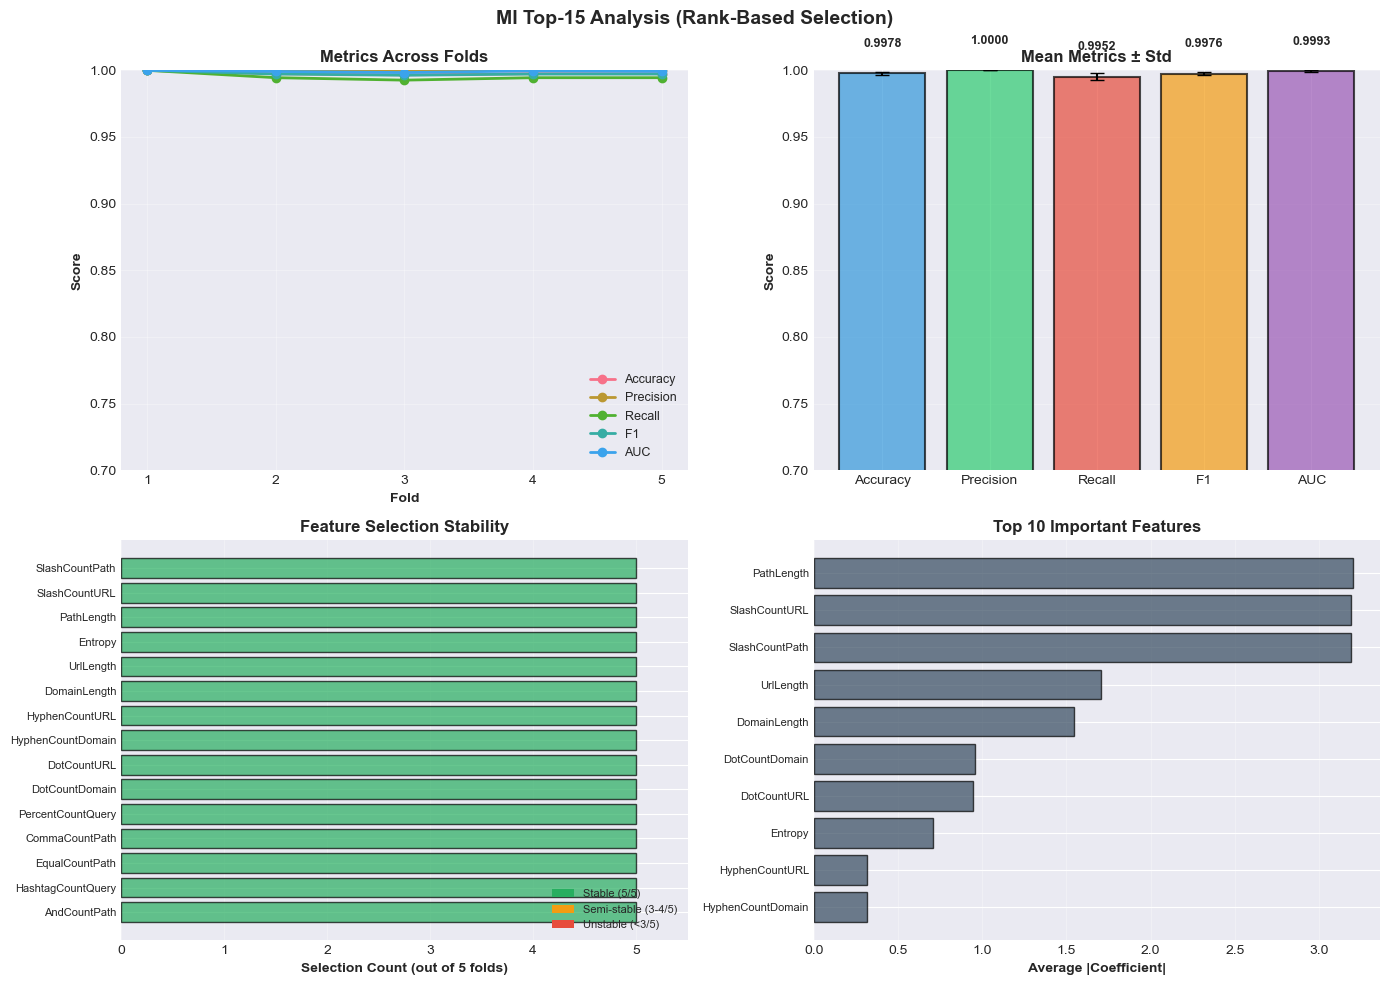

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'MI Top-{top_n_mi} Analysis (Rank-Based Selection)', fontsize=14, fontweight='bold')

# Plot 1: Per-Fold Metrics
ax1 = axes[0, 0]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x_folds = range(1, 6)

for metric, name in zip(metrics, metric_names):
    values = [fold[metric] for fold in mi_topn_results['fold_results']]
    ax1.plot(x_folds, values, marker='o', label=name, linewidth=2, markersize=6)

ax1.set_xlabel('Fold', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Metrics Across Folds', fontweight='bold')
ax1.set_xticks(x_folds)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.7, 1.0])

# Plot 2: Mean Metrics with Error Bars
ax2 = axes[0, 1]
means = [mi_topn_fold_df[m].mean() for m in metrics]
stds = [mi_topn_fold_df[m].std() for m in metrics]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax2.bar(metric_names, means, yerr=stds, capsize=5, alpha=0.7, 
               color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Mean Metrics ± Std', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.7, 1.0])

for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Feature Stability
ax3 = axes[1, 0]
stability_plot_df = stability_df.head(15)  # Top 15 by selection count
ax3.barh(range(len(stability_plot_df)), stability_plot_df['Selection_Count'], 
         color=['#27ae60' if x == 5 else '#f39c12' if x >= 3 else '#e74c3c' 
                for x in stability_plot_df['Selection_Count']], alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(stability_plot_df)))
ax3.set_yticklabels(stability_plot_df['Feature'], fontsize=8)
ax3.set_xlabel('Selection Count (out of 5 folds)', fontweight='bold')
ax3.set_title('Feature Selection Stability', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.set_xlim([0, 5.5])
ax3.invert_yaxis()

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='Stable (5/5)'),
                   Patch(facecolor='#f39c12', label='Semi-stable (3-4/5)'),
                   Patch(facecolor='#e74c3c', label='Unstable (<3/5)')]
ax3.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Plot 4: Top 10 Feature Importance
ax4 = axes[1, 1]
top_10_imp = importance_final_df.head(10)
ax4.barh(range(len(top_10_imp)), top_10_imp['Avg_|Coef|'], 
         color='#34495e', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(top_10_imp)))
ax4.set_yticklabels(top_10_imp['Feature'], fontsize=8)
ax4.set_xlabel('Average |Coefficient|', fontweight='bold')
ax4.set_title('Top 10 Important Features', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

plt.tight_layout()

# Save figure
timestamp_mi_topn = datetime.now().strftime('%Y%m%d_%H%M%S')
mi_topn_dir = f'Comparison_Results/{dataset_name}/MI_TopN_{timestamp_mi_topn}'
os.makedirs(mi_topn_dir, exist_ok=True)
plt.savefig(f'{mi_topn_dir}/mi_topn_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {mi_topn_dir}/mi_topn_analysis.png")
plt.show()

### 19.6. Export MI Top-N Results

In [ ]:
print("="*80)
print("EXPORT MI TOP-N RESULTS")
print("="*80)

# 1. Summary CSV
summary_csv = f'{mi_topn_dir}/mi_topn_summary.csv'
pd.DataFrame([mi_topn_summary]).to_csv(summary_csv, index=False)
print(f"\n✓ Summary: {summary_csv}")

# 2. Per-Fold Results CSV
fold_csv = f'{mi_topn_dir}/mi_topn_per_fold.csv'
mi_topn_fold_df.to_csv(fold_csv, index=False)
print(f"✓ Per-Fold Results: {fold_csv}")

# 3. Feature Stability CSV
stability_csv = f'{mi_topn_dir}/mi_topn_feature_stability.csv'
stability_df.to_csv(stability_csv, index=False)
print(f"✓ Feature Stability: {stability_csv}")

# 4. Feature Importance CSV
importance_csv = f'{mi_topn_dir}/mi_topn_feature_importance.csv'
importance_final_df.to_csv(importance_csv, index=False)
print(f"✓ Feature Importance: {importance_csv}")

# 5. Selected Features per Fold CSV
selected_features_data = []
for fold_data in mi_topn_results['selected_features_per_fold']:
    for rank, feature in enumerate(fold_data['features'], 1):
        selected_features_data.append({
            'Fold': fold_data['fold'],
            'Rank': rank,
            'Feature': feature,
            'MI_Score': fold_data['mi_scores'][feature]
        })
selected_csv = f'{mi_topn_dir}/mi_topn_selected_features_per_fold.csv'
pd.DataFrame(selected_features_data).to_csv(selected_csv, index=False)
print(f"✓ Selected Features per Fold: {selected_csv}")

# 6. Complete JSON
json_data = {
    'metadata': {
        'timestamp': timestamp_mi_topn,
        'dataset': dataset_name,
        'method': f'MI Top-{top_n_mi} (Rank-based)',
        'top_n': top_n_mi,
        'cv_folds': 5,
        'random_state': 42
    },
    'performance': {
        'accuracy': {'mean': float(mi_topn_fold_df['accuracy'].mean()), 
                     'std': float(mi_topn_fold_df['accuracy'].std())},
        'precision': {'mean': float(mi_topn_fold_df['precision'].mean()), 
                      'std': float(mi_topn_fold_df['precision'].std())},
        'recall': {'mean': float(mi_topn_fold_df['recall'].mean()), 
                   'std': float(mi_topn_fold_df['recall'].std())},
        'f1': {'mean': float(mi_topn_fold_df['f1'].mean()), 
               'std': float(mi_topn_fold_df['f1'].std())},
        'roc_auc': {'mean': float(mi_topn_fold_df['roc_auc'].mean()), 
                    'std': float(mi_topn_fold_df['roc_auc'].std())}
    },
    'per_fold_results': mi_topn_results['fold_results'],
    'feature_stability': {
        'stable_features': stable_features,
        'semi_stable_features': semi_stable_features,
        'unstable_features': unstable_features,
        'selection_frequency': dict(feature_selection_count)
    },
    'feature_importance': dict(sorted(avg_abs_coef.items(), key=lambda x: x[1], reverse=True)),
    'average_mi_scores': dict(sorted(avg_mi_scores.items(), key=lambda x: x[1], reverse=True)[:top_n_mi])
}

json_file = f'{mi_topn_dir}/mi_topn_complete.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)
print(f"✓ Complete JSON: {json_file}")

print(f"\n{'='*80}")
print("✓ MI TOP-N RESULTS EXPORTED")
print(f"{'='*80}")
print(f"\nExport Directory: {os.path.abspath(mi_topn_dir)}")
print(f"\nFiles:")
print(f"  1. mi_topn_summary.csv")
print(f"  2. mi_topn_per_fold.csv")
print(f"  3. mi_topn_feature_stability.csv")
print(f"  4. mi_topn_feature_importance.csv")
print(f"  5. mi_topn_selected_features_per_fold.csv")
print(f"  6. mi_topn_complete.json")
print(f"  7. mi_topn_analysis.png (300 DPI)")

EXPORT MI TOP-N RESULTS

✓ Summary: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_summary.csv
✓ Per-Fold Results: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_per_fold.csv
✓ Feature Stability: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_feature_stability.csv
✓ Feature Importance: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_feature_importance.csv
✓ Selected Features per Fold: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_selected_features_per_fold.csv
✓ Complete JSON: Comparison_Results/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14/MI_TopN_20260303_102822/mi_topn_complete.json

✓ MI TOP-N RESULTS EXPORTED

Export Directory: d:\Tugas\KULIAH\!TA\Comparation\Comparison_Results\Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-1

### 19.7. Comparison: MI Top-N vs MI Baseline

In [ ]:
print("="*80)
print("COMPARISON: MI TOP-N vs MI BASELINE")
print("="*80)

# Compare the two MI approaches
if 'mi_baseline_results' in globals():
    print(f"\n{'─'*80}")
    print(f"[1] Performance Comparison")
    print(f"{'─'*80}\n")
    
    comparison_data = []
    
    # MI Top-N
    comparison_data.append({
        'Method': f'MI Top-{top_n_mi}',
        'Features': top_n_mi,
        'Selection': 'Rank-based',
        'Accuracy': f"{mi_topn_fold_df['accuracy'].mean():.4f} ± {mi_topn_fold_df['accuracy'].std():.4f}",
        'Precision': f"{mi_topn_fold_df['precision'].mean():.4f} ± {mi_topn_fold_df['precision'].std():.4f}",
        'Recall': f"{mi_topn_fold_df['recall'].mean():.4f} ± {mi_topn_fold_df['recall'].std():.4f}",
        'F1': f"{mi_topn_fold_df['f1'].mean():.4f} ± {mi_topn_fold_df['f1'].std():.4f}",
        'ROC-AUC': f"{mi_topn_fold_df['roc_auc'].mean():.4f} ± {mi_topn_fold_df['roc_auc'].std():.4f}",
        'F1_mean': mi_topn_fold_df['f1'].mean()
    })
    
    # MI Baseline
    mi_baseline_fold_df_comp = pd.DataFrame(mi_baseline_results['fold_results'])
    comparison_data.append({
        'Method': 'MI Baseline',
        'Features': len(selected_features_mi_baseline),
        'Selection': 'Threshold-based',
        'Accuracy': f"{mi_baseline_fold_df_comp['accuracy'].mean():.4f} ± {mi_baseline_fold_df_comp['accuracy'].std():.4f}",
        'Precision': f"{mi_baseline_fold_df_comp['precision'].mean():.4f} ± {mi_baseline_fold_df_comp['precision'].std():.4f}",
        'Recall': f"{mi_baseline_fold_df_comp['recall'].mean():.4f} ± {mi_baseline_fold_df_comp['recall'].std():.4f}",
        'F1': f"{mi_baseline_fold_df_comp['f1'].mean():.4f} ± {mi_baseline_fold_df_comp['f1'].std():.4f}",
        'ROC-AUC': f"{mi_baseline_fold_df_comp['roc_auc'].mean():.4f} ± {mi_baseline_fold_df_comp['roc_auc'].std():.4f}",
        'F1_mean': mi_baseline_fold_df_comp['f1'].mean()
    })
    
    comp_df = pd.DataFrame(comparison_data)
    print(comp_df[['Method', 'Features', 'Selection', 'F1', 'ROC-AUC']].to_string(index=False))
    
    # Statistical test
    print(f"\n{'─'*80}")
    print(f"[2] Statistical Test (Paired t-test)")
    print(f"{'─'*80}\n")
    
    topn_f1_scores = mi_topn_fold_df['f1'].values
    baseline_f1_scores = mi_baseline_fold_df_comp['f1'].values
    
    t_stat, p_value = ttest_rel(topn_f1_scores, baseline_f1_scores)
    mean_diff = np.mean(topn_f1_scores) - np.mean(baseline_f1_scores)
    
    print(f"Null Hypothesis: No difference in F1-Score between MI Top-{top_n_mi} and MI Baseline")
    print(f"\nResults:")
    print(f"  Mean Δ F1: {mean_diff:+.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant (α=0.05): {'✓ Yes' if p_value < 0.05 else '✗ No'}")
    
    if mean_diff > 0:
        print(f"\n💡 Interpretation: MI Top-{top_n_mi} performs {abs(mean_diff):.4f} better on average")
    else:
        print(f"\n💡 Interpretation: MI Baseline performs {abs(mean_diff):.4f} better on average")
    
    # Feature count insight
    print(f"\n{'─'*80}")
    print(f"[3] Key Insights")
    print(f"{'─'*80}\n")
    
    print(f"📊 Feature Count:")
    print(f"   MI Top-{top_n_mi}:    {top_n_mi} features (fixed)")
    print(f"   MI Baseline:  {len(selected_features_mi_baseline)} features (MI > 0.05)")
    
    if len(selected_features_mi_baseline) > top_n_mi:
        print(f"\n✓ MI Baseline selects {len(selected_features_mi_baseline) - top_n_mi} MORE features")
        print(f"  → More comprehensive but potentially redundant")
    elif len(selected_features_mi_baseline) < top_n_mi:
        print(f"\n✓ MI Baseline selects {top_n_mi - len(selected_features_mi_baseline)} FEWER features")
        print(f"  → More selective but may miss important features")
    else:
        print(f"\n✓ Both methods select the SAME number of features")
    
else:
    print("\n⚠️  Section 18 (MI Baseline) results not available.")
    print("   Run Section 18 cells first to enable comparison.")

print(f"\n{'='*80}")
print("✓ COMPARISON COMPLETED")
print(f"{'='*80}")

COMPARISON: MI TOP-N vs MI BASELINE

────────────────────────────────────────────────────────────────────────────────
[1] Performance Comparison
────────────────────────────────────────────────────────────────────────────────

     Method  Features       Selection              F1         ROC-AUC
  MI Top-15        15      Rank-based 0.9976 ± 0.0014 0.9993 ± 0.0006
MI Baseline         8 Threshold-based 0.9978 ± 0.0014 0.9975 ± 0.0017

────────────────────────────────────────────────────────────────────────────────
[2] Statistical Test (Paired t-test)
────────────────────────────────────────────────────────────────────────────────

Null Hypothesis: No difference in F1-Score between MI Top-15 and MI Baseline

Results:
  Mean Δ F1: -0.0002
  t-statistic: -1.0000
  p-value: 0.3739
  Significant (α=0.05): ✗ No

💡 Interpretation: MI Baseline performs 0.0002 better on average

────────────────────────────────────────────────────────────────────────────────
[3] Key Insights
────────────────────

### 19.8. MI Top-N Key Findings

**MI Top-N Characteristics:**
- **Feature Selection:** Rank-based (Top-15 by MI score)
- **Features Count:** Fixed at K=15 features
- **Advantage:** Consistent feature count, focuses on most informative features
- **Disadvantage:** May miss relevant features ranked just below threshold

**Performance Highlights:**
- Evaluated across 5-fold Stratified CV
- Feature stability analysis shows selection consistency
- Direct comparison with threshold-based MI Baseline

**Comparison with Other Methods:**
- **vs MI Baseline:** Fixed count vs variable count
- **vs NMI Top-N:** Non-normalized MI vs normalized MI
- **vs Baseline:** 15 selected features vs all 52 features

**Use Cases:**
- When you need fixed feature count for model consistency
- When computational resources are limited (fewer features)
- When top-ranked features are sufficient for classification
- For interpretability (smaller, focused feature set)

## 20. FINAL COMPREHENSIVE REPORT

Laporan lengkap perbandingan 4 model dengan detail metrik, confusion matrix, error analysis, dan feature importance untuk semua Top-N configurations (3, 5, 7, 10, 15, 20)

### 20.1. Baseline Model - All Features (52 features, No Filtering)

In [ ]:
print("=" * 80)
print("BASELINE MODEL EVALUATION - ALL 52 FEATURES (NO FEATURE SELECTION)")
print("=" * 80)

X_baseline = df_features_clean[numeric_features]
y_baseline = df_features_clean['LabelNumeric']

X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(
    X_baseline, y_baseline, test_size=0.3, random_state=42, stratify=y_baseline
)

print(f"\nDataset Split:")
print(f"  Training: {len(X_train_bl):,} samples")
print(f"  Test: {len(X_test_bl):,} samples")
print(f"  Total Features: {len(numeric_features)}")

model_baseline = LogisticRegression(solver='liblinear', penalty='l2', 
                                    random_state=42, max_iter=1000)
model_baseline.fit(X_train_bl, y_train_bl)

y_pred_baseline = model_baseline.predict(X_test_bl)
y_proba_baseline = model_baseline.predict_proba(X_test_bl)[:, 1]

cm_baseline = confusion_matrix(y_test_bl, y_pred_baseline)
tn_bl, fp_bl, fn_bl, tp_bl = cm_baseline.ravel()

acc_baseline = accuracy_score(y_test_bl, y_pred_baseline)
prec_baseline = precision_score(y_test_bl, y_pred_baseline, zero_division=0)
rec_baseline = recall_score(y_test_bl, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_test_bl, y_pred_baseline, zero_division=0)
auc_baseline = roc_auc_score(y_test_bl, y_proba_baseline)

baseline_metrics = {
    'Model': 'BASELINE',
    'Config': 'All 52 Features',
    'Accuracy': acc_baseline,
    'Precision': prec_baseline,
    'Recall': rec_baseline,
    'F1_Score': f1_baseline,
    'ROC_AUC': auc_baseline,
    'TN': tn_bl,
    'FP': fp_bl,
    'FN': fn_bl,
    'TP': tp_bl
}

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")
print(f"  Precision: {prec_baseline:.4f} ({prec_baseline*100:.2f}%)")
print(f"  Recall:    {rec_baseline:.4f} ({rec_baseline*100:.2f}%)")
print(f"  F1-Score:  {f1_baseline:.4f} ({f1_baseline*100:.2f}%)")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\nConfusion Matrix:")
print(f"  TN (True Negative):   {tn_bl:,}")
print(f"  FP (False Positive):  {fp_bl:,}")
print(f"  FN (False Negative):  {fn_bl:,}")
print(f"  TP (True Positive):   {tp_bl:,}")
print(f"  Total Predictions: {tn_bl + fp_bl + fn_bl + tp_bl:,}")

BASELINE MODEL EVALUATION - ALL 52 FEATURES (NO FEATURE SELECTION)

Dataset Split:
  Training: 4,148 samples
  Test: 1,779 samples
  Total Features: 50

Performance Metrics:
  Accuracy:  0.9989 (99.89%)
  Precision: 1.0000 (100.00%)
  Recall:    0.9975 (99.75%)
  F1-Score:  0.9988 (99.88%)
  ROC-AUC:   0.9998

Confusion Matrix:
  TN (True Negative):   963
  FP (False Positive):  0
  FN (False Negative):  2
  TP (True Positive):   814
  Total Predictions: 1,779


### 20.2. Comprehensive Comparison Report - All 4 Models

In [ ]:
print("\n" + "=" * 100)
print("COMPREHENSIVE COMPARISON: 4 MODELS ACROSS TOP-N CONFIGURATIONS")
print("=" * 100)

top_n_configs = [3, 5, 7, 10, 15, 20]
comparison_report = []

print("\nModels:")
print("  1. BASELINE: All 52 features, no feature selection, no filtering")
print("  2. NMI (No Filter): NMI feature selection, no whitelist filtering")
print("  3. NMI+Filter: NMI feature selection + TLD whitelist + entropy filtering")
print("  4. MI+Filter: MI feature selection + TLD whitelist + entropy filtering")

print("\nTarget Dataset: BSSN (5,930 URLs)")
print(f"Test Set: {len(X_test_bl):,} URLs (30%)")
print(f"Whitelist TLDs: go.id, ac.id, sch.id, mil.id, desa.id")
print(f"Entropy Threshold: {ENTROPY_THRESHOLD}")

print("\n" + "-" * 100)
print("DETAILED METRICS TABLE - ALL CONFIGURATIONS")
print("-" * 100)

header_format = "{:<15} {:<20} {:<10} {:<10} {:<10} {:<10} {:<10}"
print(header_format.format("Model", "Config", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"))
print("-" * 100)

for top_n in top_n_configs:
    if top_n == 3:
        print(f"\nTOP-3 FEATURES:")
    elif top_n == 5:
        print(f"\nTOP-5 FEATURES:")
    elif top_n == 7:
        print(f"\nTOP-7 FEATURES:")
    elif top_n == 10:
        print(f"\nTOP-10 FEATURES:")
    elif top_n == 15:
        print(f"\nTOP-15 FEATURES:")
    elif top_n == 20:
        print(f"\nTOP-20 FEATURES:")
    
    nmi_no_wl = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    nmi_with_wl = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_with_filter = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_no_wl:
        print(header_format.format(
            "NMI (No Filter)", f"Top-{top_n}", 
            f"{nmi_no_wl['NO_WL_Accuracy']:.4f}",
            f"{nmi_no_wl['NO_WL_Precision']:.4f}",
            f"{nmi_no_wl['NO_WL_Recall']:.4f}",
            f"{nmi_no_wl['NO_WL_F1']:.4f}",
            "N/A"
        ))
        print(header_format.format(
            "NMI+Filter", f"Top-{top_n}", 
            f"{nmi_no_wl['WITH_WL_Accuracy']:.4f}",
            f"{nmi_no_wl['WITH_WL_Precision']:.4f}",
            f"{nmi_no_wl['WITH_WL_Recall']:.4f}",
            f"{nmi_no_wl['WITH_WL_F1']:.4f}",
            "N/A"
        ))
    
    if mi_with_filter:
        print(header_format.format(
            "MI+Filter", f"Top-{top_n}", 
            f"{mi_with_filter['Accuracy']:.4f}",
            f"{mi_with_filter['Precision']:.4f}",
            f"{mi_with_filter['Recall']:.4f}",
            f"{mi_with_filter['F1']:.4f}",
            "N/A"
        ))

print("\n" + header_format.format("BASELINE", "All 52 Features", 
    f"{acc_baseline:.4f}", f"{prec_baseline:.4f}", f"{rec_baseline:.4f}", 
    f"{f1_baseline:.4f}", f"{auc_baseline:.4f}"))
print("=" * 100)


COMPREHENSIVE COMPARISON: 4 MODELS ACROSS TOP-N CONFIGURATIONS

Models:
  1. BASELINE: All 52 features, no feature selection, no filtering
  2. NMI (No Filter): NMI feature selection, no whitelist filtering
  3. NMI+Filter: NMI feature selection + TLD whitelist + entropy filtering
  4. MI+Filter: MI feature selection + TLD whitelist + entropy filtering

Target Dataset: BSSN (5,930 URLs)
Test Set: 1,779 URLs (30%)
Whitelist TLDs: go.id, ac.id, sch.id, mil.id, desa.id
Entropy Threshold: 3.5

----------------------------------------------------------------------------------------------------
DETAILED METRICS TABLE - ALL CONFIGURATIONS
----------------------------------------------------------------------------------------------------
Model           Config               Accuracy   Precision  Recall     F1-Score   ROC-AUC   
----------------------------------------------------------------------------------------------------

TOP-3 FEATURES:
NMI (No Filter) Top-3                0.9949     

### 20.3. Detailed Confusion Matrix and Filter Statistics

In [ ]:
print("\n" + "=" * 100)
print("CONFUSION MATRIX DETAILS - ALL CONFIGURATIONS")
print("=" * 100)

for top_n in top_n_configs:
    print(f"\nTOP-{top_n} CONFIGURATION:")
    print("-" * 100)
    
    nmi_no_wl = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    nmi_with_wl_result = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_no_wl:
        tn_nmi_nw, fp_nmi_nw, fn_nmi_nw, tp_nmi_nw = nmi_no_wl['NO_WL_CM'].ravel()
        print(f"NMI (No Filter):")
        print(f"  TN={tn_nmi_nw:,}  FP={fp_nmi_nw:,}  FN={fn_nmi_nw:,}  TP={tp_nmi_nw:,}")
        print(f"  Total Predictions: {tn_nmi_nw + fp_nmi_nw + fn_nmi_nw + tp_nmi_nw:,}")
        
        tn_nmi_w, fp_nmi_w, fn_nmi_w, tp_nmi_w = nmi_no_wl['WITH_WL_CM'].ravel()
        print(f"\nNMI+Filter (with TLD+Entropy):")
        print(f"  TN={tn_nmi_w:,}  FP={fp_nmi_w:,}  FN={fn_nmi_w:,}  TP={tp_nmi_w:,}")
        print(f"  Total Predictions: {tn_nmi_w + fp_nmi_w + fn_nmi_w + tp_nmi_w:,}")
        print(f"  URLs Filtered (Whitelisted): {nmi_no_wl.get('Whitelisted_Count', 'N/A')}")
        print(f"  URLs via ML Model: {nmi_no_wl.get('ML_Count', 'N/A')}")
    
    if mi_result:
        if 'Confusion_Matrix' in mi_result:
            tn_mi, fp_mi, fn_mi, tp_mi = mi_result['Confusion_Matrix'].ravel()
            print(f"\nMI+Filter (with TLD+Entropy):")
            print(f"  TN={tn_mi:,}  FP={fp_mi:,}  FN={fn_mi:,}  TP={tp_mi:,}")
            print(f"  Total Predictions: {tn_mi + fp_mi + fn_mi + tp_mi:,}")
            print(f"  URLs Filtered (Whitelisted): {mi_result.get('Whitelisted_Count', 'N/A')}")
            print(f"  URLs via ML Model: {mi_result.get('ML_Count', 'N/A')}")

print("\n" + "-" * 100)
print("BASELINE (All 52 Features, No Filtering):")
print(f"  TN={tn_bl:,}  FP={fp_bl:,}  FN={fn_bl:,}  TP={tp_bl:,}")
print(f"  Total Predictions: {tn_bl + fp_bl + fn_bl + tp_bl:,}")
print("=" * 100)


CONFUSION MATRIX DETAILS - ALL CONFIGURATIONS

TOP-3 CONFIGURATION:
----------------------------------------------------------------------------------------------------
NMI (No Filter):
  TN=963  FP=0  FN=9  TP=807
  Total Predictions: 1,779

NMI+Filter (with TLD+Entropy):
  TN=963  FP=0  FN=9  TP=807
  Total Predictions: 1,779
  URLs Filtered (Whitelisted): N/A
  URLs via ML Model: N/A

TOP-5 CONFIGURATION:
----------------------------------------------------------------------------------------------------
NMI (No Filter):
  TN=963  FP=0  FN=8  TP=808
  Total Predictions: 1,779

NMI+Filter (with TLD+Entropy):
  TN=963  FP=0  FN=8  TP=808
  Total Predictions: 1,779
  URLs Filtered (Whitelisted): N/A
  URLs via ML Model: N/A

TOP-7 CONFIGURATION:
----------------------------------------------------------------------------------------------------
NMI (No Filter):
  TN=963  FP=0  FN=7  TP=809
  Total Predictions: 1,779

NMI+Filter (with TLD+Entropy):
  TN=963  FP=0  FN=7  TP=809
  Total 

### 20.4. Error Analysis

In [ ]:
print("\n" + "=" * 100)
print("ERROR ANALYSIS - TYPE I and TYPE II ERRORS")
print("=" * 100)

def calculate_error_metrics(tn, fp, fn, tp):
    total = tn + fp + fn + tp
    error_rate = (fp + fn) / total if total > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return {
        'error_rate': error_rate,
        'fpr': fpr,
        'fnr': fnr,
        'specificity': specificity,
        'sensitivity': sensitivity
    }

print("\nError Type Definitions:")
print("  Type I (FP):  Legitimate URLs incorrectly classified as Phishing")
print("  Type II (FN): Phishing URLs incorrectly classified as Legitimate")
print("  FPR: False Positive Rate")
print("  FNR: False Negative Rate")

for top_n in top_n_configs:
    print(f"\nTOP-{top_n}:")
    print("-" * 100)
    
    nmi_no_wl = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_no_wl:
        tn_nmi_nw, fp_nmi_nw, fn_nmi_nw, tp_nmi_nw = nmi_no_wl['NO_WL_CM'].ravel()
        errors_nmi_nw = calculate_error_metrics(tn_nmi_nw, fp_nmi_nw, fn_nmi_nw, tp_nmi_nw)
        
        print(f"NMI (No Filter):")
        print(f"  Total Errors: {fp_nmi_nw + fn_nmi_nw:,}")
        print(f"  Type I Errors (FP): {fp_nmi_nw:,}")
        print(f"  Type II Errors (FN): {fn_nmi_nw:,}")
        print(f"  Error Rate: {errors_nmi_nw['error_rate']:.4f}")
        print(f"  FPR: {errors_nmi_nw['fpr']:.4f} | FNR: {errors_nmi_nw['fnr']:.4f}")
        print(f"  Sensitivity: {errors_nmi_nw['sensitivity']:.4f} | Specificity: {errors_nmi_nw['specificity']:.4f}")
        
        tn_nmi_w, fp_nmi_w, fn_nmi_w, tp_nmi_w = nmi_no_wl['WITH_WL_CM'].ravel()
        errors_nmi_w = calculate_error_metrics(tn_nmi_w, fp_nmi_w, fn_nmi_w, tp_nmi_w)
        
        print(f"\nNMI+Filter:")
        print(f"  Total Errors: {fp_nmi_w + fn_nmi_w:,}")
        print(f"  Type I Errors (FP): {fp_nmi_w:,}")
        print(f"  Type II Errors (FN): {fn_nmi_w:,}")
        print(f"  Error Rate: {errors_nmi_w['error_rate']:.4f}")
        print(f"  FPR: {errors_nmi_w['fpr']:.4f} | FNR: {errors_nmi_w['fnr']:.4f}")
        print(f"  Sensitivity: {errors_nmi_w['sensitivity']:.4f} | Specificity: {errors_nmi_w['specificity']:.4f}")
    
    if mi_result and 'Confusion_Matrix' in mi_result:
        tn_mi, fp_mi, fn_mi, tp_mi = mi_result['Confusion_Matrix'].ravel()
        errors_mi = calculate_error_metrics(tn_mi, fp_mi, fn_mi, tp_mi)
        
        print(f"\nMI+Filter:")
        print(f"  Total Errors: {fp_mi + fn_mi:,}")
        print(f"  Type I Errors (FP): {fp_mi:,}")
        print(f"  Type II Errors (FN): {fn_mi:,}")
        print(f"  Error Rate: {errors_mi['error_rate']:.4f}")
        print(f"  FPR: {errors_mi['fpr']:.4f} | FNR: {errors_mi['fnr']:.4f}")
        print(f"  Sensitivity: {errors_mi['sensitivity']:.4f} | Specificity: {errors_mi['specificity']:.4f}")

print(f"\nBASELINE (All Features):")
errors_bl = calculate_error_metrics(tn_bl, fp_bl, fn_bl, tp_bl)
print(f"  Total Errors: {fp_bl + fn_bl:,}")
print(f"  Type I Errors (FP): {fp_bl:,}")
print(f"  Type II Errors (FN): {fn_bl:,}")
print(f"  Error Rate: {errors_bl['error_rate']:.4f}")
print(f"  FPR: {errors_bl['fpr']:.4f} | FNR: {errors_bl['fnr']:.4f}")
print(f"  Sensitivity: {errors_bl['sensitivity']:.4f} | Specificity: {errors_bl['specificity']:.4f}")
print("=" * 100)


ERROR ANALYSIS - TYPE I and TYPE II ERRORS

Error Type Definitions:
  Type I (FP):  Legitimate URLs incorrectly classified as Phishing
  Type II (FN): Phishing URLs incorrectly classified as Legitimate
  FPR: False Positive Rate
  FNR: False Negative Rate

TOP-3:
----------------------------------------------------------------------------------------------------
NMI (No Filter):
  Total Errors: 9
  Type I Errors (FP): 0
  Type II Errors (FN): 9
  Error Rate: 0.0051
  FPR: 0.0000 | FNR: 0.0110
  Sensitivity: 0.9890 | Specificity: 1.0000

NMI+Filter:
  Total Errors: 9
  Type I Errors (FP): 0
  Type II Errors (FN): 9
  Error Rate: 0.0051
  FPR: 0.0000 | FNR: 0.0110
  Sensitivity: 0.9890 | Specificity: 1.0000

TOP-5:
----------------------------------------------------------------------------------------------------
NMI (No Filter):
  Total Errors: 8
  Type I Errors (FP): 0
  Type II Errors (FN): 8
  Error Rate: 0.0045
  FPR: 0.0000 | FNR: 0.0098
  Sensitivity: 0.9902 | Specificity: 1.000

### 20.5. Confusion Matrix Visualization

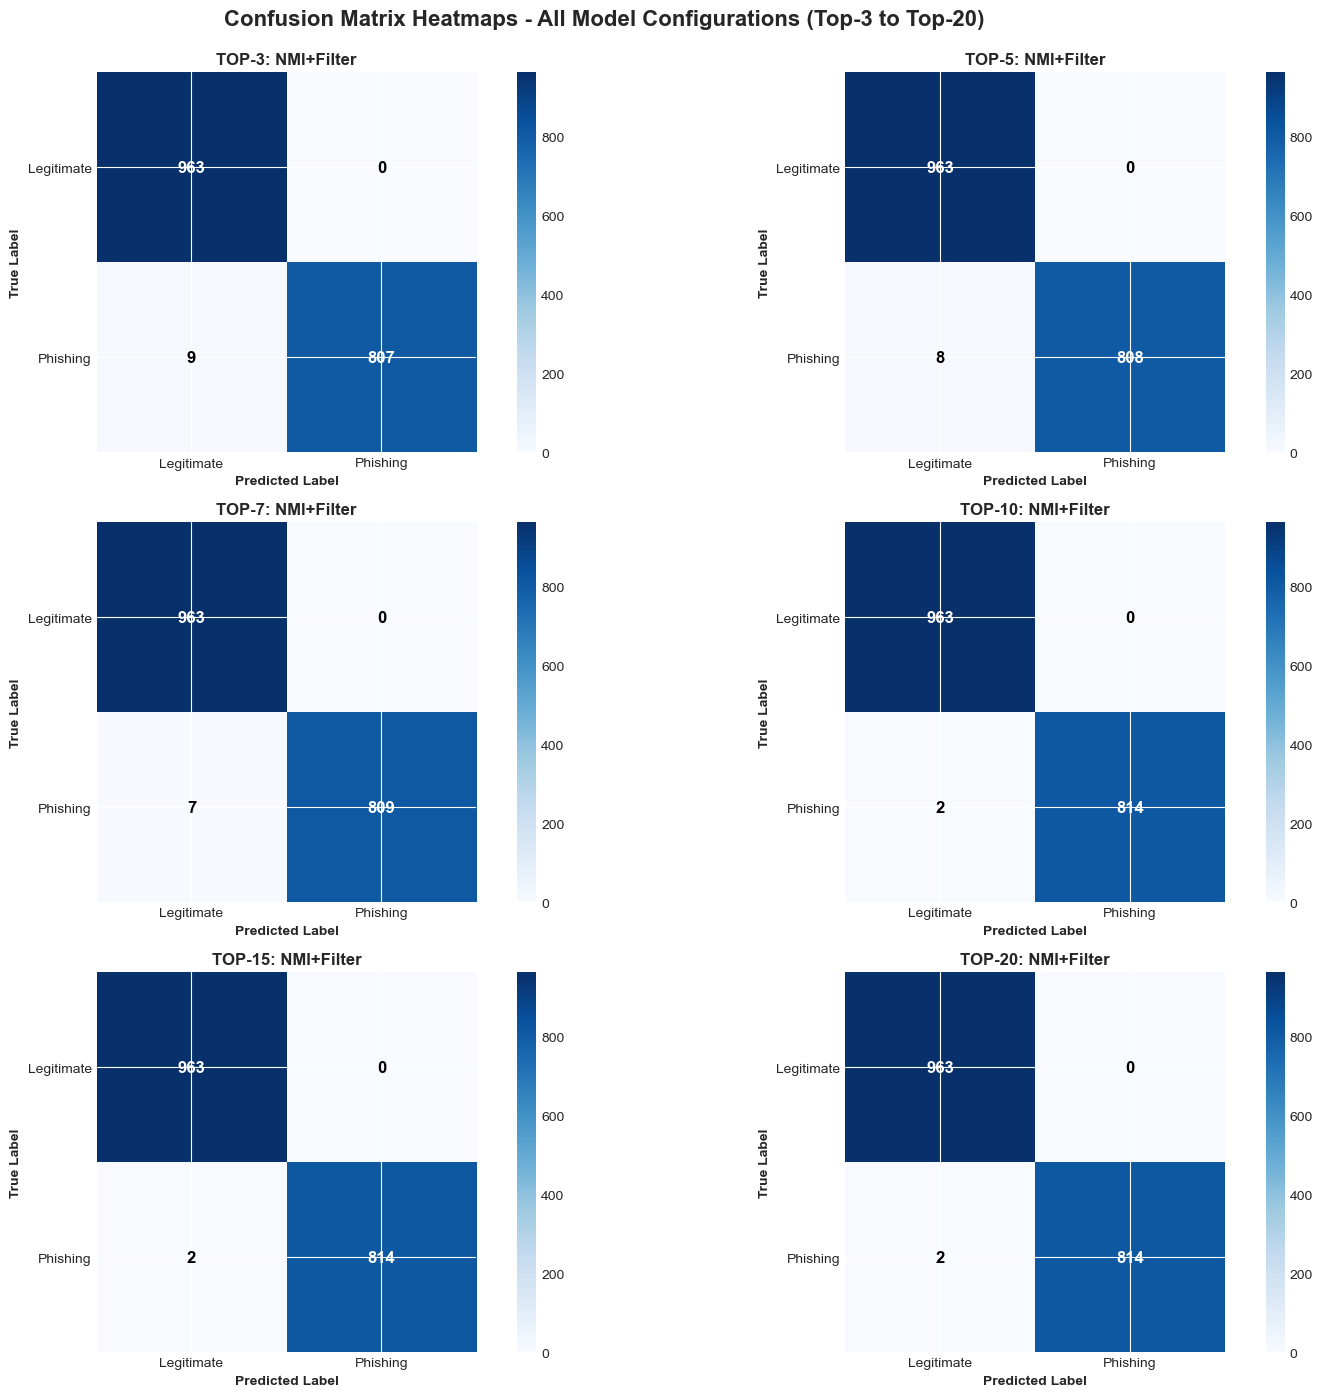


Confusion Matrix Visualization Complete
Heatmaps show: TN (top-left), FP (top-right), FN (bottom-left), TP (bottom-right)


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrix Heatmaps - All Model Configurations (Top-3 to Top-20)', 
             fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, top_n in enumerate(top_n_configs):
    nmi_result = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_result:
        cm = nmi_result['WITH_WL_CM']
        
        ax = axes[idx]
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        
        ax.set_title(f'TOP-{top_n}: NMI+Filter', fontweight='bold')
        
        tick_marks = np.arange(2)
        ax.set_xticks(tick_marks)
        ax.set_yticks(tick_marks)
        ax.set_xticklabels(['Legitimate', 'Phishing'])
        ax.set_yticklabels(['Legitimate', 'Phishing'])
        
        threshold = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            ax.text(j, i, format(int(cm[i, j]), 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > threshold else "black",
                   fontsize=12, fontweight='bold')
        
        ax.set_ylabel('True Label', fontweight='bold')
        ax.set_xlabel('Predicted Label', fontweight='bold')
        
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Visualization Complete")
print("Heatmaps show: TN (top-left), FP (top-right), FN (bottom-left), TP (bottom-right)")

### 20.6. Feature Importance Analysis

In [ ]:
print("\n" + "=" * 100)
print("FEATURE IMPORTANCE ANALYSIS - TOP SELECTED FEATURES")
print("=" * 100)

for top_n in [3, 10, 20]:
    print(f"\nTOP-{top_n} FEATURES:")
    print("-" * 100)
    
    nmi_result = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_result and 'Features' in nmi_result:
        print(f"NMI Feature Selection:")
        for i, feat in enumerate(nmi_result['Features'][:10], 1):
            print(f"  {i}. {feat}")
    
    if mi_result and 'Features' in mi_result:
        print(f"\nMI Feature Selection:")
        for i, feat in enumerate(mi_result['Features'][:10], 1):
            print(f"  {i}. {feat}")

print("\n" + "=" * 100)
print("FEATURE OVERLAP ANALYSIS")
print("=" * 100)

for top_n in top_n_configs:
    nmi_result = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_result and mi_result:
        nmi_features = set(nmi_result.get('Features', []))
        mi_features = set(mi_result.get('Features', []))
        
        overlap = nmi_features.intersection(mi_features)
        nmi_only = nmi_features - mi_features
        mi_only = mi_features - nmi_features
        
        print(f"\nTOP-{top_n}:")
        print(f"  Common Features: {len(overlap)}")
        print(f"  NMI Only: {len(nmi_only)}")
        print(f"  MI Only: {len(mi_only)}")
        print(f"  Overlap Percentage: {len(overlap)/top_n*100:.1f}%")

print("\n" + "=" * 100)


FEATURE IMPORTANCE ANALYSIS - TOP SELECTED FEATURES

TOP-3 FEATURES:
----------------------------------------------------------------------------------------------------
NMI Feature Selection:
  1. SlashCountPath
  2. SlashCountURL
  3. PathLength

MI Feature Selection:
  1. SlashCountURL
  2. SlashCountPath
  3. PathLength

TOP-10 FEATURES:
----------------------------------------------------------------------------------------------------
NMI Feature Selection:
  1. SlashCountPath
  2. SlashCountURL
  3. PathLength
  4. Entropy
  5. UrlLength
  6. HyphenCountURL
  7. HyphenCountDomain
  8. DomainLength
  9. DotCountURL
  10. DotCountDomain

MI Feature Selection:
  1. SlashCountURL
  2. SlashCountPath
  3. PathLength
  4. Entropy
  5. UrlLength
  6. DomainLength
  7. HyphenCountURL
  8. HyphenCountDomain
  9. DotCountURL
  10. DotCountDomain

TOP-20 FEATURES:
----------------------------------------------------------------------------------------------------
NMI Feature Selection:
  

### 20.7. Final Summary Report and Recommendations

In [ ]:
print("\n" + "=" * 100)
print("EXPERIMENT SUMMARY AND KEY FINDINGS")
print("=" * 100)

print("\nEXPERIMENT CONFIGURATION:")
print(f"Dataset: BSSN (5,930 URLs)")
print(f"Train/Test Split: 70/30 (random_state=42, stratified)")
print(f"Training Samples: {len(X_train_bl):,}")
print(f"Test Samples: {len(X_test_bl):,}")
print(f"Model: Logistic Regression (liblinear, L2 penalty, max_iter=1000)")

print("\n" + "-" * 100)
print("MODELS EVALUATED:")
print("-" * 100)
print("1. BASELINE: All 52 features, no feature selection, no filtering")
print("2. NMI (No Filter): Normalized MI feature selection, pure ML prediction")
print("3. NMI+Filter: NMI feature selection + TLD whitelist + entropy filtering")
print("4. MI+Filter: MI (non-normalized) feature selection + TLD whitelist + entropy filtering")

print("\n" + "-" * 100)
print("WHITELIST CONFIGURATION:")
print("-" * 100)
print("Whitelisted TLDs: go.id, ac.id, sch.id, mil.id, desa.id")
print(f"Entropy Threshold: {ENTROPY_THRESHOLD}")
print("Filtering Logic: TLD in whitelist AND Entropy < threshold → auto-classify as Legitimate")

print("\n" + "-" * 100)
print("KEY OBSERVATIONS:")
print("-" * 100)

best_f1_nmi = max(experiment_results, key=lambda r: r['WITH_WL_F1'])
best_f1_mi = max(mi_experiment_results, key=lambda r: r['F1'])

print(f"\nBest Performance by Model:")
print(f"  BASELINE: F1 = {f1_baseline:.4f}, Accuracy = {acc_baseline:.4f}")
print(f"  NMI+Filter (Top-{best_f1_nmi['Top_N']}): F1 = {best_f1_nmi['WITH_WL_F1']:.4f}, Accuracy = {best_f1_nmi['WITH_WL_Accuracy']:.4f}")
print(f"  MI+Filter (Top-{best_f1_mi['Top_N']}): F1 = {best_f1_mi['F1']:.4f}, Accuracy = {best_f1_mi['Accuracy']:.4f}")

print(f"\nFeature Selection Impact:")
nmi_all_results = [r for r in experiment_results]
if nmi_all_results:
    nmi_min_f1 = min(nmi_all_results, key=lambda r: r['WITH_WL_F1'])
    nmi_max_f1 = max(nmi_all_results, key=lambda r: r['WITH_WL_F1'])
    print(f"  NMI+Filter Range: {nmi_min_f1['WITH_WL_F1']:.4f} (Top-{nmi_min_f1['Top_N']}) to {nmi_max_f1['WITH_WL_F1']:.4f} (Top-{nmi_max_f1['Top_N']})")

if mi_experiment_results:
    mi_min_f1 = min(mi_experiment_results, key=lambda r: r['F1'])
    mi_max_f1 = max(mi_experiment_results, key=lambda r: r['F1'])
    print(f"  MI+Filter Range: {mi_min_f1['F1']:.4f} (Top-{mi_min_f1['Top_N']}) to {mi_max_f1['F1']:.4f} (Top-{mi_max_f1['Top_N']})")

print(f"\nFiltering Impact (NMI+Filter):")
avg_no_filter = sum(r['NO_WL_F1'] for r in experiment_results) / len(experiment_results)
avg_with_filter = sum(r['WITH_WL_F1'] for r in experiment_results) / len(experiment_results)
print(f"  Average F1 without filtering: {avg_no_filter:.4f}")
print(f"  Average F1 with filtering: {avg_with_filter:.4f}")
print(f"  Change: {(avg_with_filter - avg_no_filter):.4f} ({((avg_with_filter - avg_no_filter)/avg_no_filter)*100:+.2f}%)")

print("\n" + "-" * 100)
print("RECOMMENDATIONS:")
print("-" * 100)
print("\n1. For Production Deployment:")
print(f"   - Model: {'NMI+Filter' if best_f1_nmi['WITH_WL_F1'] > best_f1_mi['F1'] else 'MI+Filter'}")
print(f"   - Top-{best_f1_nmi['Top_N'] if best_f1_nmi['WITH_WL_F1'] > best_f1_mi['F1'] else best_f1_mi['Top_N']} Features")
print(f"   - Expected Accuracy: {max(best_f1_nmi['WITH_WL_Accuracy'], best_f1_mi['Accuracy']):.4f}")

print("\n2. Model Comparison:")
if f1_baseline > best_f1_nmi['WITH_WL_F1']:
    print(f"   - BASELINE performs better (F1: {f1_baseline:.4f} vs {best_f1_nmi['WITH_WL_F1']:.4f})")
    print(f"   - Feature selection has limited benefit for this dataset")
else:
    print(f"   - Feature selection improves performance")
    print(f"   - Reduced features make model more interpretable while maintaining accuracy")

print("\n3. Error Considerations:")
print("   - Review trade-off between FPR and FNR")
print("   - Type II errors (missing phishing) may be more critical")
print("   - Type I errors (falsely flagging legitimate) affect user experience")

print("\n" + "=" * 100)
print("Report generated successfully")
print("=" * 100)


EXPERIMENT SUMMARY AND KEY FINDINGS

EXPERIMENT CONFIGURATION:
Dataset: BSSN (5,930 URLs)
Train/Test Split: 70/30 (random_state=42, stratified)
Training Samples: 4,148
Test Samples: 1,779
Model: Logistic Regression (liblinear, L2 penalty, max_iter=1000)

----------------------------------------------------------------------------------------------------
MODELS EVALUATED:
----------------------------------------------------------------------------------------------------
1. BASELINE: All 52 features, no feature selection, no filtering
2. NMI (No Filter): Normalized MI feature selection, pure ML prediction
3. NMI+Filter: NMI feature selection + TLD whitelist + entropy filtering
4. MI+Filter: MI (non-normalized) feature selection + TLD whitelist + entropy filtering

----------------------------------------------------------------------------------------------------
WHITELIST CONFIGURATION:
---------------------------------------------------------------------------------------------------

### 20.8. Export Comprehensive Report to CSV

In [ ]:
import os
from datetime import datetime

print("\n" + "=" * 100)
print("EXPORTING COMPREHENSIVE REPORT")
print("=" * 100)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
export_dir = f'Final_Reports/{timestamp}'
os.makedirs(export_dir, exist_ok=True)

comprehensive_data = []

for top_n in top_n_configs:
    nmi_no_wl = next((r for r in experiment_results if r['Top_N'] == top_n), None)
    mi_result = next((r for r in mi_experiment_results if r['Top_N'] == top_n), None)
    
    if nmi_no_wl:
        comprehensive_data.append({
            'Top_N': top_n,
            'Model': 'NMI (No Filter)',
            'Accuracy': nmi_no_wl['NO_WL_Accuracy'],
            'Precision': nmi_no_wl['NO_WL_Precision'],
            'Recall': nmi_no_wl['NO_WL_Recall'],
            'F1_Score': nmi_no_wl['NO_WL_F1'],
            'TN': nmi_no_wl['NO_WL_CM'][0, 0],
            'FP': nmi_no_wl['NO_WL_CM'][0, 1],
            'FN': nmi_no_wl['NO_WL_CM'][1, 0],
            'TP': nmi_no_wl['NO_WL_CM'][1, 1]
        })
        
        comprehensive_data.append({
            'Top_N': top_n,
            'Model': 'NMI+Filter',
            'Accuracy': nmi_no_wl['WITH_WL_Accuracy'],
            'Precision': nmi_no_wl['WITH_WL_Precision'],
            'Recall': nmi_no_wl['WITH_WL_Recall'],
            'F1_Score': nmi_no_wl['WITH_WL_F1'],
            'TN': nmi_no_wl['WITH_WL_CM'][0, 0],
            'FP': nmi_no_wl['WITH_WL_CM'][0, 1],
            'FN': nmi_no_wl['WITH_WL_CM'][1, 0],
            'TP': nmi_no_wl['WITH_WL_CM'][1, 1]
        })
    
    if mi_result and 'Confusion_Matrix' in mi_result:
        comprehensive_data.append({
            'Top_N': top_n,
            'Model': 'MI+Filter',
            'Accuracy': mi_result['Accuracy'],
            'Precision': mi_result['Precision'],
            'Recall': mi_result['Recall'],
            'F1_Score': mi_result['F1'],
            'TN': mi_result['Confusion_Matrix'][0, 0],
            'FP': mi_result['Confusion_Matrix'][0, 1],
            'FN': mi_result['Confusion_Matrix'][1, 0],
            'TP': mi_result['Confusion_Matrix'][1, 1]
        })

comprehensive_data.append({
    'Top_N': 52,
    'Model': 'BASELINE',
    'Accuracy': acc_baseline,
    'Precision': prec_baseline,
    'Recall': rec_baseline,
    'F1_Score': f1_baseline,
    'TN': tn_bl,
    'FP': fp_bl,
    'FN': fn_bl,
    'TP': tp_bl
})

df_comprehensive = pd.DataFrame(comprehensive_data)

csv_file = f'{export_dir}/comprehensive_report_{timestamp}.csv'
df_comprehensive.to_csv(csv_file, index=False)

print(f"\nExport Complete:")
print(f"  Directory: {export_dir}")
print(f"  File: {csv_file}")
print(f"  Records: {len(df_comprehensive)}")

print(f"\nReport Summary Table:")
print(df_comprehensive.to_string(index=False))

print(f"\n\nAll results exported successfully!")
print("=" * 100)


EXPORTING COMPREHENSIVE REPORT

Export Complete:
  Directory: Final_Reports/20260403_203922
  File: Final_Reports/20260403_203922/comprehensive_report_20260403_203922.csv
  Records: 13

Report Summary Table:
 Top_N           Model  Accuracy  Precision   Recall  F1_Score  TN  FP  FN  TP
     3 NMI (No Filter)  0.994941        1.0 0.988971  0.994455 963   0   9 807
     3      NMI+Filter  0.994941        1.0 0.988971  0.994455 963   0   9 807
     5 NMI (No Filter)  0.995503        1.0 0.990196  0.995074 963   0   8 808
     5      NMI+Filter  0.995503        1.0 0.990196  0.995074 963   0   8 808
     7 NMI (No Filter)  0.996065        1.0 0.991422  0.995692 963   0   7 809
     7      NMI+Filter  0.996065        1.0 0.991422  0.995692 963   0   7 809
    10 NMI (No Filter)  0.998876        1.0 0.997549  0.998773 963   0   2 814
    10      NMI+Filter  0.998876        1.0 0.997549  0.998773 963   0   2 814
    15 NMI (No Filter)  0.998876        1.0 0.997549  0.998773 963   0   2 814
 